# Algorithmic VWAP Sigma Engine

Clean research notebook for the VWAP sigma-band strategy.

This notebook is used to:
- calculate VWAP and sigma probability bands
- detect continuation and mean-reversion setups
- route/filter raw signals
- simulate trades
- compare strategy results
- audit skipped opportunities
- prepare the final logic for a future live MT5 runner

This is not the live runner yet.

## Table of Contents

1. Imports and paths
2. Strategy control panel
3. Dataset configuration
4. VWAP and sigma band engine
5. Continuation signal engine
6. Mean-reversion signal engine
7. Router and strategy filter
8. Trade simulation and risk engine
9. Experiment runner
10. Quick results
11. Core charts
12. Risk diagnostics
13. Audits and detailed diagnostics
14. Experiment logging
15. Future live runner notes

## Imports and paths

This section contains the notebook imports, project-root detection, and output paths.

In [1]:
from pathlib import Path
from pprint import pprint
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


def find_project_root(start_path: Path | None = None) -> Path:
    """
    Find the project root by walking upward until the expected repository
    structure is found.

    This works whether the project was cloned with Git or downloaded as a ZIP,
    and whether the notebook is run from the project root or from notebooks/.
    """
    if start_path is None:
        start_path = Path.cwd()

    start_path = start_path.resolve()

    for path in [start_path, *start_path.parents]:
        has_project_structure = (
            (path / "src").is_dir()
            and (path / "data").is_dir()
            and (path / "notebooks").is_dir()
        )

        has_repo_marker = (
            (path / ".git").exists()
            or (path / "README.md").exists()
            or (path / "requirements.txt").exists()
        )

        if has_project_structure and has_repo_marker:
            return path

    raise FileNotFoundError(
        "Could not find the project root. Make sure this notebook is being run "
        "from inside the VWAP-probability-band-engine project folder."
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
HISTORICAL_DATA_DIR = DATA_DIR / "historical"
SRC_DIR = PROJECT_ROOT / "src"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
OUTPUT_DIR = ARTIFACTS_DIR / "algorithmic_vwap_sigma_engine"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current working directory:", Path.cwd())
print("Detected project root:", PROJECT_ROOT)
print("Historical data folder:", HISTORICAL_DATA_DIR)
print("Source folder:", SRC_DIR)
print("Output folder:", OUTPUT_DIR)

Current working directory: c:\GitHub Projects\VWAP-probability-band-engine\notebooks
Detected project root: C:\GitHub Projects\VWAP-probability-band-engine
Historical data folder: C:\GitHub Projects\VWAP-probability-band-engine\data\historical
Source folder: C:\GitHub Projects\VWAP-probability-band-engine\src
Output folder: C:\GitHub Projects\VWAP-probability-band-engine\artifacts\algorithmic_vwap_sigma_engine


## Strategy control panel

This section controls the strategy behaviour from one place.

The control panel is separated by role:
- strategy family switches
- continuation entry-type switches
- router and strategy-filter controls
- setup-specific quality filters
- future router-blocked override controls
- execution and risk controls
- reporting and audit controls

The goal is to make it clear which stage each setting affects.

In [2]:
# ============================================================
# 1. MAIN STRATEGY SWITCHES
# ============================================================
# Purpose:
#   Turn major strategy families on or off.
#
# Scope:
#   These are top-level switches. If a family is disabled here,
#   that family should not create trades.
#
# Default:
#   Continuation is enabled. Mean reversion and add-ons are disabled
#   until proven stable.
#
# Risk:
#   Enabling extra strategy families can change trade frequency,
#   drawdown, and attribution.

ENABLE_CONTINUATION = True
ENABLE_MEAN_REVERSION = False
ENABLE_PROTECTED_ADDONS = False


# ============================================================
# 2. CONTINUATION ENTRY TYPES
# ============================================================
# Purpose:
#   Control which continuation setup families can create raw signals.
#
# Scope:
#   These switches affect raw continuation setup creation only.
#
# Default:
#   The current primary continuation profile keeps the main continuation
#   families available.
#
# Risk:
#   Disabling a setup family can hide valid opportunity types.
#   Enabling too many weak setup families without filtering can increase noise.

ENABLE_S_TIER = True
ENABLE_DYNAMIC_S_TIER = True
ENABLE_A_TIER = True
ENABLE_DELAYED_PULLBACK = True


# ============================================================
# 3. ROUTER / STRATEGY FILTER
# ============================================================
# Purpose:
#   Decide whether raw setups fit the current market regime.
#
# Scope:
#   This is a permission layer after raw signal creation.
#   It should not be confused with raw setup detection.
#
# Default:
#   Enabled because it blocks many weak-regime signals.
#
# Risk:
#   Turning this off can allow many low-quality trades.
#   Leaving it too strict may block valid A-tier continuation opportunities.

USE_STRATEGY_FILTER = True
STRATEGY_FILTER_MODE = "v4_dynamic_regime_selector"


# ============================================================
# 4. STRATEGY FILTER OVERRIDES
# ============================================================
# Purpose:
#   Future research controls for router-blocked setups.
#
# Scope:
#   These should only apply after the router blocks a raw setup.
#   They should not affect router-approved trades.
#
# Default:
#   OFF. They should not change current results.
#
# Risk:
#   If implemented carelessly, these can become the same as removing
#   the strategy filter. They must require extra quality confirmation.

ALLOW_BLOCKED_S_TIER_WITH_EXTRA_QUALITY = False
ALLOW_BLOCKED_DYNAMIC_S_TIER_WITH_EXTRA_QUALITY = False
ALLOW_BLOCKED_A_TIER_WITH_EXTRA_QUALITY = False
ALLOW_BLOCKED_DELAYED_PULLBACK_WITH_EXTRA_QUALITY = False


# ============================================================
# 5. SETUP-SPECIFIC QUALITY FILTERS
# ============================================================
# Purpose:
#   Extra quality checks after a raw setup exists.
#
# Scope:
#   These should clearly state whether they apply globally,
#   only to S-tier, only to A-tier, only to delayed pullbacks,
#   only to mean reversion, or only to future router-blocked overrides.
#
# Default:
#   Preserve the current primary continuation profile.
#
# Risk:
#   Turning on too many filters at once may double-filter trades
#   that the strategy router already approved.

USE_S_TIER_CLEAN_STATE_FILTER = True

USE_RED_SHIFT_FLOOR = False
USE_TREND_HEALTH_FILTER = True
USE_CANDLE_QUALITY_FILTER = True
USE_EXTENSION_FILTER = True


# ============================================================
# 6. RISK AND RUNNER MANAGEMENT
# ============================================================
# Purpose:
#   Define continuation trade risk, target, breakeven, and runner behaviour.
#
# Scope:
#   Applies to continuation trades unless a setup-specific exit model overrides it.
#
# Default:
#   Uses the current primary continuation runner profile.
#
# Risk:
#   Changing stop size, target, breakeven, or runner locks can materially
#   change all headline results.

SL_POINTS = 36.0
ORIGINAL_TP_POINTS = 72.0
BE_TRIGGER_POINTS = 36.0

RUNNER_MODE = "always"
RUNNER_TARGET_R = 7.0
USE_LEGACY_EARLY_RUNNER_LOCK = False

RUNNER_TRAIL_RULES_R = [
    {"trigger_r": 1.0, "lock_r": 0.0, "label": "BE"},
    {"trigger_r": 2.7, "lock_r": 2.0, "label": "TRAIL_LOCK_2R"},
    {"trigger_r": 3.7, "lock_r": 3.0, "label": "TRAIL_LOCK_3R"},
    {"trigger_r": 4.7, "lock_r": 4.0, "label": "TRAIL_LOCK_4R"},
    {"trigger_r": 5.7, "lock_r": 5.0, "label": "TRAIL_LOCK_5R"},
    {"trigger_r": 6.7, "lock_r": 6.0, "label": "TRAIL_LOCK_6R"},
]


# ============================================================
# 7. PROTECTED CONTINUATION ADD-ONS
# ============================================================
# Purpose:
#   Allow another continuation trade only when an existing continuation
#   trade is already protected.
#
# Scope:
#   Applies to continuation stacking logic, not mean reversion.
#
# Default:
#   OFF until proven stable.
#
# Risk:
#   If configured badly, this can create multiple full-risk trades.
#   The intended rule is no second fresh full-risk trade.

ENABLE_PROTECTED_ADDONS = False
ADDON_REQUIRES_EXISTING_TRADE_PROTECTED = True
ADDON_REQUIRES_SAME_DIRECTION = True
MAX_OPEN_CONTINUATION_TRADES = 2


# ============================================================
# 8. MEAN-REVERSION SETTINGS
# ============================================================
# Purpose:
#   Configure the optional mean-reversion module.
#
# Scope:
#   Mean reversion is separate from continuation.
#   It targets VWAP and should not use the continuation runner.
#
# Default:
#   Disabled because early tests over-traded.
#
# Risk:
#   Mean reversion can add many trades and increase drawdown if not filtered.

ENABLE_MEAN_REVERSION = False

MR_TARGET_MODE = "vwap"
MR_STOP_MODE = "structure"
MR_MAX_SL_POINTS = 14.0
MR_MIN_TARGET_RR = 2.0

ENABLE_MR_GREEN_BE = True
MR_BE_TRIGGER_MODE = "inner_green"
MR_BE_REQUIRES_CLOSE_BEYOND_GREEN = True


# ============================================================
# 9. DAILY RISK / SESSION CONTROLS
# ============================================================
# Purpose:
#   Control account/risk/session-level trade permissions.
#
# Scope:
#   These controls operate after signal selection.
#
# Default:
#   Preserve current research profile.
#
# Risk:
#   Tight risk/session settings can reduce trade count.
#   Loose settings can increase drawdown exposure.

MAX_DAILY_LOSS_R = -2
DAILY_PROFIT_CAP_PCT = 999.0
MAX_CONSECUTIVE_SL = 2
NO_NEW_TRADES_AFTER = "19:00"
SESSION_FILTER_ENABLED = False


# ============================================================
# 10. AUDITS / REPORTS / LOGGING
# ============================================================
# Purpose:
#   Explain what the model saw, selected, executed, or skipped.
#
# Scope:
#   These should not change trading logic.
#
# Default:
#   Enabled because this notebook is a research/control notebook.
#
# Risk:
#   These should not affect results. If toggling a report changes trades,
#   something is wired incorrectly.

ENABLE_RAW_SIGNAL_AUDIT = True
ENABLE_STRATEGY_FILTER_BLOCK_AUDIT = True
ENABLE_TRADE_ATTRIBUTION_REPORT = True
ENABLE_RISK_DIAGNOSTICS = True
ENABLE_ACCOUNT_SURVIVAL_REPORT = True
ENABLE_EXPERIMENT_LOGGING = True

In [3]:
# ============================================================
# INTERNAL CONFIG MAPPING
# ============================================================
# Purpose:
#   Map the readable control-panel settings above into the internal keys
#   expected by the migrated engine code.
#
# Scope:
#   This cell is compatibility glue. Future edits should normally happen
#   in the readable control panel above, not by scattering overrides later.
#
# Default:
#   Keeps the current primary continuation profile active.
#
# Risk:
#   Changing internal keys here can alter strategy behaviour globally.

CONFIG = {
    # ------------------------------------------------------------------
    # Dataset
    # ------------------------------------------------------------------
    "csv_file": "US100_cash_M1_NY_session_1y.csv",
    "dataset_name": "US100_cash_M1_NY_session_1y",

    # ------------------------------------------------------------------
    # Strategy identity
    # ------------------------------------------------------------------
    "strategy_version": "algorithmic_vwap_sigma_engine",
    "strategy_description": "Clean modular VWAP sigma-band research engine",

    # ------------------------------------------------------------------
    # Session handling
    # ------------------------------------------------------------------
    "session_timezone": "Europe/London",
    "no_new_trades_after": NO_NEW_TRADES_AFTER,

    # ------------------------------------------------------------------
    # Direction controls
    # ------------------------------------------------------------------
    "allow_longs": True,
    "allow_shorts": True,

    # ------------------------------------------------------------------
    # Strategy family switches
    # ------------------------------------------------------------------
    "enable_continuation": ENABLE_CONTINUATION,
    "enable_v5_mr_orange_failure_entry": ENABLE_MEAN_REVERSION,
    "enable_protected_continuation_addons": ENABLE_PROTECTED_ADDONS,

    # ------------------------------------------------------------------
    # Continuation entry-type switches
    # ------------------------------------------------------------------
    "enable_v1_s_tier": ENABLE_S_TIER,
    "enable_dynamic_s_tier_touch_diagnostics": ENABLE_DYNAMIC_S_TIER,
    "enable_v3_a_tier_second_close": ENABLE_A_TIER,
    "enable_a_tier_delayed_pullback_entry": ENABLE_DELAYED_PULLBACK,

    # ------------------------------------------------------------------
    # Router / strategy-filter controls
    # ------------------------------------------------------------------
    "strategy_family": "continuation_only",
    "strategy_filter": STRATEGY_FILTER_MODE if USE_STRATEGY_FILTER else "off",
    "engine_mode": "intelligent" if USE_STRATEGY_FILTER else "manual",
    "enable_regime_router": USE_STRATEGY_FILTER,
    "regime_lookback_minutes": 20,

    # ------------------------------------------------------------------
    # Future router-blocked override controls
    # These are intentionally inactive placeholders for future research.
    # They should not affect current results until wired explicitly.
    # ------------------------------------------------------------------
    "allow_blocked_s_tier_with_extra_quality": ALLOW_BLOCKED_S_TIER_WITH_EXTRA_QUALITY,
    "allow_blocked_dynamic_s_tier_with_extra_quality": ALLOW_BLOCKED_DYNAMIC_S_TIER_WITH_EXTRA_QUALITY,
    "allow_blocked_a_tier_with_extra_quality": ALLOW_BLOCKED_A_TIER_WITH_EXTRA_QUALITY,
    "allow_blocked_delayed_pullback_with_extra_quality": ALLOW_BLOCKED_DELAYED_PULLBACK_WITH_EXTRA_QUALITY,

    # ------------------------------------------------------------------
    # Setup-specific quality filters
    # ------------------------------------------------------------------
    "enable_s_tier_clean_state_filter": USE_S_TIER_CLEAN_STATE_FILTER,

    "s_tier_use_entry_red_shift_floor": USE_RED_SHIFT_FLOOR,
    "a_tier_use_entry_red_shift_floor": USE_RED_SHIFT_FLOOR,

    "enable_v2_trend_health_filter": USE_TREND_HEALTH_FILTER,
    "enable_v2_continuation_health": USE_TREND_HEALTH_FILTER,
    "enable_v2_reclaim_recovery_health": USE_TREND_HEALTH_FILTER,

    "use_candle_quality_filter": USE_CANDLE_QUALITY_FILTER,
    "use_extension_filter": USE_EXTENSION_FILTER,

    # ------------------------------------------------------------------
    # Entry logic
    # ------------------------------------------------------------------
    "entry_timing": "next_bar_open",

    # ------------------------------------------------------------------
    # Fixed Nasdaq point trade levels
    # ------------------------------------------------------------------
    "sl_points": SL_POINTS,
    "tp_points": ORIGINAL_TP_POINTS,
    "be_trigger_points": BE_TRIGGER_POINTS,

    "normal_sl_points": SL_POINTS,
    "normal_tp_points": ORIGINAL_TP_POINTS,
    "normal_be_trigger_points": BE_TRIGGER_POINTS,

    # ------------------------------------------------------------------
    # Runner / exit manager controls
    # ------------------------------------------------------------------
    "enable_v5_exit_manager": True,
    "enable_runner_trailing": RUNNER_MODE != "off",
    "runner_mode": RUNNER_MODE,
    "runner_target_r": RUNNER_TARGET_R,
    "runner_trail_rules_r": RUNNER_TRAIL_RULES_R,

    "enable_be_plus_buffer": True,
    "be_plus_buffer_points": 3.0,

    "enable_legacy_early_runner_lock": USE_LEGACY_EARLY_RUNNER_LOCK,
    "legacy_early_runner_lock_only_when_tp_points_above": 60.0,
    "legacy_runner_reference_sl_points": 29.0,
    "legacy_runner_lock_trigger_r": 2.7,
    "legacy_runner_lock_r": 2.0,

    "runner_tp_points": SL_POINTS * RUNNER_TARGET_R,
    "trail_be_trigger_points": SL_POINTS * 1.0,
    "trail_lock_2r_trigger_points": SL_POINTS * 2.7,
    "trail_lock_3r_trigger_points": SL_POINTS * 3.7,
    "trail_lock_4r_trigger_points": SL_POINTS * 4.7,
    # Compatibility alias used by dense-source runner code.
    # Refreshed below from RUNNER_TARGET_R.
    "trail_5r_tp_points": SL_POINTS * RUNNER_TARGET_R,

    "trail_lock_2r_points": SL_POINTS * 2.0,
    "trail_lock_3r_points": SL_POINTS * 3.0,
    "trail_lock_4r_points": SL_POINTS * 4.0,

    # ------------------------------------------------------------------
    # Protected continuation add-ons
    # ------------------------------------------------------------------
    "addon_requires_existing_trade_protected": ADDON_REQUIRES_EXISTING_TRADE_PROTECTED,
    "addon_requires_same_direction": ADDON_REQUIRES_SAME_DIRECTION,
    "max_open_continuation_trades": MAX_OPEN_CONTINUATION_TRADES,
    "allow_mr_addon_entries": False,
    "mr_one_trade_at_a_time": True,
    "addon_allowed_entry_families": [
        "S_TIER",
        "A_TIER",
        "DELAYED_PULLBACK",
    ],

    # ------------------------------------------------------------------
    # Mean-reversion module
    # ------------------------------------------------------------------
    "mr_target_mode": MR_TARGET_MODE,
    "mr_sl_mode": MR_STOP_MODE,
    "mr_max_sl_points": MR_MAX_SL_POINTS,
    "mr_min_target_rr": MR_MIN_TARGET_RR,

    "enable_mr_green_be": ENABLE_MR_GREEN_BE,
    "mr_be_trigger_mode": MR_BE_TRIGGER_MODE,
    "mr_be_requires_close_beyond_green": MR_BE_REQUIRES_CLOSE_BEYOND_GREEN,

    "mr_orange_confirm_closes": 2,
    "mr_orange_touch_lookback_bars": 3,
    "mr_use_locked_orange_touch": True,
    "mr_block_if_strong_continuation": True,
    "mr_require_weak_or_compressing_trend": True,
    "mr_max_entry_extension_from_orange_points": 10.0,
    "mr_first_trigger_only": True,
    "mr_cooldown_bars": 10,
    "mr_sl_cooldown_bars": 20,
    "mr_min_orange_to_vwap_distance_points": 12.0,
    "mr_require_stable_or_contracting_bands": True,
    "mr_block_if_orange_band_expanding_fast": True,
    "mr_expansion_lookback_bars": 3,
    "mr_max_orange_width_expansion_points": 8.0,
    "mr_stable_band_tolerance_points": 2.0,
    "mr_entry_priority": "after_continuation",

    # ------------------------------------------------------------------
    # Risk controls
    # ------------------------------------------------------------------
    "risk_per_trade_pct": 1.0,
    "max_daily_loss_r": MAX_DAILY_LOSS_R,
    "daily_max_consecutive_losses": MAX_CONSECUTIVE_SL,
    "daily_profit_cap_pct": DAILY_PROFIT_CAP_PCT,
    "max_consecutive_sl": MAX_CONSECUTIVE_SL,
    "max_no_tp_run_r": -6,

    # ------------------------------------------------------------------
    # Session controls
    # ------------------------------------------------------------------
    "enable_session_filter": SESSION_FILTER_ENABLED,
    "enabled_sessions": ["asia", "london", "new_york"],
    "session_windows": {
        "asia": ("00:00", "07:00"),
        "london": ("07:00", "13:30"),
        "new_york": ("13:30", "21:00"),
    },
    "allow_out_of_session_trades": False,

    # ------------------------------------------------------------------
    # Candle quality filters
    # ------------------------------------------------------------------
    "min_body_ratio": 0.25,
    "min_close_through_green": 1.0,
    "max_extension_from_green": 8.0,

    # ------------------------------------------------------------------
    # Feature lookbacks
    # ------------------------------------------------------------------
    "shift_lookback": 3,
    "acceptance_lookback": 3,
    "trend_lane_lookback": 5,
    "trend_damage_lookback": 5,
    "compression_lookback": 5,
    "flat_vwap_lookback": 5,
    "vwap_cross_lookback": 8,

    # ------------------------------------------------------------------
    # Reporting / audits / exports
    # ------------------------------------------------------------------
    "enable_v5_raw_signal_audit": ENABLE_RAW_SIGNAL_AUDIT,
    "enable_strategy_filter_block_audit": ENABLE_STRATEGY_FILTER_BLOCK_AUDIT,
    "enable_trade_attribution_report": ENABLE_TRADE_ATTRIBUTION_REPORT,
    "enable_risk_diagnostics": ENABLE_RISK_DIAGNOSTICS,
    "enable_account_survival_report": ENABLE_ACCOUNT_SURVIVAL_REPORT,
    "enable_experiment_logging": ENABLE_EXPERIMENT_LOGGING,

    "save_trade_log": True,
    "save_daily_summary": True,
    "save_skipped_signals": True,
    "save_config_snapshot": True,
    "raw_signal_audit_max_rows": 300,
    "raw_signal_audit_save_csv": True,
    "strategy_filter_block_audit_save_csv": True,
    "strategy_filter_block_audit_max_rows": 300,
}

def refresh_runner_config_from_control_panel(config: dict) -> dict:
    """
    Derive dense-source runner and exit-manager compatibility fields from
    the readable control-panel values.

    The top-level control panel is the source of truth.

    Legacy/internal point fields are kept only because the dense-source
    simulator still expects them.
    """
    refreshed = config.copy()

    sl_points = float(refreshed["sl_points"])
    original_tp_points = float(refreshed["tp_points"])
    be_trigger_points = float(refreshed["be_trigger_points"])
    runner_target_r = float(refreshed["runner_target_r"])
    runner_mode = str(refreshed.get("runner_mode", "off")).lower()

    runner_target_points = sl_points * runner_target_r

    refreshed.update(
        {
            # Fixed original trade levels
            "normal_sl_points": sl_points,
            "normal_tp_points": original_tp_points,
            "normal_be_trigger_points": be_trigger_points,

            # Runner state
            "runner_mode": runner_mode,
            "enable_runner_trailing": runner_mode != "off",
            "runner_target_r": runner_target_r,
            "runner_target_points": runner_target_points,
            "runner_tp_points": runner_target_points,

            # Dense-source compatibility aliases.
            # The old key name is kept for compatibility, but its value is
            # now derived from RUNNER_TARGET_R rather than hardcoded to 5R.
            "trail_5r_tp_points": runner_target_points,

            # R-based trail triggers
            "trail_be_trigger_points": sl_points * 1.0,
            "trail_lock_2r_trigger_points": sl_points * 2.7,
            "trail_lock_3r_trigger_points": sl_points * 3.7,
            "trail_lock_4r_trigger_points": sl_points * 4.7,
            "trail_lock_5r_trigger_points": sl_points * 5.7,
            "trail_lock_6r_trigger_points": sl_points * 6.7,

            # R-based trail locks
            "trail_lock_2r_points": sl_points * 2.0,
            "trail_lock_3r_points": sl_points * 3.0,
            "trail_lock_4r_points": sl_points * 4.0,
            "trail_lock_5r_points": sl_points * 5.0,
            "trail_lock_6r_points": sl_points * 6.0,

            # Legacy lock compatibility
            "enable_legacy_early_runner_lock": bool(
                refreshed.get("enable_legacy_early_runner_lock", False)
            ),
            "legacy_runner_lock_trigger_points": sl_points
            * float(refreshed.get("legacy_runner_lock_trigger_r", 2.7)),
            "legacy_runner_lock_points": sl_points
            * float(refreshed.get("legacy_runner_lock_r", 2.0)),
        }
    )

    return refreshed


CONFIG = refresh_runner_config_from_control_panel(CONFIG)

print("Strategy control panel mapped into internal CONFIG:")
pprint(CONFIG)

Strategy control panel mapped into internal CONFIG:
{'a_tier_use_entry_red_shift_floor': False,
 'acceptance_lookback': 3,
 'addon_allowed_entry_families': ['S_TIER', 'A_TIER', 'DELAYED_PULLBACK'],
 'addon_requires_existing_trade_protected': True,
 'addon_requires_same_direction': True,
 'allow_blocked_a_tier_with_extra_quality': False,
 'allow_blocked_delayed_pullback_with_extra_quality': False,
 'allow_blocked_dynamic_s_tier_with_extra_quality': False,
 'allow_blocked_s_tier_with_extra_quality': False,
 'allow_longs': True,
 'allow_mr_addon_entries': False,
 'allow_out_of_session_trades': False,
 'allow_shorts': True,
 'be_plus_buffer_points': 3.0,
 'be_trigger_points': 36.0,
 'compression_lookback': 5,
 'csv_file': 'US100_cash_M1_NY_session_1y.csv',
 'daily_max_consecutive_losses': 2,
 'daily_profit_cap_pct': 999.0,
 'dataset_name': 'US100_cash_M1_NY_session_1y',
 'enable_a_tier_delayed_pullback_entry': True,
 'enable_account_survival_report': True,
 'enable_be_plus_buffer': True,
 

## Dataset configuration

This section defines dataset paths and dataset metadata only.

No strategy logic belongs in this section.

In [4]:
DATASETS = [
    {
        "label": "30d",
        "csv_file": "US100_cash_M1_NY_session_30d.csv",
        "dataset_name": "US100_cash_M1_NY_session_30d",
    },
    {
        "label": "1Y",
        "csv_file": "US100_cash_M1_NY_session_1y.csv",
        "dataset_name": "US100_cash_M1_NY_session_1y",
    },
    {
        "label": "2021 partial",
        "csv_file": "US100_cash_M1_NY_session_calm_2021_partial.csv",
        "dataset_name": "US100_cash_M1_NY_session_calm_2021_partial",
    },
    {
        "label": "2022 volatile",
        "csv_file": "US100_cash_M1_NY_session_volatile_2022.csv",
        "dataset_name": "US100_cash_M1_NY_session_volatile_2022",
    },
    {
        "label": "War 22/23",
        "csv_file": "US100_cash_M1_NY_session_ukraine_war_2022_2023.csv",
        "dataset_name": "US100_cash_M1_NY_session_ukraine_war_2022_2023",
    },
    {
        "label": "Recent",
        "csv_file": "US100_cash_M1_NY_session_recent_2025_2026.csv",
        "dataset_name": "US100_cash_M1_NY_session_recent_2025_2026",
    },
    {
        "label": "2023 full",
        "csv_file": "us100_cash_M1_new_york_2023_01_01_to_2024_01_01.csv",
        "dataset_name": "US100_cash_M1_NY_session_2023_full",
    },
    {
        "label": "2024 full",
        "csv_file": "us100_cash_M1_new_york_2024_01_01_to_2025_01_01.csv",
        "dataset_name": "US100_cash_M1_NY_session_2024_full",
    },
]

CONFIG["comparison_datasets"] = [
    {
        "csv_file": dataset["csv_file"],
        "dataset_name": dataset["dataset_name"],
    }
    for dataset in DATASETS
]

dataset_table = pd.DataFrame(DATASETS)
dataset_table["path"] = dataset_table["csv_file"].apply(lambda name: HISTORICAL_DATA_DIR / name)

dataset_table

,label,csv_file,dataset_name,path
0,30d,US100_cash_M1_NY_session_30d.csv,US100_cash_M1_NY_session_30d,C:\GitHub Projects\VWAP-probability-band-engin...
1,1Y,US100_cash_M1_NY_session_1y.csv,US100_cash_M1_NY_session_1y,C:\GitHub Projects\VWAP-probability-band-engin...
2,2021 partial,US100_cash_M1_NY_session_calm_2021_partial.csv,US100_cash_M1_NY_session_calm_2021_partial,C:\GitHub Projects\VWAP-probability-band-engin...
3,2022 volatile,US100_cash_M1_NY_session_volatile_2022.csv,US100_cash_M1_NY_session_volatile_2022,C:\GitHub Projects\VWAP-probability-band-engin...
4,War 22/23,US100_cash_M1_NY_session_ukraine_war_2022_2023...,US100_cash_M1_NY_session_ukraine_war_2022_2023,C:\GitHub Projects\VWAP-probability-band-engin...
5,Recent,US100_cash_M1_NY_session_recent_2025_2026.csv,US100_cash_M1_NY_session_recent_2025_2026,C:\GitHub Projects\VWAP-probability-band-engin...
6,2023 full,us100_cash_M1_new_york_2023_01_01_to_2024_01_0...,US100_cash_M1_NY_session_2023_full,C:\GitHub Projects\VWAP-probability-band-engin...
7,2024 full,us100_cash_M1_new_york_2024_01_01_to_2025_01_0...,US100_cash_M1_NY_session_2024_full,C:\GitHub Projects\VWAP-probability-band-engin...


### Market data loading helpers

This cell loads and standardises raw OHLC data.

It only prepares market data for the VWAP/sigma engine.
It does not create signals, filter trades, or simulate results.

In [5]:
REQUIRED_RAW_COLUMNS = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
]

COLUMN_ALIASES = {
    "datetime": [
        "datetime",
        "time",
        "timestamp",
        "date",
        "Date",
        "Time",
        "Datetime",
        "Local time",
        "Gmt time",
        "GMT time",
    ],
    "open": ["open", "Open", "OPEN"],
    "high": ["high", "High", "HIGH"],
    "low": ["low", "Low", "LOW"],
    "close": ["close", "Close", "CLOSE"],
    "tick_volume": [
        "tick_volume",
        "volume",
        "Volume",
        "tickvol",
        "Tick Volume",
        "Tick volume",
    ],
    "spread": ["spread", "Spread"],
    "real_volume": ["real_volume", "Real Volume", "real volume"],
}


def find_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """
    Return the first matching column from a list of possible column names.
    """
    existing = set(df.columns)

    for col in candidates:
        if col in existing:
            return col

    lower_map = {str(col).lower(): col for col in df.columns}

    for col in candidates:
        if str(col).lower() in lower_map:
            return lower_map[str(col).lower()]

    return None


def standardise_raw_ohlc_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rename common OHLC column names into the standard names used by this notebook.
    """
    out = df.copy()
    rename_map = {}

    for standard_name, aliases in COLUMN_ALIASES.items():
        matched_col = find_column(out, aliases)

        if matched_col is not None and matched_col != standard_name:
            rename_map[matched_col] = standard_name

    out = out.rename(columns=rename_map)

    return out


def validate_required_columns(df: pd.DataFrame, required_columns: list[str]) -> None:
    """
    Validate that the dataframe contains the required columns.
    """
    missing = [col for col in required_columns if col not in df.columns]

    if missing:
        raise ValueError(
            "Missing required columns: "
            + ", ".join(missing)
            + "\n\nAvailable columns:\n"
            + ", ".join(map(str, df.columns))
        )


def prepare_raw_ohlc_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare raw OHLC data for the automated strategy research layer.

    This function only cleans and validates raw market data.

    It does not calculate VWAP.
    It does not calculate probability bands.
    It does not change the existing VWAP engine logic.
    """
    out = standardise_raw_ohlc_columns(df)

    validate_required_columns(out, REQUIRED_RAW_COLUMNS)

    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"]).copy()

    numeric_cols = ["open", "high", "low", "close"]

    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=numeric_cols).copy()

    for optional_col in ["tick_volume", "spread", "real_volume"]:
        if optional_col in out.columns:
            out[optional_col] = pd.to_numeric(out[optional_col], errors="coerce")

    out = out.sort_values("datetime").reset_index(drop=True)

    out["candle_range"] = out["high"] - out["low"]
    out["candle_body"] = (out["close"] - out["open"]).abs()
    out["body_ratio"] = np.where(
        out["candle_range"] > 0,
        out["candle_body"] / out["candle_range"],
        0.0,
    )

    return out


def list_candidate_data_files() -> list[Path]:
    """
    Find likely CSV or Parquet files inside the project.
    """
    patterns = ["*.csv", "*.parquet"]
    ignored_parts = {
        ".git",
        ".venv",
        "venv",
        "__pycache__",
        ".ipynb_checkpoints",
    }

    files = []

    for pattern in patterns:
        files.extend(PROJECT_ROOT.rglob(pattern))

    clean_files = [
        file for file in files
        if not any(part in ignored_parts for part in file.parts)
    ]

    return sorted(set(clean_files))


def resolve_data_file(config: dict) -> Path:
    """
    Resolve the configured data file.

    The config can use:
    - a file name, e.g. US100_cash_M1_NY_session_30d.csv
    - a relative path, e.g. data/historical/file.csv
    - an absolute path
    """
    configured_file = Path(config["csv_file"])

    if configured_file.is_absolute() and configured_file.exists():
        return configured_file

    direct_project_path = PROJECT_ROOT / configured_file

    if direct_project_path.exists():
        return direct_project_path

    candidate_files = list_candidate_data_files()

    matching_files = [
        file for file in candidate_files
        if file.name == configured_file.name
    ]

    if len(matching_files) == 1:
        return matching_files[0]

    if len(matching_files) > 1:
        print("Multiple matching files found:")

        for file in matching_files:
            print("-", file.relative_to(PROJECT_ROOT))

        raise ValueError(
            f"Multiple files named {configured_file.name} were found. "
            "Use a more specific relative path in CONFIG['csv_file']."
        )

    print(f"Could not find configured file: {config['csv_file']}")
    print("\nAvailable candidate files:")

    for file in candidate_files[:100]:
        print("-", file.relative_to(PROJECT_ROOT))

    raise FileNotFoundError(
        f"Could not find configured data file: {config['csv_file']}"
    )


def load_market_data(config: dict) -> tuple[pd.DataFrame, Path]:
    """
    Load the configured CSV or Parquet file and return a cleaned OHLC dataframe.
    """
    data_file = resolve_data_file(config)

    if data_file.suffix.lower() == ".csv":
        raw_df = pd.read_csv(data_file)
    elif data_file.suffix.lower() == ".parquet":
        raw_df = pd.read_parquet(data_file)
    else:
        raise ValueError(f"Unsupported file type: {data_file.suffix}")

    prepared_df = prepare_raw_ohlc_dataframe(raw_df)

    return prepared_df, data_file

## VWAP and sigma band engine

This section calculates:
- VWAP
- EWMA sigma
- green/orange/red bands
- z-score
- zone classification

In [6]:
import importlib


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


import src.config as engine_config_module
importlib.reload(engine_config_module)

from src.config import CONFIG as ENGINE_CONFIG
from src.reference import compute_reference
from src.sigma import compute_sigma, compute_bands
from src.zones import compute_zscore, classify_zones_series


print("Loaded existing VWAP engine modules.")
print("Engine config snapshot:")
print(f"- reference_type: {ENGINE_CONFIG.get('reference_type')}")
print(f"- vol_method: {ENGINE_CONFIG.get('vol_method')}")
print(f"- zone_thresholds: {ENGINE_CONFIG.get('zone_thresholds')}")

Loaded existing VWAP engine modules.
Engine config snapshot:
- reference_type: VWAP
- vol_method: ewma
- zone_thresholds: [0.5, 1.0, 2.0]


In [7]:
REQUIRED_ENGINE_OUTPUT_COLUMNS = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
]


ENGINE_COLUMN_ALIASES = {
    "vwap": ["vwap", "VWAP", "reference", "ref", "reference_line"],
    "upper_green": ["upper_green", "upper_1", "upper_band_1", "band_1p", "band_1_plus", "band_1+", "z1_upper", "upper_sigma_1"],
    "upper_orange": ["upper_orange", "upper_2", "upper_band_2", "band_2p", "band_2_plus", "band_2+", "z2_upper", "upper_sigma_2"],
    "upper_red": ["upper_red", "upper_3", "upper_band_3", "band_3p", "band_3_plus", "band_3+", "z3_upper", "upper_sigma_3"],
    "lower_green": ["lower_green", "lower_1", "lower_band_1", "band_1n", "band_1m", "band_1_minus", "band_1-", "z1_lower", "lower_sigma_1"],
    "lower_orange": ["lower_orange", "lower_2", "lower_band_2", "band_2n", "band_2m", "band_2_minus", "band_2-", "z2_lower", "lower_sigma_2"],
    "lower_red": ["lower_red", "lower_3", "lower_band_3", "band_3n", "band_3m", "band_3_minus", "band_3-", "z3_lower", "lower_sigma_3"],
}


def add_engine_band_aliases(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add automation-friendly VWAP/band aliases to the existing engine output.

    This does not change model values.
    It only creates easier column names for the automated strategy layer.
    """
    out = df.copy()

    for standard_name, aliases in ENGINE_COLUMN_ALIASES.items():
        if standard_name in out.columns:
            continue

        matched_col = find_column(out, aliases)

        if matched_col is not None:
            out[standard_name] = out[matched_col]

    return out


def validate_engine_output_columns(df: pd.DataFrame) -> None:
    """
    Confirm that the engine output contains the columns needed by the automated strategy layer.
    """
    missing = [col for col in REQUIRED_ENGINE_OUTPUT_COLUMNS if col not in df.columns]

    if missing:
        raise ValueError(
            "Missing required engine output columns: "
            + ", ".join(missing)
            + "\n\nAvailable columns:\n"
            + ", ".join(map(str, df.columns))
        )

    print("All required engine output columns are available.")


def build_existing_engine_output(raw_ohlc_df: pd.DataFrame, engine_config: dict) -> pd.DataFrame:
    """
    Build VWAP probability-band output from raw OHLC data using the existing project logic.

    This function does not modify the existing model.

    It calls the existing source functions and then adds automation-friendly aliases.
    """
    df = raw_ohlc_df.copy()

    df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
    df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    if "tick_volume" not in df.columns:
        df["tick_volume"] = 1.0

    df["tick_volume"] = (
        pd.to_numeric(df["tick_volume"], errors="coerce")
        .fillna(1.0)
        .clip(lower=1.0)
    )

    df["typical_price"] = (df["high"] + df["low"] + df["close"]) / 3.0
    df["session_date"] = df["datetime"].dt.date

    df["reference"] = compute_reference(df, engine_config)
    df["price_deviation"] = df["close"] - df["reference"]

    df["sigma"] = compute_sigma(df, engine_config)

    bands = compute_bands(df, df["sigma"])
    df = pd.concat([df, bands], axis=1)

    df["z_score"] = compute_zscore(df)
    df["zone"] = classify_zones_series(df["z_score"], engine_config["zone_thresholds"])

    df = add_engine_band_aliases(df)

    df["candle_range"] = df["high"] - df["low"]
    df["candle_body"] = (df["close"] - df["open"]).abs()
    df["body_ratio"] = np.where(
        df["candle_range"] > 0,
        df["candle_body"] / df["candle_range"],
        0.0,
    )

    validate_engine_output_columns(df)

    return df

In [8]:
def prepare_automation_dataframe(engine_df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare VWAP engine output for the automated strategy layer.

    This function validates and cleans the columns required for later
    signal generation.
    """
    out = engine_df.copy()

    out = add_engine_band_aliases(out)
    validate_engine_output_columns(out)

    out["datetime"] = pd.to_datetime(out["datetime"], utc=True, errors="coerce")
    out = out.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    numeric_cols = [
        "open",
        "high",
        "low",
        "close",
        "vwap",
        "upper_green",
        "upper_orange",
        "upper_red",
        "lower_green",
        "lower_orange",
        "lower_red",
    ]

    optional_numeric_cols = [
        "sigma",
        "z_score",
        "tick_volume",
        "spread",
        "real_volume",
    ]

    for col in numeric_cols + optional_numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=numeric_cols).reset_index(drop=True)

    out["candle_range"] = out["high"] - out["low"]
    out["candle_body"] = (out["close"] - out["open"]).abs()
    out["body_ratio"] = np.where(
        out["candle_range"] > 0,
        out["candle_body"] / out["candle_range"],
        0.0,
    )

    out["bar_index"] = np.arange(len(out))

    return out

In [9]:
def summarise_engine_output(df: pd.DataFrame, config: dict, engine_config: dict) -> dict:
    """
    Create a compact summary of the VWAP/sigma engine output.
    """
    summary = {
        "dataset_name": config["dataset_name"],
        "strategy_version": config["strategy_version"],
        "rows": len(df),
        "start_datetime": df["datetime"].min(),
        "end_datetime": df["datetime"].max(),
        "reference_type": engine_config.get("reference_type"),
        "vol_method": engine_config.get("vol_method"),
        "zone_thresholds": engine_config.get("zone_thresholds"),
        "mean_sigma": df["sigma"].mean() if "sigma" in df.columns else None,
        "median_sigma": df["sigma"].median() if "sigma" in df.columns else None,
        "mean_green_band_width": (df["upper_green"] - df["lower_green"]).mean(),
        "median_green_band_width": (df["upper_green"] - df["lower_green"]).median(),
        "mean_red_band_width": (df["upper_red"] - df["lower_red"]).mean(),
        "median_red_band_width": (df["upper_red"] - df["lower_red"]).median(),
        "zone_counts": df["zone"].value_counts(dropna=False).to_dict() if "zone" in df.columns else None,
        "missing_vwap_values": int(df["vwap"].isna().sum()),
        "missing_upper_green_values": int(df["upper_green"].isna().sum()),
        "missing_lower_green_values": int(df["lower_green"].isna().sum()),
    }

    return summary

In [10]:
raw_ohlc_df, DATA_FILE = load_market_data(CONFIG)

print(f"Loaded market data from: {DATA_FILE}")
print(f"Rows loaded: {len(raw_ohlc_df):,}")

raw_ohlc_df.tail()

Loaded market data from: C:\GitHub Projects\VWAP-probability-band-engine\data\historical\US100_cash_M1_NY_session_1y.csv
Rows loaded: 51,666


,datetime,open,high,low,close,tick_volume,spread,real_volume,candle_range,candle_body,body_ratio
51661,2026-05-15 16:25:00,29113.95,29142.55,29113.95,29137.95,492,190,0,28.6,24.0,0.839161
51662,2026-05-15 16:26:00,29138.25,29143.05,29130.75,29138.25,417,190,0,12.3,0.0,0.000000
51663,2026-05-15 16:27:00,29138.05,29141.25,29121.05,29123.05,461,190,0,20.2,15.0,0.742574
51664,2026-05-15 16:28:00,29123.25,29163.45,29123.25,29163.05,506,190,0,40.2,39.8,0.990050
51665,2026-05-15 16:29:00,29163.45,29185.35,29162.35,29179.55,515,190,0,23.0,16.1,0.700000


In [11]:
engine_df = build_existing_engine_output(raw_ohlc_df, ENGINE_CONFIG)

print(f"Engine output rows: {len(engine_df):,}")
print(f"Engine output columns: {len(engine_df.columns):,}")

engine_preview_cols = [
    "datetime",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "z_score",
    "zone",
]

engine_df[engine_preview_cols].tail(10)

✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 20.872847
   Min sigma  : 6.269622
   Max sigma  : 332.844379
   Floor used : 6.269622
All required engine output columns are available.
Engine output rows: 51,666
Engine output columns: 31


,datetime,close,vwap,upper_green,upper_orange,upper_red,lower_green,lower_orange,lower_red,z_score,zone
51656,2026-05-15 16:20:00+00:00,29110.25,29147.849531,29170.459877,29193.070224,29215.680570,29125.239184,29102.628838,29080.018491,-1.662935,Z2-
51657,2026-05-15 16:21:00+00:00,29104.75,29147.626312,29170.757618,29193.888924,29217.020230,29124.495006,29101.363700,29078.232394,-1.853605,Z2-
51658,2026-05-15 16:22:00+00:00,29100.75,29147.382730,29170.705873,29194.029016,29217.352160,29124.059587,29100.736443,29077.413300,-1.999419,Z2-
51659,2026-05-15 16:23:00+00:00,29103.45,29147.157512,29170.751702,29194.345892,29217.940082,29123.563323,29099.969133,29076.374943,-1.852469,Z2-
51660,2026-05-15 16:24:00+00:00,29108.45,29146.937074,29171.010477,29195.083881,29219.157284,29122.863670,29098.790266,29074.716863,-1.598738,Z2-
51661,2026-05-15 16:25:00+00:00,29137.95,29146.822099,29173.619868,29200.417636,29227.215404,29120.024331,29093.226563,29066.428795,-0.331076,Z0
51662,2026-05-15 16:26:00+00:00,29138.25,29146.762745,29175.706915,29204.651085,29233.595255,29117.818575,29088.874405,29059.930235,-0.294109,Z0
51663,2026-05-15 16:27:00+00:00,29123.05,29146.636757,29176.200764,29205.764772,29235.328779,29117.072750,29087.508743,29057.944736,-0.797820,Z1-
51664,2026-05-15 16:28:00+00:00,29163.05,29146.661339,29179.988687,29213.316034,29246.643381,29113.333992,29080.006645,29046.679298,0.491748,Z0
51665,2026-05-15 16:29:00+00:00,29179.55,29146.881549,29184.730812,29222.580074,29260.429336,29109.032287,29071.183025,29033.333763,0.863120,Z1+


In [12]:
automation_ready_df = prepare_automation_dataframe(engine_df)

print(f"Automation-ready dataframe rows: {len(automation_ready_df):,}")
print(f"Automation-ready dataframe columns: {len(automation_ready_df.columns):,}")

automation_preview_cols = [
    "bar_index",
    "datetime",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "body_ratio",
]

automation_ready_df[automation_preview_cols].tail(10)

All required engine output columns are available.
Automation-ready dataframe rows: 51,666
Automation-ready dataframe columns: 32


,bar_index,datetime,close,vwap,upper_green,upper_orange,upper_red,lower_green,lower_orange,lower_red,body_ratio
51656,51656,2026-05-15 16:20:00+00:00,29110.25,29147.849531,29170.459877,29193.070224,29215.680570,29125.239184,29102.628838,29080.018491,0.869919
51657,51657,2026-05-15 16:21:00+00:00,29104.75,29147.626312,29170.757618,29193.888924,29217.020230,29124.495006,29101.363700,29078.232394,0.491228
51658,51658,2026-05-15 16:22:00+00:00,29100.75,29147.382730,29170.705873,29194.029016,29217.352160,29124.059587,29100.736443,29077.413300,0.225000
51659,51659,2026-05-15 16:23:00+00:00,29103.45,29147.157512,29170.751702,29194.345892,29217.940082,29123.563323,29099.969133,29076.374943,0.258929
51660,51660,2026-05-15 16:24:00+00:00,29108.45,29146.937074,29171.010477,29195.083881,29219.157284,29122.863670,29098.790266,29074.716863,0.456140
51661,51661,2026-05-15 16:25:00+00:00,29137.95,29146.822099,29173.619868,29200.417636,29227.215404,29120.024331,29093.226563,29066.428795,0.839161
51662,51662,2026-05-15 16:26:00+00:00,29138.25,29146.762745,29175.706915,29204.651085,29233.595255,29117.818575,29088.874405,29059.930235,0.000000
51663,51663,2026-05-15 16:27:00+00:00,29123.05,29146.636757,29176.200764,29205.764772,29235.328779,29117.072750,29087.508743,29057.944736,0.742574
51664,51664,2026-05-15 16:28:00+00:00,29163.05,29146.661339,29179.988687,29213.316034,29246.643381,29113.333992,29080.006645,29046.679298,0.990050
51665,51665,2026-05-15 16:29:00+00:00,29179.55,29146.881549,29184.730812,29222.580074,29260.429336,29109.032287,29071.183025,29033.333763,0.700000


In [13]:
engine_summary = summarise_engine_output(automation_ready_df, CONFIG, ENGINE_CONFIG)

pprint(engine_summary)

{'dataset_name': 'US100_cash_M1_NY_session_1y',
 'end_datetime': Timestamp('2026-05-15 16:29:00+0000', tz='UTC'),
 'mean_green_band_width': np.float64(41.74569497080791),
 'mean_red_band_width': np.float64(125.23708491242446),
 'mean_sigma': np.float64(20.872847485404108),
 'median_green_band_width': np.float64(29.330398258938658),
 'median_red_band_width': np.float64(87.99119477681234),
 'median_sigma': np.float64(14.665199129468522),
 'missing_lower_green_values': 0,
 'missing_upper_green_values': 0,
 'missing_vwap_values': 0,
 'reference_type': 'VWAP',
 'rows': 51666,
 'start_datetime': Timestamp('2025-05-16 13:10:00+0000', tz='UTC'),
 'strategy_version': 'algorithmic_vwap_sigma_engine',
 'vol_method': 'ewma',
 'zone_counts': {'Z0': 15725,
                 'Z1+': 4819,
                 'Z1-': 4641,
                 'Z2+': 7488,
                 'Z2-': 6442,
                 'Z3+': 7273,
                 'Z3-': 5278},
 'zone_thresholds': [0.5, 1.0, 2.0]}


## Automation feature engineering

This section builds the feature dataframe used by the signal engine.

It adds the derived trend, band, candle, session, and regime fields required before raw setup detection.

No raw trading signals are created in this section.

In [14]:
# ============================================================
# AUTOMATION FEATURE-ENGINEERING DEFAULTS
# ============================================================
# Purpose:
#   Add the feature-engineering defaults required by the copied source
#   feature builder.
#
# Scope:
#   These settings only support derived market-state columns.
#   They do not create raw trading signals, route trades, simulate trades,
#   or calculate PnL.
#
# Default:
#   Values are copied from the dense source notebook so the compact notebook
#   uses the same feature calculations.
#
# Risk:
#   These values affect derived context columns used later by the signal engine.
#   They should not be scattered elsewhere in the notebook.

CONFIG.update(
    {
        # Feature lookbacks
        "shift_lookback": 3,
        "acceptance_lookback": 3,
        "trend_lane_lookback": 5,
        "trend_damage_lookback": 5,
        "compression_lookback": 5,
        "flat_vwap_lookback": 5,
        "vwap_cross_lookback": 8,

        # Chop / compression settings
        "flat_vwap_threshold_points": 3.0,
        "min_band_expansion_points": 0.0,
        "max_vwap_crosses_before_chop": 2,

        # Red-band shift strength buckets
        "red_shift_minimum_points": 2.5,
        "red_shift_good_points": 5.0,
        "red_shift_strong_points": 7.0,
        "red_shift_very_strong_points": 10.0,
        "red_shift_extreme_points": 15.0,
        "red_shift_very_extreme_points": 25.0,
        "red_shift_abnormal_points": 30.0,

        # Preliminary regime classification settings
        "v4_realised_range_lookback": 20,
        "v4_min_realised_range_periods": 10,
        "v4_high_realised_range_ratio": 1.25,
        "v4_extreme_realised_range_ratio": 2.00,
        "v4_vwap_slope_lookback": 10,
        "v4_flat_vwap_threshold_points": 3.0,
        "v4_band_width_lookback": 20,
        "v4_min_band_width_periods": 10,
        "v4_wide_band_width_ratio": 1.20,
        "v4_band_expansion_lookback": 5,
        "v4_min_band_expansion_points": 0.0,
        "v4_vwap_cross_lookback": 12,
        "v4_max_vwap_crosses_for_trend": 2,
        "v4_recent_extreme_lookback": 5,

        # Dynamic route labels prepared for the later router stage
        "v4_route_calm_trend_to": "v1_green_reclaim_rejection",
        "v4_route_volatile_trend_to": "v3_second_close_green_reclaim_rejection",
        "v4_route_chop_to": "no_trade",
        "v4_route_extreme_news_to": "no_trade",

        # Conditional trend-health context prepared for the later router stage
        "v4_use_conditional_v2_trend_health_layer": True,
        "v4_conditional_v2_min_recent_vwap_crosses": 2,
        "v4_conditional_v2_extreme_range_ratio": 1.60,
        "v4_conditional_v2_min_directional_red_shift_points": 5.0,

        # Adaptive trend-health helper settings
        "v2_trend_health_lookback": 5,
        "v2_min_trend_health_periods": 3,
        "v2_min_red_shift_relative_to_average": 0.70,
        "v2_min_band_spread_change_points": 0.0,
        "v2_min_opposite_band_expansion_points": 0.0,
        "v2_trend_dead_bad_candles": 5,

        # Reclaim / recovery state settings
        "v2_reclaim_recovery_lookback": 20,
        "v2_reclaim_acceptance_lookback": 6,
        "v2_min_reclaim_above_green_ratio": 0.65,
        "v2_min_reclaim_consecutive_green_closes": 2,
        "v2_min_pullback_green_damage_count": 3,
        "v2_vwap_slope_lookback": 5,
        "v2_flat_vwap_slope_points": 1.5,

        # Red-shift relative context
        "v5_red_shift_relative_lookback_bars": 20,
        "v5_red_shift_upgrade_ratio": 1.50,
        "v5_red_shift_downgrade_ratio": 0.75,

        # Second-close helper settings
        "v3_green_reentry_lookback": 4,
        "v3_trend_dead_bad_candles": 5,
        "v3_min_directional_red_shift_points": 5.0,
        "v3_band_spread_lookback": 1,
        "v3_a_tier_max_extension_from_green": 30.0,

        # Modular helper-layer settings used only for derived feature columns here
        "v3_use_vwap_acceptance_layer": True,
        "v3_use_v1_execution_quality_layer": True,
        "v3_use_v2_adaptive_trend_health_layer": False,
        "v3_use_directional_red_shift_layer": False,
        "v3_use_trend_not_dead_layer": True,
        "v3_require_red_bands_spreading": False,
    }
)

print("Automation feature-engineering defaults loaded.")

Automation feature-engineering defaults loaded.


In [15]:
def consecutive_true_count(condition: pd.Series) -> pd.Series:
    """
    Count consecutive True values.

    Example:
    False, True, True, False, True -> 0, 1, 2, 0, 1
    """
    condition = condition.fillna(False).astype(bool)

    counts = []
    current_count = 0

    for value in condition:
        if value:
            current_count += 1
        else:
            current_count = 0

        counts.append(current_count)

    return pd.Series(counts, index=condition.index)


def classify_red_shift_strength(value: float, config: dict) -> str:
    """
    Classify directional red-band shift strength in Nasdaq points.

    The input should already be converted into positive trend-direction strength.
    """
    if pd.isna(value):
        return "unknown"

    if value < config["red_shift_minimum_points"]:
        return "weak"

    if value < config["red_shift_good_points"]:
        return "minimum"

    if value < config["red_shift_strong_points"]:
        return "good"

    if value < config["red_shift_very_strong_points"]:
        return "strong"

    if value < config["red_shift_extreme_points"]:
        return "very_strong"

    if value < config["red_shift_very_extreme_points"]:
        return "extreme"

    if value < config["red_shift_abnormal_points"]:
        return "very_extreme"

    return "abnormal_news"


RED_SHIFT_BUCKET_ORDER = [
    "weak",
    "minimum",
    "good",
    "strong",
    "very_strong",
    "extreme",
    "very_extreme",
    "abnormal_news",
]


def adjust_red_shift_bucket_by_relative_strength(
    bucket: str,
    shift_ratio: float,
    config: dict,
) -> str:
    """
    Adjust an absolute red-shift bucket using recent relative strength.
    """
    if bucket not in RED_SHIFT_BUCKET_ORDER:
        return bucket

    if pd.isna(shift_ratio):
        return bucket

    bucket_index = RED_SHIFT_BUCKET_ORDER.index(bucket)

    if shift_ratio >= config.get("v5_red_shift_upgrade_ratio", 1.50):
        bucket_index = min(bucket_index + 1, len(RED_SHIFT_BUCKET_ORDER) - 1)

    elif shift_ratio <= config.get("v5_red_shift_downgrade_ratio", 0.75):
        bucket_index = max(bucket_index - 1, 0)

    return RED_SHIFT_BUCKET_ORDER[bucket_index]


def classify_red_shift_strength_with_relative_context(
    value: float,
    shift_ratio: float,
    config: dict,
) -> str:
    """
    Classify red-band shift using the absolute NQ bucket and a recent relative baseline.
    """
    absolute_bucket = classify_red_shift_strength(value, config)

    return adjust_red_shift_bucket_by_relative_strength(
        bucket=absolute_bucket,
        shift_ratio=shift_ratio,
        config=config,
    )


def normalise_timestamp_to_session_time(timestamp, config: dict) -> pd.Timestamp:
    """
    Convert timestamp into the configured session timezone.
    """
    ts = pd.Timestamp(timestamp)

    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")

    return ts.tz_convert(config["session_timezone"])


def is_before_no_new_trades_cutoff(timestamp, config: dict) -> bool:
    """
    Check whether a new signal is before the configured no-new-trades cutoff.
    """
    if "no_new_trades_after" not in config or config["no_new_trades_after"] is None:
        return True

    session_ts = normalise_timestamp_to_session_time(timestamp, config)
    cutoff_time = pd.to_datetime(config["no_new_trades_after"]).time()

    return session_ts.time() < cutoff_time

def add_automation_features(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add automation-only derived features to an existing VWAP engine dataframe.

    This function uses the existing VWAP/band output and creates execution features
    for the automated V1 strategy layer.
    """
    out = df.copy()
    out = out.sort_values("datetime").reset_index(drop=True)

    shift_lookback = config["shift_lookback"]
    acceptance_lookback = config["acceptance_lookback"]
    trend_lane_lookback = config["trend_lane_lookback"]
    trend_damage_lookback = config["trend_damage_lookback"]
    compression_lookback = config["compression_lookback"]
    flat_vwap_lookback = config["flat_vwap_lookback"]
    vwap_cross_lookback = config["vwap_cross_lookback"]

    # ------------------------------------------------------------------
    # Band shifts
    # ------------------------------------------------------------------
    shift_columns = [
        "vwap",
        "upper_green",
        "upper_orange",
        "upper_red",
        "lower_green",
        "lower_orange",
        "lower_red",
    ]

    for col in shift_columns:
        out[f"{col}_shift"] = out[col] - out[col].shift(shift_lookback)

    # Directional red-band strength.
    # Long continuation strength = upper red shifting upward.
    # Short continuation strength = lower red shifting downward.
    out["bullish_red_shift_strength"] = out["upper_red_shift"]
    out["bearish_red_shift_strength"] = -out["lower_red_shift"]

    out["bullish_red_shift_label"] = out["bullish_red_shift_strength"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    out["bearish_red_shift_label"] = out["bearish_red_shift_strength"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    # ------------------------------------------------------------------
    # Band width / compression context
    # ------------------------------------------------------------------
    out["green_band_width"] = out["upper_green"] - out["lower_green"]
    out["orange_band_width"] = out["upper_orange"] - out["lower_orange"]
    out["red_band_width"] = out["upper_red"] - out["lower_red"]

    out["green_band_width_change"] = (
        out["green_band_width"] - out["green_band_width"].shift(compression_lookback)
    )

    out["orange_band_width_change"] = (
        out["orange_band_width"] - out["orange_band_width"].shift(compression_lookback)
    )

    out["red_band_width_change"] = (
        out["red_band_width"] - out["red_band_width"].shift(compression_lookback)
    )

    out["bands_expanding"] = out["red_band_width_change"] > config["min_band_expansion_points"]
    out["bands_compressing"] = out["red_band_width_change"] < 0

    out["bullish_opposite_band_expansion"] = -out["lower_red_shift"]
    out["bearish_opposite_band_expansion"] = out["upper_red_shift"]

    # ------------------------------------------------------------------
    # V2 adaptive trend-health helper features
    # ------------------------------------------------------------------
    v2_trend_health_lookback = config["v2_trend_health_lookback"]
    v2_min_trend_health_periods = config["v2_min_trend_health_periods"]

    # Last completed candle red-band shift.
    # Each row represents a completed candle; entries are simulated at the next bar open.
    # Long directional red shift = upper red shifting upward.
    # Short directional red shift = lower red shifting downward.
    out["v2_last_upper_red_shift"] = out["upper_red"] - out["upper_red"].shift(1)
    out["v2_last_lower_red_shift"] = out["lower_red"].shift(1) - out["lower_red"]

    out["v2_long_directional_red_shift"] = out["v2_last_upper_red_shift"]
    out["v2_short_directional_red_shift"] = out["v2_last_lower_red_shift"]

    # Recent average directional red shift.
    # Use only positive directional shifts, then shift the average by one row so
    # the current candle is compared against the previous trend-health window.
    out["v2_long_recent_avg_red_shift"] = (
        out["v2_long_directional_red_shift"]
        .clip(lower=0)
        .rolling(v2_trend_health_lookback, min_periods=v2_min_trend_health_periods)
        .mean()
        .shift(1)
    )

    out["v2_short_recent_avg_red_shift"] = (
        out["v2_short_directional_red_shift"]
        .clip(lower=0)
        .rolling(v2_trend_health_lookback, min_periods=v2_min_trend_health_periods)
        .mean()
        .shift(1)
    )

    out["v2_long_red_shift_relative_to_avg"] = np.where(
        out["v2_long_recent_avg_red_shift"] > 0,
        out["v2_long_directional_red_shift"] / out["v2_long_recent_avg_red_shift"],
        np.nan,
    )

    out["v2_short_red_shift_relative_to_avg"] = np.where(
        out["v2_short_recent_avg_red_shift"] > 0,
        out["v2_short_directional_red_shift"] / out["v2_short_recent_avg_red_shift"],
        np.nan,
    )

    out["v2_long_red_shift_adaptive_pass"] = (
        (out["v2_long_directional_red_shift"] > 0)
        & (
            out["v2_long_red_shift_relative_to_avg"]
            >= config["v2_min_red_shift_relative_to_average"]
        )
    )

    out["v2_short_red_shift_adaptive_pass"] = (
        (out["v2_short_directional_red_shift"] > 0)
        & (
            out["v2_short_red_shift_relative_to_avg"]
            >= config["v2_min_red_shift_relative_to_average"]
        )
    )

    # Band-spread helper.
    # Positive red-band width change means the red bands are spreading apart.
    out["v2_red_band_width_change_1"] = out["red_band_width"] - out["red_band_width"].shift(1)

    out["v2_red_band_width_change_window"] = (
        out["red_band_width"] - out["red_band_width"].shift(v2_trend_health_lookback)
    )

    out["v2_bands_not_compressing"] = (
        out["v2_red_band_width_change_window"] >= config["v2_min_band_spread_change_points"]
    )

    # Opposite-side expansion.
    # Long opposite expansion = lower red moving down / away.
    # Short opposite expansion = upper red moving up / away.
    out["v2_long_opposite_band_expansion"] = out["lower_red"].shift(1) - out["lower_red"]
    out["v2_short_opposite_band_expansion"] = out["upper_red"] - out["upper_red"].shift(1)

    out["v2_long_opposite_band_expansion_pass"] = (
        out["v2_long_opposite_band_expansion"] >= config["v2_min_opposite_band_expansion_points"]
    )

    out["v2_short_opposite_band_expansion_pass"] = (
        out["v2_short_opposite_band_expansion"] >= config["v2_min_opposite_band_expansion_points"]
    )

    # Trend-dead helper.
    # Long trend is damaged when price keeps closing below upper green.
    # Short trend is damaged when price keeps closing above lower green.
    out["v2_long_bad_green_close"] = out["close"] < out["upper_green"]
    out["v2_short_bad_green_close"] = out["close"] > out["lower_green"]

    out["v2_long_bad_green_close_count"] = consecutive_true_count(
        out["v2_long_bad_green_close"]
    )

    out["v2_short_bad_green_close_count"] = consecutive_true_count(
        out["v2_short_bad_green_close"]
    )

    out["v2_long_trend_dead"] = (
        out["v2_long_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"]
    )

    out["v2_short_trend_dead"] = (
        out["v2_short_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"]
    )

    # ------------------------------------------------------------------
    # VWAP acceptance
    # ------------------------------------------------------------------
    out["close_above_vwap"] = out["close"] > out["vwap"]
    out["close_below_vwap"] = out["close"] < out["vwap"]

    out["closes_above_vwap_count"] = (
        out["close_above_vwap"]
        .astype(int)
        .rolling(acceptance_lookback, min_periods=1)
        .sum()
    )

    out["closes_below_vwap_count"] = (
        out["close_below_vwap"]
        .astype(int)
        .rolling(acceptance_lookback, min_periods=1)
        .sum()
    )

    out["accepted_above_vwap"] = out["closes_above_vwap_count"] >= 2
    out["accepted_below_vwap"] = out["closes_below_vwap_count"] >= 2

    # V2 VWAP acceptance helper aliases for later V2 entry filtering.
    out["v2_long_vwap_acceptance_pass"] = out["accepted_above_vwap"] & (out["close"] > out["vwap"])
    out["v2_short_vwap_acceptance_pass"] = out["accepted_below_vwap"] & (out["close"] < out["vwap"])

    # Combined V2 helper flags used by the modular trend-health layer.
    # These provide the initial continuation-health baseline before V5 state labels are calculated.
    out["v2_long_trend_health_pass"] = (
        out["v2_long_vwap_acceptance_pass"]
        & out["v2_long_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_long_opposite_band_expansion_pass"]
        & ~out["v2_long_trend_dead"]
    )

    out["v2_short_trend_health_pass"] = (
        out["v2_short_vwap_acceptance_pass"]
        & out["v2_short_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_short_opposite_band_expansion_pass"]
        & ~out["v2_short_trend_dead"]
    )

    # ------------------------------------------------------------------
    # V3 second-close helper features
    # ------------------------------------------------------------------
    v3_green_reentry_lookback = config["v3_green_reentry_lookback"]
    v3_trend_dead_bad_candles = config["v3_trend_dead_bad_candles"]
    v3_band_spread_lookback = config["v3_band_spread_lookback"]

    # Directional red shift on the second-close candle.
    # Long directional red shift = upper red shifting upward.
    # Short directional red shift = lower red shifting downward.
    out["v3_long_directional_red_shift"] = out["upper_red"] - out["upper_red"].shift(1)
    out["v3_short_directional_red_shift"] = out["lower_red"].shift(1) - out["lower_red"]

    out["v3_long_red_shift_bucket"] = out["v3_long_directional_red_shift"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    out["v3_short_red_shift_bucket"] = out["v3_short_directional_red_shift"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    out["v3_long_directional_red_shift_pass"] = (
        out["v3_long_directional_red_shift"]
        >= config["v3_min_directional_red_shift_points"]
    )

    out["v3_short_directional_red_shift_pass"] = (
        out["v3_short_directional_red_shift"]
        >= config["v3_min_directional_red_shift_points"]
    )

    out["v3_long_abnormal_red_shift_context"] = (
        out["v3_long_red_shift_bucket"] == "abnormal_news_or_crash_regime"
    )

    out["v3_long_abnormal_red_shift_context"] = (
        out["v3_long_red_shift_bucket"] == "abnormal_news"
    )

    out["v3_short_abnormal_red_shift_context"] = (
        out["v3_short_red_shift_bucket"] == "abnormal_news"
    )
    # Green-zone loss tracking.
    # Long trend damage = closes below upper green.
    # Short trend damage = closes above lower green.
    out["v3_long_bad_green_close"] = out["close"] < out["upper_green"]
    out["v3_short_bad_green_close"] = out["close"] > out["lower_green"]

    out["v3_long_bad_green_close_count"] = consecutive_true_count(
        out["v3_long_bad_green_close"]
    )

    out["v3_short_bad_green_close_count"] = consecutive_true_count(
        out["v3_short_bad_green_close"]
    )

    out["v3_long_recent_bad_green_close_max_count"] = (
        out["v3_long_bad_green_close_count"]
        .shift(1)
        .rolling(v3_trend_dead_bad_candles, min_periods=1)
        .max()
    )

    out["v3_short_recent_bad_green_close_max_count"] = (
        out["v3_short_bad_green_close_count"]
        .shift(1)
        .rolling(v3_trend_dead_bad_candles, min_periods=1)
        .max()
    )

    out["v3_long_trend_dead"] = (
        out["v3_long_recent_bad_green_close_max_count"]
        >= config["v3_trend_dead_bad_candles"]
    )

    out["v3_short_trend_dead"] = (
        out["v3_short_recent_bad_green_close_max_count"]
        >= config["v3_trend_dead_bad_candles"]
    )

    # Recent temporary green-zone loss before the second-close candle.
    out["v3_long_recently_below_upper_green"] = (
        out["v3_long_bad_green_close"]
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v3_green_reentry_lookback, min_periods=1)
        .sum()
        > 0
    )

    out["v3_short_recently_above_lower_green"] = (
        out["v3_short_bad_green_close"]
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v3_green_reentry_lookback, min_periods=1)
        .sum()
        > 0
    )

    # First reclaim / rejection close.
    out["v3_long_first_reclaim_close"] = (
        (out["close"] > out["upper_green"])
        & out["v3_long_bad_green_close"].shift(1).fillna(False).astype(bool)
    )

    out["v3_short_first_rejection_close"] = (
        (out["close"] < out["lower_green"])
        & out["v3_short_bad_green_close"].shift(1).fillna(False).astype(bool)
    )

    # Second completed close confirmation.
    out["v3_long_second_close_confirmation"] = (
        (out["close"] > out["upper_green"])
        & out["v3_long_first_reclaim_close"].shift(1).fillna(False).astype(bool)
    )

    out["v3_short_second_close_confirmation"] = (
        (out["close"] < out["lower_green"])
        & out["v3_short_first_rejection_close"].shift(1).fillna(False).astype(bool)
    )

    # Red-band spreading quality flag.
    out["v3_red_band_width_change"] = (
        out["red_band_width"] - out["red_band_width"].shift(v3_band_spread_lookback)
    )

    out["v3_red_bands_spreading"] = out["v3_red_band_width_change"] > 0

    # Combined V3 setup helper flags.
    # Timing pass is intentionally broad so raw candidates can be inspected
    # before optional quality layers are applied.
    out["v3_long_vwap_acceptance_pass"] = (
        out["accepted_above_vwap"]
        & (out["close"] > out["vwap"])
    )

    out["v3_short_vwap_acceptance_pass"] = (
        out["accepted_below_vwap"]
        & (out["close"] < out["vwap"])
    )

    out["v3_long_second_close_timing_pass"] = (
        out["v3_long_recently_below_upper_green"]
        & out["v3_long_second_close_confirmation"]
    )

    out["v3_short_second_close_timing_pass"] = (
        out["v3_short_recently_above_lower_green"]
        & out["v3_short_second_close_confirmation"]
    )

    out["v3_long_second_close_helper_pass"] = (
        out["v3_long_second_close_timing_pass"]
        & out["v3_long_vwap_acceptance_pass"]
        & out["v3_long_directional_red_shift_pass"]
        & ~out["v3_long_trend_dead"]
    )

    out["v3_short_second_close_helper_pass"] = (
        out["v3_short_second_close_timing_pass"]
        & out["v3_short_vwap_acceptance_pass"]
        & out["v3_short_directional_red_shift_pass"]
        & ~out["v3_short_trend_dead"]
    )

    # ------------------------------------------------------------------
    # Trend-lane context
    # ------------------------------------------------------------------
    out["close_in_bullish_green_lane"] = (
        (out["close"] >= out["upper_green"])
        & (out["close"] <= out["upper_orange"])
    )

    out["close_in_bearish_green_lane"] = (
        (out["close"] <= out["lower_green"])
        & (out["close"] >= out["lower_orange"])
    )

    out["bullish_lane_close_count"] = (
        out["close_in_bullish_green_lane"]
        .astype(int)
        .rolling(trend_lane_lookback, min_periods=1)
        .sum()
    )

    out["bearish_lane_close_count"] = (
        out["close_in_bearish_green_lane"]
        .astype(int)
        .rolling(trend_lane_lookback, min_periods=1)
        .sum()
    )

    # ------------------------------------------------------------------
    # Trend damage context
    # ------------------------------------------------------------------
    out["close_below_upper_green"] = out["close"] < out["upper_green"]
    out["close_above_lower_green"] = out["close"] > out["lower_green"]

    out["consecutive_closes_below_upper_green"] = consecutive_true_count(
        out["close_below_upper_green"]
    )

    out["consecutive_closes_above_lower_green"] = consecutive_true_count(
        out["close_above_lower_green"]
    )

    out["bullish_trend_dead_by_green_loss"] = (
        out["consecutive_closes_below_upper_green"] >= trend_damage_lookback
    )

    out["bearish_trend_dead_by_green_loss"] = (
        out["consecutive_closes_above_lower_green"] >= trend_damage_lookback
    )

    out["bullish_second_close_back_above_green"] = (
        (out["close"] > out["upper_green"])
        & (out["close"].shift(1) > out["upper_green"].shift(1))
        & (out["close"].shift(2) <= out["upper_green"].shift(2))
    )

    out["bearish_second_close_back_below_green"] = (
        (out["close"] < out["lower_green"])
        & (out["close"].shift(1) < out["lower_green"].shift(1))
        & (out["close"].shift(2) >= out["lower_green"].shift(2))
    )

    # ------------------------------------------------------------------
    # VWAP crossing / chop markers
    # ------------------------------------------------------------------
    out["vwap_side"] = np.where(
        out["close"] > out["vwap"],
        1,
        np.where(out["close"] < out["vwap"], -1, 0),
    )

    out["vwap_cross"] = (
        (out["vwap_side"] != out["vwap_side"].shift(1))
        & (out["vwap_side"] != 0)
        & (out["vwap_side"].shift(1) != 0)
    )

    out["vwap_cross_count"] = (
        out["vwap_cross"]
        .astype(int)
        .rolling(vwap_cross_lookback, min_periods=1)
        .sum()
    )

    out["vwap_shift_flat_check"] = out["vwap"] - out["vwap"].shift(flat_vwap_lookback)
    out["vwap_is_flat"] = out["vwap_shift_flat_check"].abs() <= config["flat_vwap_threshold_points"]

    # Defragment after creating many feature columns.
    out = out.copy()
    out["possible_chop"] = (
        (out["vwap_cross_count"] >= config["max_vwap_crosses_before_chop"])
        & out["vwap_is_flat"]
    ) | (
        out["bands_compressing"]
        & out["vwap_is_flat"]
    )

    # ------------------------------------------------------------------
    # V5 V2 state/score trend-health layer
    # ------------------------------------------------------------------
    v2_reclaim_recovery_lookback = config["v2_reclaim_recovery_lookback"]
    v2_reclaim_acceptance_lookback = config["v2_reclaim_acceptance_lookback"]
    v2_vwap_slope_lookback = config["v2_vwap_slope_lookback"]
    v5_red_shift_relative_lookback_bars = config["v5_red_shift_relative_lookback_bars"]

    out["v5_long_avg_red_shift_20m"] = (
        out["v2_long_directional_red_shift"]
        .clip(lower=0)
        .rolling(v5_red_shift_relative_lookback_bars, min_periods=3)
        .mean()
        .shift(1)
    )

    out["v5_short_avg_red_shift_20m"] = (
        out["v2_short_directional_red_shift"]
        .clip(lower=0)
        .rolling(v5_red_shift_relative_lookback_bars, min_periods=3)
        .mean()
        .shift(1)
    )

    out["v5_long_red_shift_ratio_20m"] = np.where(
        out["v5_long_avg_red_shift_20m"] > 0,
        out["v2_long_directional_red_shift"] / out["v5_long_avg_red_shift_20m"],
        np.nan,
    )

    out["v5_short_red_shift_ratio_20m"] = np.where(
        out["v5_short_avg_red_shift_20m"] > 0,
        out["v2_short_directional_red_shift"] / out["v5_short_avg_red_shift_20m"],
        np.nan,
    )

    out["v5_long_red_shift_bucket"] = [
        classify_red_shift_strength_with_relative_context(value, ratio, config)
        for value, ratio in zip(
            out["v2_long_directional_red_shift"],
            out["v5_long_red_shift_ratio_20m"],
        )
    ]

    out["v5_short_red_shift_bucket"] = [
        classify_red_shift_strength_with_relative_context(value, ratio, config)
        for value, ratio in zip(
            out["v2_short_directional_red_shift"],
            out["v5_short_red_shift_ratio_20m"],
        )
    ]

    out["v2_vwap_slope_points"] = (
        out["vwap"] - out["vwap"].shift(v2_vwap_slope_lookback)
    )

    out["v2_vwap_flat_to_rising"] = (
        out["v2_vwap_slope_points"] >= -config["v2_flat_vwap_slope_points"]
    )

    out["v2_vwap_flat_to_falling"] = (
        out["v2_vwap_slope_points"] <= config["v2_flat_vwap_slope_points"]
    )

    out["v2_long_consecutive_above_green_count"] = consecutive_true_count(
        out["close"] > out["upper_green"]
    )

    out["v2_short_consecutive_below_green_count"] = consecutive_true_count(
        out["close"] < out["lower_green"]
    )

    out["v2_long_above_green_ratio_6"] = (
        (out["close"] > out["upper_green"])
        .astype(int)
        .rolling(v2_reclaim_acceptance_lookback, min_periods=1)
        .mean()
    )

    out["v2_short_below_green_ratio_6"] = (
        (out["close"] < out["lower_green"])
        .astype(int)
        .rolling(v2_reclaim_acceptance_lookback, min_periods=1)
        .mean()
    )

    out["v2_long_below_green_count_before_reclaim"] = (
        out["v2_long_bad_green_close_count"]
        .shift(1)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
    )

    out["v2_short_above_green_count_before_reclaim"] = (
        out["v2_short_bad_green_close_count"]
        .shift(1)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
    )

    out["v2_long_prior_bullish_acceptance"] = (
        (
            out["accepted_above_vwap"]
            & (out["close"] > out["upper_green"])
        )
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
        .astype(bool)
    )

    out["v2_short_prior_bearish_acceptance"] = (
        (
            out["accepted_below_vwap"]
            & (out["close"] < out["lower_green"])
        )
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
        .astype(bool)
    )

    out["v2_long_dead_trend_state"] = (
        out["accepted_below_vwap"]
        & (out["close"] < out["vwap"])
        & (out["v2_vwap_slope_points"] < -config["v2_flat_vwap_slope_points"])
    )

    out["v2_short_dead_trend_state"] = (
        out["accepted_above_vwap"]
        & (out["close"] > out["vwap"])
        & (out["v2_vwap_slope_points"] > config["v2_flat_vwap_slope_points"])
    )

    out["v2_long_chop_compression_state"] = (
        out["possible_chop"]
        | (
            out["bands_compressing"]
            & out["vwap_is_flat"]
        )
    )

    out["v2_short_chop_compression_state"] = out["v2_long_chop_compression_state"]

    out["v2_long_reclaim_recovery_health_pass"] = (
        out["v2_long_prior_bullish_acceptance"]
        & (
            out["v2_long_below_green_count_before_reclaim"]
            >= config["v2_min_pullback_green_damage_count"]
        )
        & (
            out["v2_long_above_green_ratio_6"]
            >= config["v2_min_reclaim_above_green_ratio"]
        )
        & (
            out["v2_long_consecutive_above_green_count"]
            >= config["v2_min_reclaim_consecutive_green_closes"]
        )
        & ~out["accepted_below_vwap"]
        & out["v2_vwap_flat_to_rising"]
        & ~out["v2_long_chop_compression_state"]
    )

    out["v2_short_reclaim_recovery_health_pass"] = (
        out["v2_short_prior_bearish_acceptance"]
        & (
            out["v2_short_above_green_count_before_reclaim"]
            >= config["v2_min_pullback_green_damage_count"]
        )
        & (
            out["v2_short_below_green_ratio_6"]
            >= config["v2_min_reclaim_above_green_ratio"]
        )
        & (
            out["v2_short_consecutive_below_green_count"]
            >= config["v2_min_reclaim_consecutive_green_closes"]
        )
        & ~out["accepted_above_vwap"]
        & out["v2_vwap_flat_to_falling"]
        & ~out["v2_short_chop_compression_state"]
    )

    out["v2_long_healthy_continuation_pass"] = (
        out["v2_long_vwap_acceptance_pass"]
        & out["v2_long_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_long_opposite_band_expansion_pass"]
        & ~out["v2_long_trend_dead"]
        & ~out["v2_long_chop_compression_state"]
    )

    out["v2_short_healthy_continuation_pass"] = (
        out["v2_short_vwap_acceptance_pass"]
        & out["v2_short_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_short_opposite_band_expansion_pass"]
        & ~out["v2_short_trend_dead"]
        & ~out["v2_short_chop_compression_state"]
    )

    out["v2_long_continuation_health_state"] = np.select(
        [
            out["v2_long_chop_compression_state"],
            out["v2_long_dead_trend_state"],
            out["v2_long_healthy_continuation_pass"],
            out["v2_long_reclaim_recovery_health_pass"],
            out["v2_long_bad_green_close_count"].between(1, 4),
            out["v2_long_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"],
        ],
        [
            "CHOP_COMPRESSION",
            "DEAD_TREND",
            "HEALTHY_CONTINUATION",
            "RECLAIM_RECOVERY",
            "DAMAGED_PULLBACK",
            "DAMAGED_PULLBACK",
        ],
        default="UNCLEAR",
    )

    out["v2_short_continuation_health_state"] = np.select(
        [
            out["v2_short_chop_compression_state"],
            out["v2_short_dead_trend_state"],
            out["v2_short_healthy_continuation_pass"],
            out["v2_short_reclaim_recovery_health_pass"],
            out["v2_short_bad_green_close_count"].between(1, 4),
            out["v2_short_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"],
        ],
        [
            "CHOP_COMPRESSION",
            "DEAD_TREND",
            "HEALTHY_CONTINUATION",
            "RECLAIM_RECOVERY",
            "DAMAGED_PULLBACK",
            "DAMAGED_PULLBACK",
        ],
        default="UNCLEAR",
    )

    out["v2_long_reclaim_recovery_state"] = np.where(
        out["v2_long_reclaim_recovery_health_pass"],
        "RECLAIM_RECOVERY",
        out["v2_long_continuation_health_state"],
    )

    out["v2_short_reclaim_recovery_state"] = np.where(
        out["v2_short_reclaim_recovery_health_pass"],
        "RECLAIM_RECOVERY",
        out["v2_short_continuation_health_state"],
    )

    out["v2_long_continuation_health_pass"] = (
        out["v2_long_continuation_health_state"] == "HEALTHY_CONTINUATION"
    )

    out["v2_short_continuation_health_pass"] = (
        out["v2_short_continuation_health_state"] == "HEALTHY_CONTINUATION"
    )

    # Compatibility aliases used by existing V2/V4.5 filter paths.
    # V1-style continuation uses the stricter continuation-health pass.
    out["v2_long_trend_health_pass"] = out["v2_long_continuation_health_pass"]
    out["v2_short_trend_health_pass"] = out["v2_short_continuation_health_pass"]

    # ------------------------------------------------------------------
    # V4 preliminary regime classification features
    # ------------------------------------------------------------------
    v4_realised_range_lookback = config["v4_realised_range_lookback"]
    v4_min_realised_range_periods = config["v4_min_realised_range_periods"]
    v4_vwap_slope_lookback = config["v4_vwap_slope_lookback"]
    v4_band_width_lookback = config["v4_band_width_lookback"]
    v4_min_band_width_periods = config["v4_min_band_width_periods"]
    v4_band_expansion_lookback = config["v4_band_expansion_lookback"]
    v4_vwap_cross_lookback = config["v4_vwap_cross_lookback"]
    v4_recent_extreme_lookback = config["v4_recent_extreme_lookback"]

    out["v4_realised_range_points"] = out["high"] - out["low"]

    out["v4_realised_range_average"] = (
        out["v4_realised_range_points"]
        .rolling(v4_realised_range_lookback, min_periods=v4_min_realised_range_periods)
        .mean()
        .shift(1)
    )

    out["v4_realised_range_relative_to_average"] = np.where(
        out["v4_realised_range_average"] > 0,
        out["v4_realised_range_points"] / out["v4_realised_range_average"],
        np.nan,
    )

    out["v4_high_realised_volatility"] = (
        out["v4_realised_range_relative_to_average"]
        >= config["v4_high_realised_range_ratio"]
    )

    out["v4_extreme_realised_volatility"] = (
        out["v4_realised_range_relative_to_average"]
        >= config["v4_extreme_realised_range_ratio"]
    )

    out["v4_vwap_slope_points"] = (
        out["vwap"] - out["vwap"].shift(v4_vwap_slope_lookback)
    )

    out["v4_vwap_slope_abs_points"] = out["v4_vwap_slope_points"].abs()

    out["v4_vwap_is_flat"] = (
        out["v4_vwap_slope_abs_points"]
        <= config["v4_flat_vwap_threshold_points"]
    )

    out["v4_red_band_width"] = out["red_band_width"]

    out["v4_red_band_width_average"] = (
        out["v4_red_band_width"]
        .rolling(v4_band_width_lookback, min_periods=v4_min_band_width_periods)
        .mean()
        .shift(1)
    )

    out["v4_red_band_width_relative_to_average"] = np.where(
        out["v4_red_band_width_average"] > 0,
        out["v4_red_band_width"] / out["v4_red_band_width_average"],
        np.nan,
    )

    out["v4_red_band_width_change"] = (
        out["v4_red_band_width"]
        - out["v4_red_band_width"].shift(v4_band_expansion_lookback)
    )

    out["v4_red_bands_expanding"] = (
        out["v4_red_band_width_change"] > config["v4_min_band_expansion_points"]
    )

    out["v4_red_bands_compressing"] = out["v4_red_band_width_change"] < 0

    out["v4_wide_bands"] = (
        out["v4_red_band_width_relative_to_average"]
        >= config["v4_wide_band_width_ratio"]
    )

    out["v4_distance_from_vwap_points"] = (out["close"] - out["vwap"]).abs()

    out["v4_distance_from_vwap_relative_to_green_width"] = np.where(
        out["green_band_width"] > 0,
        out["v4_distance_from_vwap_points"] / out["green_band_width"],
        np.nan,
    )

    out["v4_recent_vwap_cross_count"] = (
        out["vwap_cross"]
        .astype(int)
        .rolling(v4_vwap_cross_lookback, min_periods=1)
        .sum()
    )

    out["v4_chop_from_vwap_crosses"] = (
        out["v4_recent_vwap_cross_count"] > config["v4_max_vwap_crosses_for_trend"]
    )

    out["v4_chop_from_flat_vwap_and_compression"] = (
        out["v4_vwap_is_flat"] & out["v4_red_bands_compressing"]
    )

    out["v4_chop_or_unclear_value"] = (
        out["possible_chop"]
        | out["v4_chop_from_vwap_crosses"]
        | out["v4_chop_from_flat_vwap_and_compression"]
    )

    out["v4_bullish_directional_context"] = (
        out["accepted_above_vwap"]
        & (out["close"] > out["vwap"])
        & (out["close"] > out["upper_green"])
    )

    out["v4_bearish_directional_context"] = (
        out["accepted_below_vwap"]
        & (out["close"] < out["vwap"])
        & (out["close"] < out["lower_green"])
    )

    out["v4_directional_trend_context"] = (
        out["v4_bullish_directional_context"] | out["v4_bearish_directional_context"]
    )

    out["v4_directional_red_shift_strength"] = np.select(
        [
            out["v4_bullish_directional_context"],
            out["v4_bearish_directional_context"],
        ],
        [
            out["bullish_red_shift_strength"],
            out["bearish_red_shift_strength"],
        ],
        default=np.nan,
    )

    out["v4_directional_red_shift_bucket"] = out[
        "v4_directional_red_shift_strength"
    ].apply(lambda value: classify_red_shift_strength(value, config))

    out["v4_abnormal_red_shift_context"] = (
        out["v4_directional_red_shift_strength"]
        >= config["red_shift_abnormal_points"]
    )

    out["v4_recent_abnormal_red_shift_context"] = (
        out["v4_abnormal_red_shift_context"]
        .astype(int)
        .rolling(v4_recent_extreme_lookback, min_periods=1)
        .max()
        .astype(bool)
    )

    out["v4_extreme_news_context"] = (
        out["v4_recent_abnormal_red_shift_context"]
        | out["v4_extreme_realised_volatility"]
    )

    out["v4_volatile_directional_context"] = (
        out["v4_directional_trend_context"]
        & (
            out["v4_high_realised_volatility"]
            | out["v4_wide_bands"]
            | out["v4_red_bands_expanding"]
        )
    )

    out["v4_calm_directional_context"] = (
        out["v4_directional_trend_context"]
        & ~out["v4_high_realised_volatility"]
        & ~out["v4_wide_bands"]
        & ~out["v4_chop_or_unclear_value"]
    )

    out["v4_preliminary_regime_label"] = np.select(
        [
            out["v4_extreme_news_context"],
            out["v4_chop_or_unclear_value"] | ~out["v4_directional_trend_context"],
            out["v4_volatile_directional_context"],
            out["v4_calm_directional_context"],
        ],
        [
            "extreme_news",
            "chop",
            "volatile_trend",
            "calm_trend",
        ],
        default="chop",
    )

    # ------------------------------------------------------------------
    # V4 conditional V2 trend-health context
    # ------------------------------------------------------------------
    out["v4_conditional_v2_wide_flat_context"] = (
        out["v4_wide_bands"] & out["v4_vwap_is_flat"]
    )

    out["v4_conditional_v2_borderline_chop_context"] = (
        out["v4_recent_vwap_cross_count"]
        >= config["v4_conditional_v2_min_recent_vwap_crosses"]
    )

    out["v4_conditional_v2_range_without_expansion_context"] = (
        (
            out["v4_realised_range_relative_to_average"]
            >= config["v4_conditional_v2_extreme_range_ratio"]
        )
        & ~out["v4_red_bands_expanding"]
    )

    out["v4_conditional_v2_weak_red_shift_context"] = (
        out["v4_high_realised_volatility"]
        & (
            out["v4_directional_red_shift_strength"]
            < config["v4_conditional_v2_min_directional_red_shift_points"]
        )
    )

    out["v4_v2_trend_health_required"] = (
        config.get("v4_use_conditional_v2_trend_health_layer", True)
        & (out["v4_preliminary_regime_label"] == "volatile_trend")
        & (
            out["v4_conditional_v2_wide_flat_context"]
            | out["v4_conditional_v2_borderline_chop_context"]
            | out["v4_conditional_v2_range_without_expansion_context"]
            | out["v4_conditional_v2_weak_red_shift_context"]
        )
    )

    out["v4_conditional_v2_reason"] = np.select(
        [
            out["v4_conditional_v2_wide_flat_context"],
            out["v4_conditional_v2_borderline_chop_context"],
            out["v4_conditional_v2_range_without_expansion_context"],
            out["v4_conditional_v2_weak_red_shift_context"],
        ],
        [
            "wide_flat",
            "borderline_chop",
            "range_without_expansion",
            "weak_red_shift",
        ],
        default="not_required",
    )

    out.loc[
        ~out["v4_v2_trend_health_required"],
        "v4_conditional_v2_reason",
    ] = "not_required"

    # ------------------------------------------------------------------
    # V5 extreme expansion / abnormal-news context
    # ------------------------------------------------------------------
    out["v5_long_extreme_expansion_context"] = (
        out["v4_bullish_directional_context"]
        & out["v4_red_bands_expanding"]
        & out["v5_long_red_shift_bucket"].isin(["extreme", "very_extreme"])
        & out["v3_long_vwap_acceptance_pass"].fillna(False).astype(bool)
        & out["v2_vwap_flat_to_rising"].fillna(False).astype(bool)
        & ~out["possible_chop"]
    )

    out["v5_short_extreme_expansion_context"] = (
        out["v4_bearish_directional_context"]
        & out["v4_red_bands_expanding"]
        & out["v5_short_red_shift_bucket"].isin(["extreme", "very_extreme"])
        & out["v3_short_vwap_acceptance_pass"].fillna(False).astype(bool)
        & out["v2_vwap_flat_to_falling"].fillna(False).astype(bool)
        & ~out["possible_chop"]
    )

    out["v5_long_abnormal_news_context"] = (
        out["v5_long_red_shift_bucket"] == "abnormal_news"
    )

    out["v5_short_abnormal_news_context"] = (
        out["v5_short_red_shift_bucket"] == "abnormal_news"
    )

    out["v5_abnormal_news_context"] = (
        out["v5_long_abnormal_news_context"]
        | out["v5_short_abnormal_news_context"]
        | out["v4_abnormal_red_shift_context"].fillna(False).astype(bool)
    )

    out["v5_extreme_expansion_context"] = (
        out["v5_long_extreme_expansion_context"]
        | out["v5_short_extreme_expansion_context"]
    )

    out["v5_very_extreme_expansion_context"] = (
        out["v5_long_red_shift_bucket"].eq("very_extreme")
        | out["v5_short_red_shift_bucket"].eq("very_extreme")
    ) & out["v5_extreme_expansion_context"]

    out["v5_regime_20m"] = np.select(
        [
            out["v5_abnormal_news_context"],
            out["v5_very_extreme_expansion_context"],
            out["v5_extreme_expansion_context"],
        ],
        [
            "abnormal_news",
            "very_extreme_expansion",
            "extreme_expansion",
        ],
        default=out["v4_preliminary_regime_label"],
    )
    
    # ------------------------------------------------------------------
    # Session time context
    # ------------------------------------------------------------------
    out["session_time"] = out["datetime"].apply(
        lambda ts: normalise_timestamp_to_session_time(ts, config)
    )

    out["session_date"] = out["session_time"].dt.date
    out["session_hour"] = out["session_time"].dt.hour
    out["session_minute"] = out["session_time"].dt.minute

    out["before_no_new_trades_cutoff"] = out["datetime"].apply(
        lambda ts: is_before_no_new_trades_cutoff(ts, config)
    )

    return out

In [16]:
features_df = add_automation_features(automation_ready_df, CONFIG)

print("features_df created")
print("Rows:", len(features_df))
print("Columns:", len(features_df.columns))
print("Date range:", features_df.index.min(), "->", features_df.index.max())

REQUIRED_FEATURE_COLUMNS = [
    # Market structure columns carried forward from the VWAP/sigma engine.
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "body_ratio",

    # Session and execution-context features.
    "session_time",
    "before_no_new_trades_cutoff",

    # VWAP acceptance and chop context.
    "accepted_above_vwap",
    "accepted_below_vwap",
    "vwap_cross_count",
    "possible_chop",

    # Directional red-band strength features.
    "bullish_red_shift_strength",
    "bearish_red_shift_strength",
    "bullish_red_shift_label",
    "bearish_red_shift_label",

    # Continuation-health context prepared before raw setup detection.
    "v2_long_trend_health_pass",
    "v2_short_trend_health_pass",
    "v3_long_second_close_helper_pass",
    "v3_short_second_close_helper_pass",

    # Regime/context features prepared for the later router stage.
    "v4_preliminary_regime_label",
    "v4_directional_trend_context",
    "v4_directional_red_shift_bucket",
    "v4_v2_trend_health_required",
]

missing_feature_columns = [
    col for col in REQUIRED_FEATURE_COLUMNS
    if col not in features_df.columns
]

if missing_feature_columns:
    raise ValueError(f"Missing feature columns: {missing_feature_columns}")

print("Feature validation passed")

features_df.tail(3)

features_df created
Rows: 51666
Columns: 215
Date range: 0 -> 51665
Feature validation passed


,datetime,open,high,low,close,tick_volume,spread,real_volume,candle_range,candle_body,body_ratio,typical_price,session_date,reference,price_deviation,sigma,band_1p,band_1n,band_2p,band_2n,band_3p,band_3n,z_score,zone,vwap,upper_green,upper_orange,upper_red,lower_green,lower_orange,lower_red,bar_index,vwap_shift,upper_green_shift,upper_orange_shift,upper_red_shift,lower_green_shift,lower_orange_shift,lower_red_shift,bullish_red_shift_strength,bearish_red_shift_strength,bullish_red_shift_label,bearish_red_shift_label,green_band_width,orange_band_width,red_band_width,green_band_width_change,orange_band_width_change,red_band_width_change,bands_expanding,bands_compressing,bullish_opposite_band_expansion,bearish_opposite_band_expansion,v2_last_upper_red_shift,v2_last_lower_red_shift,v2_long_directional_red_shift,v2_short_directional_red_shift,v2_long_recent_avg_red_shift,v2_short_recent_avg_red_shift,v2_long_red_shift_relative_to_avg,...,v2_long_reclaim_recovery_health_pass,v2_short_reclaim_recovery_health_pass,v2_long_healthy_continuation_pass,v2_short_healthy_continuation_pass,v2_long_continuation_health_state,v2_short_continuation_health_state,v2_long_reclaim_recovery_state,v2_short_reclaim_recovery_state,v2_long_continuation_health_pass,v2_short_continuation_health_pass,v4_realised_range_points,v4_realised_range_average,v4_realised_range_relative_to_average,v4_high_realised_volatility,v4_extreme_realised_volatility,v4_vwap_slope_points,v4_vwap_slope_abs_points,v4_vwap_is_flat,v4_red_band_width,v4_red_band_width_average,v4_red_band_width_relative_to_average,v4_red_band_width_change,v4_red_bands_expanding,v4_red_bands_compressing,v4_wide_bands,v4_distance_from_vwap_points,v4_distance_from_vwap_relative_to_green_width,v4_recent_vwap_cross_count,v4_chop_from_vwap_crosses,v4_chop_from_flat_vwap_and_compression,v4_chop_or_unclear_value,v4_bullish_directional_context,v4_bearish_directional_context,v4_directional_trend_context,v4_directional_red_shift_strength,v4_directional_red_shift_bucket,v4_abnormal_red_shift_context,v4_recent_abnormal_red_shift_context,v4_extreme_news_context,v4_volatile_directional_context,v4_calm_directional_context,v4_preliminary_regime_label,v4_conditional_v2_wide_flat_context,v4_conditional_v2_borderline_chop_context,v4_conditional_v2_range_without_expansion_context,v4_conditional_v2_weak_red_shift_context,v4_v2_trend_health_required,v4_conditional_v2_reason,v5_long_extreme_expansion_context,v5_short_extreme_expansion_context,v5_long_abnormal_news_context,v5_short_abnormal_news_context,v5_abnormal_news_context,v5_extreme_expansion_context,v5_very_extreme_expansion_context,v5_regime_20m,session_time,session_hour,session_minute,before_no_new_trades_cutoff
51663,2026-05-15 16:27:00+00:00,29138.05,29141.25,29121.05,29123.05,461,190,0,20.2,15.0,0.742574,29128.450000,2026-05-15,29146.636757,-23.586757,29.564007,29176.200764,29117.072750,29205.764772,29087.508743,29235.328779,29057.944736,-0.797820,Z1-,29146.636757,29176.200764,29205.764772,29235.328779,29117.072750,29087.508743,29057.944736,51663,-0.300316,5.190287,10.680891,16.171495,-5.790920,-11.281523,-16.772127,16.171495,16.772127,extreme,extreme,59.128014,118.256029,177.384043,12.481728,24.963455,37.445183,True,False,16.772127,16.171495,1.733524,1.985499,1.733524,1.985499,3.315005,3.660432,0.522933,...,False,False,False,False,DAMAGED_PULLBACK,DAMAGED_PULLBACK,DAMAGED_PULLBACK,DAMAGED_PULLBACK,False,False,20.2,13.900,1.453237,True,False,-1.970693,1.970693,True,177.384043,133.428449,1.329432,37.445183,True,False,True,23.586757,0.398910,0.0,False,False,False,False,False,False,NaN,unknown,False,False,False,False,False,chop,True,False,False,False,False,not_required,False,False,False,False,False,False,False,chop,2026-05-15 17:27:00+01:00,17,27,True
51664,2026-05-15 16:28:00+00:00,29123.25,29163.45,29123.25,29163.05,506,190,0,40.2,39.8,0.990050,29149.916667,2026-05-15,29146.661339,16.388661,33.327347,29179.988687,29113.333992,29213.316034,29080.006645,29246.643381,29

## Continuation signal engine

This section creates raw continuation setup signals:
- S-tier
- dynamic S-tier
- A-tier
- delayed pullback

### Raw signal definition parity

This section uses the dense source signal-generation logic to create raw continuation signal candidates from `features_df`.

It is used only to validate raw signal definition parity.

No trade execution, open-trade blocking, runner logic, PnL calculation, export logging, or audit reporting is added here.

In [17]:
# ============================================================
# RAW SIGNAL PARITY HELPERS
# ============================================================
# Purpose:
#   Load the dense-source helper functions required to create raw continuation
#   candidates from features_df.
#
# Scope:
#   This cell supports raw signal definition parity only.
#   It does not simulate trades, execute risk logic, calculate PnL, or add reports.
#
# Default:
#   Mean reversion remains disabled.
#   Protected add-ons remain disabled.
#   Strategy filter remains enabled for compatibility, but this parity check
#   only validates raw continuation counts.

RAW_SIGNAL_PARITY_DEFAULTS = {
    # Main strategy modules required by dense-source signal builder
    "enable_v1_s_tier": True,
    "enable_v2_trend_health_filter": True,
    "enable_v2_continuation_health": True,
    "enable_v2_reclaim_recovery_health": True,
    "enable_v3_a_tier_second_close": True,
    "enable_v5_mr_orange_failure_entry": False,
    "enable_protected_continuation_addons": False,

    # Router compatibility keys used inside the dense-source signal builder.
    # Final router/filter parity is validated later.
    "engine_mode": "intelligent",
    "enable_regime_router": True,
    "strategy_filter": "v4_dynamic_regime_selector",

    # Direction and session compatibility
    "allow_longs": True,
    "allow_shorts": True,
    "enable_session_filter": False,
    "enabled_sessions": ["asia", "london", "new_york"],
    "session_windows": {
        "asia": ("00:00", "07:00"),
        "london": ("07:00", "13:30"),
        "new_york": ("13:30", "21:00"),
    },
    "allow_out_of_session_trades": False,

    # S-tier diagnostics and clean-state fields
    "enable_dynamic_s_tier_touch_diagnostics": True,
    "dynamic_s_tier_touch_mode": "tag_only",
    "enable_s_tier_clean_state_filter": True,
    "s_tier_green_failure_lookback_bars": 8,
    "s_tier_required_clean_closes_after_failure": 3,

    # Red-shift floors remain disabled
    "entry_min_directional_red_shift_points": 2.0,
    "s_tier_use_entry_red_shift_floor": False,
    "s_tier_min_directional_red_shift_points": 2.0,
    "a_tier_use_entry_red_shift_floor": False,
    "a_tier_min_directional_red_shift_points": 3.0,

    # A-tier / delayed-pullback compatibility
    "a_tier_max_direct_extension_from_green": 30.0,
    "v3_a_tier_max_extension_from_green": 30.0,

    "enable_a_tier_fast_reclaim_entry": False,
    "a_tier_fast_reclaim_max_away_bars": 2,
    "a_tier_fast_reclaim_max_depth_points": 20.0,
    "a_tier_fast_reclaim_min_body_points": 10.0,
    "a_tier_fast_reclaim_min_body_ratio": 0.60,
    "a_tier_fast_reclaim_min_close_position": 0.70,
    "a_tier_fast_reclaim_require_trend_health": True,

    "enable_a_tier_retrace_entry": False,
    "a_tier_retrace_entry_mode": "extended_only",
    "a_tier_retrace_wait_bars": 1,
    "a_tier_retrace_min_points": 5.0,
    "a_tier_retrace_max_points": 25.0,
    "a_tier_retrace_max_extension_after_retrace": 25.0,
    "a_tier_retrace_must_hold_green": True,
    "a_tier_retrace_allow_intrabar_green_pierce_points": 0.0,

    "enable_a_tier_delayed_pullback_entry": True,
    "a_tier_delayed_pullback_entry_bar": 4,
    "a_tier_delayed_pullback_min_hold_bars": 3,
    "a_tier_delayed_pullback_min_points": 5.0,
    "a_tier_delayed_pullback_max_points": 15.0,
    "a_tier_delayed_pullback_must_hold_green": True,
    "a_tier_delayed_pullback_allow_intrabar_green_pierce_points": 0.0,
    "a_tier_delayed_pullback_require_trend_health": True,
    "enable_a_tier_delayed_pullback_strength_filter": False,
    "a_tier_delayed_pullback_allowed_red_shift_buckets": [
        "strong",
        "very_strong",
    ],
    "a_tier_delayed_pullback_block_track_only": False,
    "a_tier_delayed_pullback_require_v2_pass": False,

    # V2 activation compatibility
    "v2_trend_health_activation_mode": "router_gated",
    "v2_force_after_time_enabled": False,
    "v2_force_after_time": "16:30",
    "v2_force_after_timezone": "Europe/London",
    "v2_track_when_not_active": True,

    # Extreme/news entries remain disabled
    "enable_extreme_expansion_entries": False,
    "enable_abnormal_news_entries": False,
    "v5_route_extreme_expansion_to": "extreme_expansion",

    # MR remains disabled, but dense-source diagnostics expect these keys
    "mr_orange_confirm_closes": 2,
    "mr_orange_touch_lookback_bars": 3,
    "mr_use_locked_orange_touch": True,
    "mr_block_if_strong_continuation": True,
    "mr_require_weak_or_compressing_trend": True,
    "mr_target_mode": "vwap",
    "mr_sl_mode": "structure",
    "mr_max_sl_points": 18.0,
    "mr_min_target_rr": 1.5,
    "mr_max_entry_extension_from_orange_points": 10.0,
    "mr_first_trigger_only": True,
    "mr_cooldown_bars": 10,
    "mr_sl_cooldown_bars": 20,
    "mr_min_orange_to_vwap_distance_points": 12.0,
    "mr_require_stable_or_contracting_bands": True,
    "mr_block_if_orange_band_expanding_fast": True,
    "mr_expansion_lookback_bars": 3,
    "mr_max_orange_width_expansion_points": 8.0,
    "mr_stable_band_tolerance_points": 2.0,
    "mr_entry_priority": "after_continuation",
}

CONFIG.update(RAW_SIGNAL_PARITY_DEFAULTS)

print("Raw signal parity defaults loaded.")

# Dense-source modular helper constants required by the copied helper functions.
V5_MODULE_TOGGLE_KEYS = {
    "v1_s_tier": "enable_v1_s_tier",
    "v2_trend_health_filter": "enable_v2_trend_health_filter",
    "v2_continuation_health": "enable_v2_continuation_health",
    "v2_reclaim_recovery_health": "enable_v2_reclaim_recovery_health",
    "v3_a_tier_second_close": "enable_v3_a_tier_second_close",
    "extreme_expansion": "enable_extreme_expansion_entries",
}

V5_VALID_SESSIONS = {"asia", "london", "new_york"}

V5_ENGINE_MODES = {"manual", "intelligent"}

def v5_get_engine_mode(config: dict) -> str:
    """
    Return the active V5 engine mode.

    manual:
        Manual module toggles decide what can trade.

    intelligent:
        The regime router chooses between allowed modules.
    """
    engine_mode = str(config.get("engine_mode", "intelligent")).lower()

    if engine_mode not in V5_ENGINE_MODES:
        raise ValueError(
            f"Invalid engine_mode={engine_mode!r}. "
            f"Allowed values: {sorted(V5_ENGINE_MODES)}"
        )

    return engine_mode


def v5_use_intelligent_router(config: dict) -> bool:
    """
    Return whether V5 should use intelligent regime routing.
    """
    return (
        v5_get_engine_mode(config) == "intelligent"
        and bool(config.get("enable_regime_router", True))
    )


def v5_enabled_sessions(config: dict) -> list[str]:
    """
    Return valid enabled V5 trading sessions.

    Used by the V5 session filter and trade-tracking layer.
    """
    sessions = config.get("enabled_sessions", ["asia", "london", "new_york"])

    if isinstance(sessions, str):
        sessions = [sessions]

    return [session for session in sessions if session in V5_VALID_SESSIONS]


def v5_is_session_enabled(trade_session: str, config: dict) -> bool:
    """
    Session override helper.

    If session filtering is off, all sessions are allowed.
    If session filtering is on, disabled sessions should block future candidates.
    """
    if not config.get("enable_session_filter", False):
        return True

    if trade_session in {"unknown", "out_of_session"}:
        return bool(config.get("allow_out_of_session_trades", False))

    return trade_session in v5_enabled_sessions(config)


def v5_apply_manual_module_overrides(
    router_allowed_modules: dict[str, bool] | None,
    config: dict,
) -> dict[str, bool]:
    """
    Apply manual V5 toggles over any router decision.

    Manual False always blocks a module.
    If the regime router is disabled, manual toggles become the full source of truth.

    Used by the V5 module-gating layer.
    """
    if router_allowed_modules is None:
        router_allowed_modules = {
            module_name: True for module_name in V5_MODULE_TOGGLE_KEYS
        }

    effective_modules = dict(router_allowed_modules)

    for module_name, toggle_key in V5_MODULE_TOGGLE_KEYS.items():
        manual_enabled = bool(config.get(toggle_key, True))
        router_enabled = bool(effective_modules.get(module_name, True))
        effective_modules[module_name] = manual_enabled and router_enabled

    if not config.get("enable_regime_router", True):
        for module_name, toggle_key in V5_MODULE_TOGGLE_KEYS.items():
            effective_modules[module_name] = bool(config.get(toggle_key, True))

    return effective_modules


v5_config_summary = {
    "v1_enabled": CONFIG["enable_v1_s_tier"],
    "v2_enabled": CONFIG["enable_v2_trend_health_filter"],
    "v2_continuation_health": CONFIG["enable_v2_continuation_health"],
    "v2_reclaim_recovery_health": CONFIG["enable_v2_reclaim_recovery_health"],
    "v3_enabled": CONFIG["enable_v3_a_tier_second_close"],

    "mr_orange_failure_enabled": CONFIG["enable_v5_mr_orange_failure_entry"],
    "mr_orange_confirm_closes": CONFIG["mr_orange_confirm_closes"],
    "mr_orange_touch_lookback_bars": CONFIG["mr_orange_touch_lookback_bars"],
    "mr_use_locked_orange_touch": CONFIG["mr_use_locked_orange_touch"],
    "mr_block_if_strong_continuation": CONFIG["mr_block_if_strong_continuation"],
    "mr_require_weak_or_compressing_trend": CONFIG["mr_require_weak_or_compressing_trend"],
    "mr_target_mode": CONFIG["mr_target_mode"],
    "mr_sl_mode": CONFIG["mr_sl_mode"],
    "mr_max_sl_points": CONFIG["mr_max_sl_points"],
    "mr_min_target_rr": CONFIG["mr_min_target_rr"],
    "mr_entry_priority": CONFIG["mr_entry_priority"],
    "mr_max_entry_extension_from_orange_points": CONFIG["mr_max_entry_extension_from_orange_points"],
    "mr_first_trigger_only": CONFIG["mr_first_trigger_only"],
    "mr_cooldown_bars": CONFIG["mr_cooldown_bars"],
    "mr_sl_cooldown_bars": CONFIG["mr_sl_cooldown_bars"],
    "mr_min_orange_to_vwap_distance_points": CONFIG["mr_min_orange_to_vwap_distance_points"],
    "mr_require_stable_or_contracting_bands": CONFIG["mr_require_stable_or_contracting_bands"],
    "mr_block_if_orange_band_expanding_fast": CONFIG["mr_block_if_orange_band_expanding_fast"],
    "mr_expansion_lookback_bars": CONFIG["mr_expansion_lookback_bars"],
    "mr_max_orange_width_expansion_points": CONFIG["mr_max_orange_width_expansion_points"],
    "mr_stable_band_tolerance_points": CONFIG["mr_stable_band_tolerance_points"],

    "engine_mode": v5_get_engine_mode(CONFIG),
    "router_enabled": CONFIG["enable_regime_router"],
    "session_filter_enabled": CONFIG["enable_session_filter"],
    "enabled_sessions": v5_enabled_sessions(CONFIG),
    "exit_manager_enabled": CONFIG["enable_v5_exit_manager"],
    "runner_mode": CONFIG["runner_mode"],
    "runner_trailing_enabled": CONFIG["enable_runner_trailing"],
    "normal_sl_points": CONFIG["normal_sl_points"],
    "normal_tp_points": CONFIG["normal_tp_points"],
    "normal_be_trigger_points": CONFIG["normal_be_trigger_points"],
    "runner_tp_points": CONFIG["runner_tp_points"],
    "enable_be_plus_buffer": CONFIG["enable_be_plus_buffer"],
    "be_plus_buffer_points": CONFIG["be_plus_buffer_points"],
    "trail_be_trigger_points": CONFIG["trail_be_trigger_points"],
    "trail_lock_2r_trigger_points": CONFIG["trail_lock_2r_trigger_points"],
    "trail_lock_3r_trigger_points": CONFIG["trail_lock_3r_trigger_points"],
    "trail_lock_4r_trigger_points": CONFIG["trail_lock_4r_trigger_points"],
    "entry_min_directional_red_shift_points": CONFIG["entry_min_directional_red_shift_points"],

    "s_tier_use_entry_red_shift_floor": CONFIG["s_tier_use_entry_red_shift_floor"],
    "s_tier_min_directional_red_shift_points": CONFIG["s_tier_min_directional_red_shift_points"],
    
    "a_tier_use_entry_red_shift_floor": CONFIG["a_tier_use_entry_red_shift_floor"],
    "a_tier_min_directional_red_shift_points": CONFIG["a_tier_min_directional_red_shift_points"],
    "enable_a_tier_retrace_entry": CONFIG["enable_a_tier_retrace_entry"],
    "a_tier_retrace_entry_mode": CONFIG["a_tier_retrace_entry_mode"],
    "a_tier_max_direct_extension_from_green": CONFIG["a_tier_max_direct_extension_from_green"],
    "a_tier_retrace_wait_bars": CONFIG["a_tier_retrace_wait_bars"],
    "a_tier_retrace_min_points": CONFIG["a_tier_retrace_min_points"],
    "a_tier_retrace_max_points": CONFIG["a_tier_retrace_max_points"],
    "a_tier_retrace_max_extension_after_retrace": CONFIG["a_tier_retrace_max_extension_after_retrace"],
    "a_tier_retrace_must_hold_green": CONFIG["a_tier_retrace_must_hold_green"],
    "a_tier_retrace_allow_intrabar_green_pierce_points": CONFIG["a_tier_retrace_allow_intrabar_green_pierce_points"],

    "v2_trend_health_activation_mode": CONFIG["v2_trend_health_activation_mode"],
    "v2_track_when_not_active": CONFIG["v2_track_when_not_active"],
    "v2_force_after_time_enabled": CONFIG["v2_force_after_time_enabled"],
    "v2_force_after_time": CONFIG["v2_force_after_time"],
    "v2_force_after_timezone": CONFIG["v2_force_after_timezone"],
    
    "active_preset": CONFIG.get("active_preset", "custom"),
}

print("Added V5 modular engine controls:")
pprint(v5_config_summary)

Raw signal parity defaults loaded.
Added V5 modular engine controls:
{'a_tier_max_direct_extension_from_green': 30.0,
 'a_tier_min_directional_red_shift_points': 3.0,
 'a_tier_retrace_allow_intrabar_green_pierce_points': 0.0,
 'a_tier_retrace_entry_mode': 'extended_only',
 'a_tier_retrace_max_extension_after_retrace': 25.0,
 'a_tier_retrace_max_points': 25.0,
 'a_tier_retrace_min_points': 5.0,
 'a_tier_retrace_must_hold_green': True,
 'a_tier_retrace_wait_bars': 1,
 'a_tier_use_entry_red_shift_floor': False,
 'active_preset': 'custom',
 'be_plus_buffer_points': 3.0,
 'enable_a_tier_retrace_entry': False,
 'enable_be_plus_buffer': True,
 'enabled_sessions': ['asia', 'london', 'new_york'],
 'engine_mode': 'intelligent',
 'entry_min_directional_red_shift_points': 2.0,
 'exit_manager_enabled': True,
 'mr_block_if_orange_band_expanding_fast': True,
 'mr_block_if_strong_continuation': True,
 'mr_cooldown_bars': 10,
 'mr_entry_priority': 'after_continuation',
 'mr_expansion_lookback_bars': 3,

In [18]:
def trade_directional_red_shift_label(df: pd.DataFrame) -> pd.Series:
    """
    Return the red-shift label in the direction of the signal.
    """
    return pd.Series(
        np.where(
            df["raw_signal_side"] == "long",
            df["bullish_red_shift_label"],
            np.where(
                df["raw_signal_side"] == "short",
                df["bearish_red_shift_label"],
                "none",
            ),
        ),
        index=df.index,
    )


def trade_directional_red_shift_strength(df: pd.DataFrame) -> pd.Series:
    """
    Return the red-shift strength in the direction of the signal.
    """
    return pd.Series(
        np.where(
            df["raw_signal_side"] == "long",
            df["bullish_red_shift_strength"],
            np.where(
                df["raw_signal_side"] == "short",
                df["bearish_red_shift_strength"],
                np.nan,
            ),
        ),
        index=df.index,
    )


def trade_directional_extension_from_green(df: pd.DataFrame) -> pd.Series:
    """
    Return extension from the relevant green band in the trade direction.
    """
    return pd.Series(
        np.where(
            df["raw_signal_side"] == "long",
            df["long_extension_from_green_points"],
            np.where(
                df["raw_signal_side"] == "short",
                df["short_extension_from_green_points"],
                np.nan,
            ),
        ),
        index=df.index,
    )


def build_v3_modular_filter_mask(
    df: pd.DataFrame,
    config: dict,
    has_candidate: pd.Series,
) -> pd.Series:
    """
    Build the modular V3 second-close continuation filter mask.
    """
    required_v3_columns = [
        "v3_long_second_close_timing_pass",
        "v3_short_second_close_timing_pass",
        "v3_long_vwap_acceptance_pass",
        "v3_short_vwap_acceptance_pass",
        "v3_long_directional_red_shift_pass",
        "v3_short_directional_red_shift_pass",
        "v3_long_trend_dead",
        "v3_short_trend_dead",
        "v3_long_v1_execution_quality_pass",
        "v3_short_v1_execution_quality_pass",
        "v2_long_trend_health_pass",
        "v2_short_trend_health_pass",
        "v3_red_bands_spreading",
    ]

    missing_v3_columns = [
        column for column in required_v3_columns if column not in df.columns
    ]

    if missing_v3_columns:
        raise KeyError(
            "Missing V3 modular filter columns: "
            + ", ".join(missing_v3_columns)
            + ". Run add_automation_features and signal feature preparation before filtering."
        )

    is_long = df["raw_signal_side"] == "long"
    is_short = df["raw_signal_side"] == "short"

    raw_signal_name_text = (
        df.get("raw_signal_name", pd.Series("NO_SIGNAL", index=df.index))
        .fillna("NO_SIGNAL")
        .astype(str)
        .str.upper()
    )

    entry_timing_type = (
        df.get("a_tier_entry_timing_type", pd.Series("UNKNOWN", index=df.index))
        .fillna("UNKNOWN")
        .astype(str)
        .str.upper()
    )

    delayed_pullback_enabled = bool(
        config.get("enable_a_tier_delayed_pullback_entry", False)
    )

    delayed_pullback_name_or_timing_pass = (
        entry_timing_type.eq("DELAYED_PULLBACK_4TH_CANDLE")
        | raw_signal_name_text.str.contains("DELAYED_PULLBACK", na=False)
    )

    long_delayed_pullback_strategy_pass = (
        delayed_pullback_enabled
        & is_long
        & df.get(
            "a_tier_delayed_pullback_long_passed",
            pd.Series(False, index=df.index),
        ).fillna(False).astype(bool)
        & delayed_pullback_name_or_timing_pass
    )

    short_delayed_pullback_strategy_pass = (
        delayed_pullback_enabled
        & is_short
        & df.get(
            "a_tier_delayed_pullback_short_passed",
            pd.Series(False, index=df.index),
        ).fillna(False).astype(bool)
        & delayed_pullback_name_or_timing_pass
    )

    delayed_pullback_strategy_pass = (
        has_candidate
        & (
            long_delayed_pullback_strategy_pass
            | short_delayed_pullback_strategy_pass
        )
    )

    long_timing_pass = (
        df["v3_long_second_close_timing_pass"].fillna(False).astype(bool)
        | df.get(
            "a_tier_fast_reclaim_long_passed",
            pd.Series(False, index=df.index),
        ).fillna(False).astype(bool)
        | long_delayed_pullback_strategy_pass
    )

    short_timing_pass = (
        df["v3_short_second_close_timing_pass"].fillna(False).astype(bool)
        | df.get(
            "a_tier_fast_reclaim_short_passed",
            pd.Series(False, index=df.index),
        ).fillna(False).astype(bool)
        | short_delayed_pullback_strategy_pass
    )

    v3_filter_pass = has_candidate & (
        (is_long & long_timing_pass)
        | (is_short & short_timing_pass)
    )

    v2_hard_filter_active = (
        df.get(
            "v2_trend_health_active",
            pd.Series(False, index=df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    if config.get("v3_use_vwap_acceptance_layer", True):
        long_vwap_acceptance_pass = (
            df["v3_long_vwap_acceptance_pass"].fillna(False).astype(bool)
        )
        short_vwap_acceptance_pass = (
            df["v3_short_vwap_acceptance_pass"].fillna(False).astype(bool)
        )

        vwap_acceptance_pass = (
            (is_long & long_vwap_acceptance_pass)
            | (is_short & short_vwap_acceptance_pass)
        )

        v3_filter_pass = v3_filter_pass & vwap_acceptance_pass

    if config.get("v3_use_v1_execution_quality_layer", True):
        long_v1_quality_pass = (
            df["v3_long_v1_execution_quality_pass"].fillna(False).astype(bool)
        )
        short_v1_quality_pass = (
            df["v3_short_v1_execution_quality_pass"].fillna(False).astype(bool)
        )

        v1_quality_pass = (
            (is_long & long_v1_quality_pass)
            | (is_short & short_v1_quality_pass)
        )

        v3_filter_pass = v3_filter_pass & v1_quality_pass

    if (
        config.get("v3_use_v2_adaptive_trend_health_layer", False)
        and config.get("enable_v2_trend_health_filter", True)
        and config.get("enable_v2_reclaim_recovery_health", True)
    ):
        long_v2_health_pass = (
            df.get("v2_long_reclaim_recovery_health_pass", df["v2_long_trend_health_pass"])
            .fillna(False)
            .astype(bool)
        )

        short_v2_health_pass = (
            df.get("v2_short_reclaim_recovery_health_pass", df["v2_short_trend_health_pass"])
            .fillna(False)
            .astype(bool)
        )

        v2_health_pass = (
            (is_long & long_v2_health_pass)
            | (is_short & short_v2_health_pass)
        )

        v3_filter_pass = v3_filter_pass & (~v2_hard_filter_active | v2_health_pass)

    if config.get("v3_use_directional_red_shift_layer", True):
        long_red_shift_pass = (
            df["v3_long_directional_red_shift_pass"].fillna(False).astype(bool)
        )
        short_red_shift_pass = (
            df["v3_short_directional_red_shift_pass"].fillna(False).astype(bool)
        )

        directional_red_shift_pass = (
            (is_long & long_red_shift_pass)
            | (is_short & short_red_shift_pass)
        )

        v3_filter_pass = v3_filter_pass & directional_red_shift_pass

    if config.get("v3_use_trend_not_dead_layer", True):
        allow_reclaim_recovery_override = (
            config.get("enable_v2_trend_health_filter", True)
            and config.get("enable_v2_reclaim_recovery_health", True)
        )

        long_reclaim_recovery_pass = (
            df.get("v2_long_reclaim_recovery_health_pass", False)
            .fillna(False)
            .astype(bool)
            if allow_reclaim_recovery_override
            and "v2_long_reclaim_recovery_health_pass" in df.columns
            else pd.Series(False, index=df.index)
        )

        short_reclaim_recovery_pass = (
            df.get("v2_short_reclaim_recovery_health_pass", False)
            .fillna(False)
            .astype(bool)
            if allow_reclaim_recovery_override
            and "v2_short_reclaim_recovery_health_pass" in df.columns
            else pd.Series(False, index=df.index)
        )

        long_trend_not_dead = (
            ~df["v3_long_trend_dead"].fillna(False).astype(bool)
            | long_reclaim_recovery_pass
        )

        short_trend_not_dead = (
            ~df["v3_short_trend_dead"].fillna(False).astype(bool)
            | short_reclaim_recovery_pass
        )

        trend_not_dead_pass = (
            (is_long & long_trend_not_dead)
            | (is_short & short_trend_not_dead)
        )

        v3_filter_pass = v3_filter_pass & trend_not_dead_pass

    if config.get("v3_require_red_bands_spreading", False):
        red_bands_spreading_pass = (
            df["v3_red_bands_spreading"].fillna(False).astype(bool)
        )

        v3_filter_pass = v3_filter_pass & red_bands_spreading_pass

    return v3_filter_pass | delayed_pullback_strategy_pass


def build_v1_strategy_filter_mask(df: pd.DataFrame, config: dict) -> pd.Series:
    """
    Build the final strategy filter mask for the selected automated strategy version.
    """
    strategy_filter = config.get("strategy_filter", "baseline")

    has_candidate = df["raw_signal_name"] != "NO_SIGNAL"

    directional_red_shift_label = df["directional_red_shift_label"]
    directional_extension = df["directional_extension_from_green_points"]

    if strategy_filter in ["baseline", "no_red_shift_filter"]:
        return has_candidate

    if strategy_filter == "v2_adaptive_trend_health":
        required_v2_columns = [
            "v2_long_trend_health_pass",
            "v2_short_trend_health_pass",
        ]

        missing_v2_columns = [
            column for column in required_v2_columns if column not in df.columns
        ]

        if missing_v2_columns:
            raise KeyError(
                "Missing V2 trend-health columns: "
                + ", ".join(missing_v2_columns)
                + ". Run add_automation_features before signal generation."
            )

        long_v2_health_pass = df["v2_long_trend_health_pass"].fillna(False).astype(bool)
        short_v2_health_pass = df["v2_short_trend_health_pass"].fillna(False).astype(bool)

        v2_directional_trend_health_pass = (
            ((df["raw_signal_side"] == "long") & long_v2_health_pass)
            | ((df["raw_signal_side"] == "short") & short_v2_health_pass)
        )

        return has_candidate & v2_directional_trend_health_pass

    if strategy_filter == "v3_second_close_green_reclaim_rejection":
        selected_module = df.get(
            "v4_selected_entry_module",
            pd.Series("none", index=df.index),
        ).astype(str)

        mr_orange_pass = (
            bool(config.get("enable_v5_mr_orange_failure_entry", False))
            & has_candidate
            & (selected_module == "v5_mr_orange_failure")
        )

        return build_v3_modular_filter_mask(df, config, has_candidate) | mr_orange_pass

    if strategy_filter == "v4_dynamic_regime_selector":
        required_v4_columns = [
            "v4_preliminary_regime_label",
            "v4_selected_entry_module",
        ]

        missing_v4_columns = [
            column for column in required_v4_columns if column not in df.columns
        ]

        if missing_v4_columns:
            raise KeyError(
                "Missing V4 routing columns: "
                + ", ".join(missing_v4_columns)
                + ". Run V4 signal routing before filtering."
            )

        regime = df.get(
            "v5_regime_20m",
            df["v4_preliminary_regime_label"],
        ).astype(str)

        selected_module = df["v4_selected_entry_module"].astype(str)

        v2_hard_filter_active = (
            df.get(
                "v2_trend_health_active",
                pd.Series(False, index=df.index),
            )
            .fillna(False)
            .astype(bool)
        )

        if not v5_use_intelligent_router(config):
            v1_manual_pass = (
                has_candidate
                & bool(config.get("enable_v1_s_tier", True))
                & (selected_module == "v1_green_reclaim_rejection")
            )

            v3_manual_pass = (
                bool(config.get("enable_v3_a_tier_second_close", True))
                & build_v3_modular_filter_mask(df, config, has_candidate)
                & (selected_module == "v3_second_close_green_reclaim_rejection")
            )

            v5_extreme_manual_pass = (
                bool(config.get("enable_extreme_expansion_entries", False))
                & build_v3_modular_filter_mask(df, config, has_candidate)
                & regime.isin(
                    [
                        "extreme_expansion",
                        "very_extreme_expansion",
                        "abnormal_news",
                    ]
                )
                & (selected_module == "extreme_expansion")
            )

            if not bool(config.get("enable_abnormal_news_entries", False)):
                v5_extreme_manual_pass = (
                    v5_extreme_manual_pass
                    & (regime != "abnormal_news")
                )

            mr_orange_manual_pass = (
                bool(config.get("enable_v5_mr_orange_failure_entry", False))
                & has_candidate
                & (selected_module == "v5_mr_orange_failure")
            )

            return (
                v1_manual_pass
                | v3_manual_pass
                | v5_extreme_manual_pass
                | mr_orange_manual_pass
            )

        v1_calm_route_pass = (
            has_candidate
            & bool(config.get("enable_v1_s_tier", True))
            & (regime == "calm_trend")
            & (selected_module == "v1_green_reclaim_rejection")
        )

        v3_volatile_route_pass = (
            bool(config.get("enable_v3_a_tier_second_close", True))
            & build_v3_modular_filter_mask(df, config, has_candidate)
            & (regime == "volatile_trend")
            & (selected_module == "v3_second_close_green_reclaim_rejection")
        )

        v5_extreme_route_pass = (
            bool(config.get("enable_extreme_expansion_entries", False))
            & build_v3_modular_filter_mask(df, config, has_candidate)
            & regime.isin(["extreme_expansion", "very_extreme_expansion", "abnormal_news"])
            & (selected_module == "extreme_expansion")
        )

        if not bool(config.get("enable_abnormal_news_entries", False)):
            v5_extreme_route_pass = v5_extreme_route_pass & (regime != "abnormal_news")

        if (
            config.get("v4_use_conditional_v2_trend_health_layer", True)
            and config.get("enable_v2_trend_health_filter", True)
        ):
            required_conditional_v2_columns = [
                "v4_v2_trend_health_required",
                "v2_long_trend_health_pass",
                "v2_short_trend_health_pass",
            ]

            missing_conditional_v2_columns = [
                column
                for column in required_conditional_v2_columns
                if column not in df.columns
            ]

            if missing_conditional_v2_columns:
                raise KeyError(
                    "Missing V4 conditional V2 columns: "
                    + ", ".join(missing_conditional_v2_columns)
                )

            v2_health_required = (
                df["v4_v2_trend_health_required"].fillna(False).astype(bool)
            )

            long_v2_health_pass = (
                df.get(
                    "v2_long_reclaim_recovery_health_pass",
                    df["v2_long_trend_health_pass"],
                )
                .fillna(False)
                .astype(bool)
            )

            short_v2_health_pass = (
                df.get(
                    "v2_short_reclaim_recovery_health_pass",
                    df["v2_short_trend_health_pass"],
                )
                .fillna(False)
                .astype(bool)
            )

            directional_v2_health_pass = (
                ((df["raw_signal_side"] == "long") & long_v2_health_pass)
                | ((df["raw_signal_side"] == "short") & short_v2_health_pass)
            )

            conditional_v2_pass = ~v2_health_required | directional_v2_health_pass

            if config.get("enable_v2_reclaim_recovery_health", True):
                v3_volatile_route_pass = (v3_volatile_route_pass & (~v2_hard_filter_active | conditional_v2_pass))

        mr_orange_route_pass = (
            bool(config.get("enable_v5_mr_orange_failure_entry", False))
            & has_candidate
            & (selected_module == "v5_mr_orange_failure")
        )

        return (
            v1_calm_route_pass
            | v3_volatile_route_pass
            | v5_extreme_route_pass
            | mr_orange_route_pass
        )

    if strategy_filter == "weak_red_shift_only":
        return has_candidate & (directional_red_shift_label == "weak")

    if strategy_filter == "exclude_extreme_red_shift":
        return has_candidate & ~directional_red_shift_label.isin(
            ["extreme", "very_extreme", "abnormal_news"]
        )

    if strategy_filter == "exclude_strong_plus_red_shift":
        return has_candidate & ~directional_red_shift_label.isin(
            ["strong", "very_strong", "extreme", "very_extreme", "abnormal_news"]
        )
    
    if strategy_filter == "extension_le_6":
        return has_candidate & (directional_extension <= 6.0)

    if strategy_filter == "extension_le_4":
        return has_candidate & (directional_extension <= 4.0)

    if strategy_filter == "body_ratio_ge_0_50":
        return has_candidate & (df["body_ratio"] >= 0.50)

    raise ValueError(
        f"Unknown strategy_filter: {strategy_filter}. "
        "Use baseline, no_red_shift_filter, v2_adaptive_trend_health, "
        "v3_second_close_green_reclaim_rejection, v4_dynamic_regime_selector, "
        "weak_red_shift_only, exclude_extreme_red_shift, "
        "exclude_strong_plus_red_shift, extension_le_6, extension_le_4, "
        "or body_ratio_ge_0_50."
    )

# ---------------------------------------------------------------------
# V5 signal and trade tracking helpers
# ---------------------------------------------------------------------

def v5_safe_bool(value, default: bool = False) -> bool:
    """
    Convert nullable pandas / numpy values into a safe boolean.
    """
    if value is None:
        return default

    try:
        if pd.isna(value):
            return default
    except (TypeError, ValueError):
        pass

    return bool(value)


def v5_trade_session_from_timestamp(timestamp, config: dict) -> str:
    """
    Label the trading session for a timestamp using CONFIG['session_windows'].

    Returns one of:
    asia, london, new_york, out_of_session, unknown
    """
    if timestamp is None:
        return "unknown"

    try:
        if pd.isna(timestamp):
            return "unknown"
    except (TypeError, ValueError):
        pass

    session_windows = config.get("session_windows", {})

    if not isinstance(session_windows, dict) or len(session_windows) == 0:
        return "unknown"

    try:
        session_ts = normalise_timestamp_to_session_time(timestamp, config)
        current_time = session_ts.time()
    except Exception:
        return "unknown"

    valid_sessions = globals().get(
        "V5_VALID_SESSIONS",
        {"asia", "london", "new_york"},
    )

    for session_name, window in session_windows.items():
        if session_name not in valid_sessions:
            continue

        try:
            start_raw, end_raw = window
            start_time = pd.to_datetime(start_raw).time()
            end_time = pd.to_datetime(end_raw).time()
        except Exception:
            continue

        if start_time <= end_time:
            in_window = start_time <= current_time < end_time
        else:
            in_window = current_time >= start_time or current_time < end_time

        if in_window:
            return session_name

    return "out_of_session"


def v5_session_enabled_for_trade(trade_session: str, config: dict) -> bool:
    """
    Return whether a session is enabled under the current V5 session settings.
    """
    if "v5_is_session_enabled" in globals():
        return bool(v5_is_session_enabled(trade_session, config))

    if not config.get("enable_session_filter", False):
        return True

    if trade_session in {"unknown", "out_of_session"}:
        return bool(config.get("allow_out_of_session_trades", False))

    enabled_sessions = config.get("enabled_sessions", ["asia", "london", "new_york"])

    return trade_session in enabled_sessions


def v5_entry_time_context_fields(entry_time, config: dict) -> dict:
    """
    Build entry-time and session tracking fields.
    """
    trade_session = v5_trade_session_from_timestamp(entry_time, config)
    session_enabled = v5_session_enabled_for_trade(trade_session, config)

    fields = {
        "entry_hour": np.nan,
        "entry_minute": np.nan,
        "entry_time_of_day": "unknown",
        "trade_session": trade_session,
        "session_enabled": session_enabled,
        "blocked_by_session": not session_enabled,
    }

    try:
        session_ts = normalise_timestamp_to_session_time(entry_time, config)
        fields["entry_hour"] = int(session_ts.hour)
        fields["entry_minute"] = int(session_ts.minute)
        fields["entry_time_of_day"] = session_ts.strftime("%H:%M")
    except Exception:
        pass

    return fields

def v5_selected_module_key(selected_module: str) -> str:
    """
    Map internal selected-module labels into compact V5 module keys.
    """
    selected_module = str(selected_module)

    if selected_module == "v1_green_reclaim_rejection":
        return "v1_s_tier"

    if selected_module == "v3_second_close_green_reclaim_rejection":
        return "v3_a_tier_second_close"

    if selected_module == "extreme_expansion":
        return "extreme_expansion"

    if selected_module == "v5_mr_orange_failure":
        return "v5_mr_orange_failure"

    return "none"


def v5_module_toggle_block_reason(row: pd.Series, config: dict) -> str | None:
    """
    Return a manual module-toggle block reason, or None if the module is allowed.
    """
    if str(row.get("raw_signal_name", "NO_SIGNAL")) == "NO_SIGNAL":
        return None

    selected_module = str(row.get("v4_selected_entry_module", "none"))
    module_key = v5_selected_module_key(selected_module)
    regime = str(row.get("v5_regime_20m", row.get("v4_preliminary_regime_label", "")))

    if module_key == "v1_s_tier" and not bool(config.get("enable_v1_s_tier", True)):
        return "BLOCKED_BY_V1_TOGGLE"

    if (
        module_key == "v3_a_tier_second_close"
        and not bool(config.get("enable_v3_a_tier_second_close", True))
    ):
        return "BLOCKED_BY_V3_TOGGLE"

    if module_key == "extreme_expansion":
        if regime == "abnormal_news" and not bool(config.get("enable_abnormal_news_entries", False)):
            return "BLOCKED_BY_ABNORMAL_NEWS"

        if not bool(config.get("enable_extreme_expansion_entries", False)):
            return "BLOCKED_BY_MANUAL_TOGGLE"

    if (
        module_key == "v5_mr_orange_failure"
        and not bool(config.get("enable_v5_mr_orange_failure_entry", False))
    ):
        return "BLOCKED_BY_MR_ORANGE_FAILURE_TOGGLE"

    if module_key == "none":
        return "BLOCKED_BY_ROUTER"

    return None


def v5_directional_continuation_health_pass(row: pd.Series) -> bool:
    """
    Directional continuation-health pass used for V1-style continuation checks.
    """
    side = str(row.get("raw_signal_side", "none"))

    if side == "long":
        return v5_safe_bool(row.get("v2_long_trend_health_pass", False))

    if side == "short":
        return v5_safe_bool(row.get("v2_short_trend_health_pass", False))

    return False


def v5_directional_reclaim_recovery_health_pass(row: pd.Series) -> bool:
    """
    Directional reclaim/recovery-health pass used for V3-style recovery checks.
    """
    side = str(row.get("raw_signal_side", "none"))

    if side == "long":
        return v5_safe_bool(
            row.get(
                "v2_long_reclaim_recovery_health_pass",
                row.get("v2_long_trend_health_pass", False),
            )
        )

    if side == "short":
        return v5_safe_bool(
            row.get(
                "v2_short_reclaim_recovery_health_pass",
                row.get("v2_short_trend_health_pass", False),
            )
        )

    return False


V5_V2_TREND_HEALTH_ACTIVATION_MODES = {
    "off",
    "always",
    "router_gated",
    "time_gated",
    "hybrid",
}


def v5_get_v2_trend_health_activation_mode(config: dict) -> str:
    """
    Return the active V2 trend-health activation mode.
    """
    mode = str(
        config.get("v2_trend_health_activation_mode", "router_gated")
    ).lower()

    if mode not in V5_V2_TREND_HEALTH_ACTIVATION_MODES:
        raise ValueError(
            f"Invalid v2_trend_health_activation_mode={mode!r}. "
            f"Allowed values: {sorted(V5_V2_TREND_HEALTH_ACTIVATION_MODES)}"
        )

    return mode


def v5_is_after_configured_time(
    timestamp,
    time_str: str,
    timezone_str: str,
) -> bool:
    """
    Return whether a timestamp is at or after the configured local time.

    Naive timestamps are treated as already being in the notebook/session timezone.
    Timezone-aware timestamps are converted to the requested timezone.
    """
    if timestamp is None or pd.isna(timestamp):
        return False

    ts = pd.Timestamp(timestamp)

    if ts.tzinfo is not None:
        ts = ts.tz_convert(timezone_str)

    hour_text, minute_text = str(time_str).split(":")
    force_minutes = int(hour_text) * 60 + int(minute_text)
    timestamp_minutes = int(ts.hour) * 60 + int(ts.minute)

    return timestamp_minutes >= force_minutes


def v5_router_requires_v2_trend_health(row: pd.Series, config: dict) -> bool:
    """
    Return whether the router/regime context wants V2 trend-health protection.

    V2 is meant to be a safety layer. Clean trend regimes do not need to
    hard-block by default, but questionable/choppy/damaged regimes can.
    """
    regime = str(
        row.get(
            "v5_regime_20m",
            row.get("v4_preliminary_regime_label", "unknown"),
        )
    ).lower()

    model_route = str(row.get("v4_model_route", "unknown")).lower()

    router_required_regimes = {
        "questionable_trend",
        "damaged_pullback",
        "chop_compression",
        "chop",
        "unclear",
        "abnormal_news",
        "late_session_risk",
    }

    router_safe_regimes = {
        "calm_trend",
        "strong_clean_trend",
        "volatile_trend",
        "extreme_expansion",
        "very_extreme_expansion",
    }

    if regime in router_required_regimes:
        return True

    if regime in router_safe_regimes:
        return False

    if "chop" in model_route or "no_trade" in model_route:
        return True

    if "questionable" in regime or "damaged" in regime or "unclear" in regime:
        return True

    return False


def v5_v2_trend_health_activation_state(row: pd.Series, config: dict) -> dict:
    """
    Return whether V2 should be active as a hard filter for this row,
    and why.

    This helper is scaffolded in Commit 9.1.
    Commit 9.2 wires this state into V2 blocking.
    """
    mode = v5_get_v2_trend_health_activation_mode(config)

    router_required = v5_router_requires_v2_trend_health(row, config)

    timestamp = row.get(
        "datetime",
        row.get("signal_time", row.get("entry_time", None)),
    )

    force_after_time_active = (
        bool(config.get("v2_force_after_time_enabled", False))
        and v5_is_after_configured_time(
            timestamp=timestamp,
            time_str=config.get("v2_force_after_time", "16:30"),
            timezone_str=config.get("v2_force_after_timezone", "Europe/London"),
        )
    )

    if not bool(config.get("enable_v2_trend_health_filter", True)):
        active = False
        reason = "OFF"

    elif mode == "off":
        active = False
        reason = "OFF"

    elif mode == "always":
        active = True
        reason = "ALWAYS"

    elif mode == "router_gated":
        active = router_required
        reason = "ROUTER_REQUIRED" if active else "TRACK_ONLY"

    elif mode == "time_gated":
        active = force_after_time_active
        reason = "TIME_OVERRIDE" if active else "TRACK_ONLY"

    elif mode == "hybrid":
        active = router_required or force_after_time_active

        if router_required and force_after_time_active:
            reason = "ROUTER_OR_TIME"
        elif router_required:
            reason = "ROUTER_REQUIRED"
        elif force_after_time_active:
            reason = "TIME_OVERRIDE"
        else:
            reason = "TRACK_ONLY"

    else:
        active = False
        reason = "OFF"

    if not active and not bool(config.get("v2_track_when_not_active", True)):
        reason = "OFF"

    return {
        "v2_trend_health_active": bool(active),
        "v2_activation_reason": reason,
        "v2_router_required": bool(router_required),
        "v2_force_after_time_active": bool(force_after_time_active),
    }

def add_v5_v2_activation_fields(out: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add V2 activation-state fields to the signal dataframe.

    V2 can be tracked all day, but only becomes a hard blocker when
    v2_trend_health_active is True.
    """
    out = out.copy()

    activation_df = out.apply(
        lambda row: v5_v2_trend_health_activation_state(row, config),
        axis=1,
        result_type="expand",
    )

    for column in activation_df.columns:
        out[column] = activation_df[column]

    return out

def v5_v2_health_failure_reason(row: pd.Series, config: dict) -> str | None:
    """
    Return the underlying V2 health failure reason, ignoring activation mode.

    This tells us whether V2 would fail if it were active as a hard filter.
    """
    if str(row.get("raw_signal_name", "NO_SIGNAL")) == "NO_SIGNAL":
        return None

    if not bool(config.get("enable_v2_trend_health_filter", True)):
        return None

    v2_required = v5_safe_bool(row.get("v4_v2_trend_health_required", False))

    if not v2_required:
        return None

    selected_module = str(row.get("v4_selected_entry_module", "none"))
    module_key = v5_selected_module_key(selected_module)

    if module_key == "v1_s_tier":
        if not bool(config.get("enable_v2_continuation_health", True)):
            return None

        if not v5_directional_continuation_health_pass(row):
            return "BLOCKED_BY_V2_CONTINUATION_HEALTH"

    if module_key == "v3_a_tier_second_close":
        if not bool(config.get("enable_v2_reclaim_recovery_health", True)):
            return None

        if not v5_directional_reclaim_recovery_health_pass(row):
            return "BLOCKED_BY_V2_RECLAIM_RECOVERY_HEALTH"

    return None


def v5_v2_toggle_block_reason(row: pd.Series, config: dict) -> str | None:
    """
    Return a V2 hard-block reason, or None.

    V2 only blocks when the activation state says it is active.
    If V2 fails while inactive, it is tracked-only and does not block.
    """
    health_failure_reason = v5_v2_health_failure_reason(row, config)

    if health_failure_reason is None:
        return None

    v2_active = v5_safe_bool(
        row.get(
            "v2_trend_health_active",
            v5_v2_trend_health_activation_state(row, config)["v2_trend_health_active"],
        )
    )

    if not v2_active:
        return None

    return health_failure_reason

def v5_entry_red_shift_min_points(config: dict, setup_family: str) -> float:
    """
    Return the active minimum directional red-shift floor for a setup family.
    """
    base_min_shift = float(config.get("entry_min_directional_red_shift_points", 0.0))

    if setup_family == "s_tier":
        override = config.get("s_tier_min_directional_red_shift_points", None)

    elif setup_family == "a_tier":
        override = config.get("a_tier_min_directional_red_shift_points", None)

    else:
        override = None

    if override is None or pd.isna(override):
        return base_min_shift

    return float(override)


def v5_entry_directional_red_shift_points(row: pd.Series) -> float:
    """
    Return directional red-shift points for the candidate side.

    Longs use upper red shifting upward.
    Shorts use lower red shifting downward.
    """
    selected_module = str(row.get("v4_selected_entry_module", "none"))
    module_key = v5_selected_module_key(selected_module)

    if module_key == "v3_a_tier_second_close":
        value = row.get("v3_directional_red_shift", np.nan)

        if not pd.isna(value):
            return float(value)

    value = row.get("directional_red_shift_strength", np.nan)

    if not pd.isna(value):
        return float(value)

    side = str(row.get("raw_signal_side", "none"))

    if side == "long":
        value = row.get("bullish_red_shift_strength", row.get("upper_red_shift", np.nan))

        if not pd.isna(value):
            return float(value)

    if side == "short":
        value = row.get("bearish_red_shift_strength", np.nan)

        if not pd.isna(value):
            return float(value)

        lower_red_shift = row.get("lower_red_shift", np.nan)

        if not pd.isna(lower_red_shift):
            return float(-lower_red_shift)

    return np.nan


def v5_entry_red_shift_floor_block_reason(row: pd.Series, config: dict) -> str | None:
    """
    Return an optional entry red-shift-floor block reason.

    This is an optional quality gate only. It does not change the underlying
    V1/S-tier or V3/A-tier entry definitions.
    """
    if str(row.get("raw_signal_name", "NO_SIGNAL")) == "NO_SIGNAL":
        return None

    selected_module = str(row.get("v4_selected_entry_module", "none"))
    module_key = v5_selected_module_key(selected_module)

    if module_key == "v1_s_tier":
        if not bool(config.get("s_tier_use_entry_red_shift_floor", False)):
            return None

        min_shift = v5_entry_red_shift_min_points(config, "s_tier")
        directional_shift = v5_entry_directional_red_shift_points(row)

        if pd.isna(directional_shift) or directional_shift < min_shift:
            return "BLOCKED_BY_S_TIER_REDSHIFT_FLOOR"

    if module_key == "v3_a_tier_second_close":
        if not bool(config.get("a_tier_use_entry_red_shift_floor", False)):
            return None

        min_shift = v5_entry_red_shift_min_points(config, "a_tier")
        directional_shift = v5_entry_directional_red_shift_points(row)

        if pd.isna(directional_shift) or directional_shift < min_shift:
            return "BLOCKED_BY_A_TIER_REDSHIFT_FLOOR"

    return None

V5_A_TIER_RETRACE_ENTRY_MODES = {
    "off",
    "extended_only",
    "always_wait_for_retrace",
}


def v5_get_a_tier_retrace_entry_mode(config: dict) -> str:
    """
    Return the active A-tier retrace-entry mode.
    """
    mode = str(config.get("a_tier_retrace_entry_mode", "extended_only")).lower()

    if mode not in V5_A_TIER_RETRACE_ENTRY_MODES:
        raise ValueError(
            f"Invalid a_tier_retrace_entry_mode={mode!r}. "
            f"Allowed values: {sorted(V5_A_TIER_RETRACE_ENTRY_MODES)}"
        )

    if not bool(config.get("enable_a_tier_retrace_entry", False)):
        return "off"

    return mode


def add_v5_a_tier_fast_reclaim_fields(out: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add optional A-tier fast-reclaim diagnostics and candidate flags.

    Toggle-off behaviour:
    - all fast-reclaim pass flags stay False
    - existing second-close entries remain unchanged
    """
    epsilon = 1e-9

    enabled = bool(config.get("enable_a_tier_fast_reclaim_entry", False))
    max_away_bars = max(1, int(config.get("a_tier_fast_reclaim_max_away_bars", 2)))
    max_depth_points = float(config.get("a_tier_fast_reclaim_max_depth_points", 20.0))

    min_body_points = float(config.get("a_tier_fast_reclaim_min_body_points", 10.0))
    min_body_ratio = float(config.get("a_tier_fast_reclaim_min_body_ratio", 0.60))
    min_close_position = float(config.get("a_tier_fast_reclaim_min_close_position", 0.70))

    require_trend_health = bool(
        config.get("a_tier_fast_reclaim_require_trend_health", True)
    )

    long_away_from_green = (out["close"] < out["upper_green"]).fillna(False)
    short_away_from_green = (out["close"] > out["lower_green"]).fillna(False)

    long_away_bars = (
        consecutive_true_count(long_away_from_green)
        .shift(1)
        .fillna(0)
        .astype(int)
    )

    short_away_bars = (
        consecutive_true_count(short_away_from_green)
        .shift(1)
        .fillna(0)
        .astype(int)
    )

    long_depth = (out["upper_green"] - out["low"]).clip(lower=0.0)
    short_depth = (out["high"] - out["lower_green"]).clip(lower=0.0)

    long_depth_away_only = long_depth.where(long_away_from_green, 0.0)
    short_depth_away_only = short_depth.where(short_away_from_green, 0.0)

    long_depth_candidates = [
        long_depth_away_only.shift(i)
        for i in range(1, max_away_bars + 1)
    ]

    short_depth_candidates = [
        short_depth_away_only.shift(i)
        for i in range(1, max_away_bars + 1)
    ]

    long_max_depth = (
        pd.concat(long_depth_candidates, axis=1)
        .max(axis=1)
        .fillna(0.0)
    )

    short_max_depth = (
        pd.concat(short_depth_candidates, axis=1)
        .max(axis=1)
        .fillna(0.0)
    )

    body_points = (out["close"] - out["open"]).abs()
    range_points = (out["high"] - out["low"]).abs()
    body_ratio = body_points / range_points.clip(lower=epsilon)

    long_close_position = (
        (out["close"] - out["low"])
        / range_points.clip(lower=epsilon)
    )

    short_close_position = (
        (out["high"] - out["close"])
        / range_points.clip(lower=epsilon)
    )

    long_trend_health_pass = (
        out.get(
            "v2_long_reclaim_recovery_health_pass",
            out.get("v2_long_trend_health_pass", pd.Series(False, index=out.index)),
        )
        .fillna(False)
        .astype(bool)
    )

    short_trend_health_pass = (
        out.get(
            "v2_short_reclaim_recovery_health_pass",
            out.get("v2_short_trend_health_pass", pd.Series(False, index=out.index)),
        )
        .fillna(False)
        .astype(bool)
    )

    if not require_trend_health:
        long_trend_health_pass = pd.Series(True, index=out.index)
        short_trend_health_pass = pd.Series(True, index=out.index)

    long_pass = (
        enabled
        & long_away_bars.between(1, max_away_bars)
        & (long_max_depth <= max_depth_points)
        & (out["close"] > out["upper_green"])
        & (out["close"] > out["open"])
        & (body_points >= min_body_points)
        & (body_ratio >= min_body_ratio)
        & (long_close_position >= min_close_position)
        & out.get("v3_long_vwap_acceptance_pass", pd.Series(True, index=out.index)).fillna(False).astype(bool)
        & out.get("v3_long_directional_red_shift_pass", pd.Series(True, index=out.index)).fillna(False).astype(bool)
        & ~out.get("v3_long_trend_dead", pd.Series(False, index=out.index)).fillna(False).astype(bool)
        & long_trend_health_pass
    )

    short_pass = (
        enabled
        & short_away_bars.between(1, max_away_bars)
        & (short_max_depth <= max_depth_points)
        & (out["close"] < out["lower_green"])
        & (out["close"] < out["open"])
        & (body_points >= min_body_points)
        & (body_ratio >= min_body_ratio)
        & (short_close_position >= min_close_position)
        & out.get("v3_short_vwap_acceptance_pass", pd.Series(True, index=out.index)).fillna(False).astype(bool)
        & out.get("v3_short_directional_red_shift_pass", pd.Series(True, index=out.index)).fillna(False).astype(bool)
        & ~out.get("v3_short_trend_dead", pd.Series(False, index=out.index)).fillna(False).astype(bool)
        & short_trend_health_pass
    )

    out["a_tier_fast_reclaim_long_passed"] = long_pass
    out["a_tier_fast_reclaim_short_passed"] = short_pass
    out["a_tier_fast_reclaim_passed"] = long_pass | short_pass

    out["a_tier_fast_reclaim_away_bars"] = np.where(
        long_pass,
        long_away_bars,
        np.where(short_pass, short_away_bars, np.nan),
    )

    out["a_tier_fast_reclaim_max_depth_points"] = np.where(
        long_pass,
        long_max_depth,
        np.where(short_pass, short_max_depth, np.nan),
    )

    out["a_tier_fast_reclaim_body_points"] = np.where(
        long_pass | short_pass,
        body_points,
        np.nan,
    )

    out["a_tier_fast_reclaim_body_ratio"] = np.where(
        long_pass | short_pass,
        body_ratio,
        np.nan,
    )

    out["a_tier_fast_reclaim_close_position"] = np.where(
        long_pass,
        long_close_position,
        np.where(short_pass, short_close_position, np.nan),
    )

    return out

def add_v5_a_tier_delayed_pullback_fields(out: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add optional A-tier delayed-pullback diagnostics and candidate flags.

    This is separate from:
    - V3_A_TIER_SECOND_CLOSE
    - V5_A_TIER_FAST_RECLAIM
    - existing A-tier retrace-entry execution logic

    Toggle-off behaviour:
    - structural candidates can still be diagnosed
    - passed flags stay False
    - baseline entries remain unchanged
    """
    enabled = bool(config.get("enable_a_tier_delayed_pullback_entry", False))

    entry_bar = max(2, int(config.get("a_tier_delayed_pullback_entry_bar", 4)))
    min_hold_bars = max(1, int(config.get("a_tier_delayed_pullback_min_hold_bars", 3)))
    hold_lookback = min(min_hold_bars, entry_bar - 1)

    min_pullback_points = float(config.get("a_tier_delayed_pullback_min_points", 5.0))
    max_pullback_points = float(config.get("a_tier_delayed_pullback_max_points", 15.0))

    must_hold_green = bool(config.get("a_tier_delayed_pullback_must_hold_green", True))
    pierce_points = float(
        config.get("a_tier_delayed_pullback_allow_intrabar_green_pierce_points", 0.0)
    )

    require_trend_health = bool(
        config.get("a_tier_delayed_pullback_require_trend_health", True)
    )

    long_in_green = (out["close"] > out["upper_green"]).fillna(False)
    short_in_green = (out["close"] < out["lower_green"]).fillna(False)

    long_dipped_below_green = (out["close"] < out["upper_green"]).fillna(False)
    short_pushed_above_green = (out["close"] > out["lower_green"]).fillna(False)

    long_green_hold_bars = consecutive_true_count(long_in_green).fillna(0).astype(int)
    short_green_hold_bars = consecutive_true_count(short_in_green).fillna(0).astype(int)

    long_had_required_hold = (
        long_green_hold_bars.shift(1).fillna(0).astype(int) >= min_hold_bars
    )

    short_had_required_hold = (
        short_green_hold_bars.shift(1).fillna(0).astype(int) >= min_hold_bars
    )

    long_previous_dip_before_sequence = (
        long_dipped_below_green.shift(entry_bar).fillna(False).astype(bool)
    )

    short_previous_push_before_sequence = (
        short_pushed_above_green.shift(entry_bar).fillna(False).astype(bool)
    )

    long_candidate = (
        (long_green_hold_bars == entry_bar)
        & long_had_required_hold
        & long_previous_dip_before_sequence
    )

    short_candidate = (
        (short_green_hold_bars == entry_bar)
        & short_had_required_hold
        & short_previous_push_before_sequence
    )

    recent_long_high_after_reclaim = (
        out["high"]
        .shift(1)
        .rolling(hold_lookback, min_periods=1)
        .max()
    )

    recent_short_low_after_reclaim = (
        out["low"]
        .shift(1)
        .rolling(hold_lookback, min_periods=1)
        .min()
    )

    long_pullback_points = recent_long_high_after_reclaim - out["low"]
    short_pullback_points = out["high"] - recent_short_low_after_reclaim

    long_pullback_size_pass = (
        long_pullback_points.between(min_pullback_points, max_pullback_points)
    )

    short_pullback_size_pass = (
        short_pullback_points.between(min_pullback_points, max_pullback_points)
    )

    long_held_green = (
        out["low"] >= (out["upper_green"] - pierce_points)
    ).fillna(False)

    short_held_green = (
        out["high"] <= (out["lower_green"] + pierce_points)
    ).fillna(False)

    if not must_hold_green:
        long_held_green = pd.Series(True, index=out.index)
        short_held_green = pd.Series(True, index=out.index)

    long_trend_health_pass = (
        out.get(
            "v2_long_reclaim_recovery_health_pass",
            out.get("v2_long_trend_health_pass", pd.Series(False, index=out.index)),
        )
        .fillna(False)
        .astype(bool)
    )

    short_trend_health_pass = (
        out.get(
            "v2_short_reclaim_recovery_health_pass",
            out.get("v2_short_trend_health_pass", pd.Series(False, index=out.index)),
        )
        .fillna(False)
        .astype(bool)
    )

    if not require_trend_health:
        long_trend_health_pass = pd.Series(True, index=out.index)
        short_trend_health_pass = pd.Series(True, index=out.index)

    long_a_tier_filter_pass = (
        out.get("v3_long_vwap_acceptance_pass", pd.Series(True, index=out.index))
        .fillna(False)
        .astype(bool)
        & out.get("v3_long_directional_red_shift_pass", pd.Series(True, index=out.index))
        .fillna(False)
        .astype(bool)
        & ~out.get("v3_long_trend_dead", pd.Series(False, index=out.index))
        .fillna(False)
        .astype(bool)
    )

    short_a_tier_filter_pass = (
        out.get("v3_short_vwap_acceptance_pass", pd.Series(True, index=out.index))
        .fillna(False)
        .astype(bool)
        & out.get("v3_short_directional_red_shift_pass", pd.Series(True, index=out.index))
        .fillna(False)
        .astype(bool)
        & ~out.get("v3_short_trend_dead", pd.Series(False, index=out.index))
        .fillna(False)
        .astype(bool)
    )

    # ------------------------------------------------------------------
    # Optional delayed-pullback strength/trend filter
    # ------------------------------------------------------------------
    strength_filter_enabled = bool(
        config.get("enable_a_tier_delayed_pullback_strength_filter", False)
    )

    allowed_red_shift_buckets = {
        str(bucket).lower()
        for bucket in config.get(
            "a_tier_delayed_pullback_allowed_red_shift_buckets",
            ["strong", "very_strong"],
        )
    }

    block_track_only = bool(
        config.get("a_tier_delayed_pullback_block_track_only", True)
    )

    require_v2_pass = bool(
        config.get("a_tier_delayed_pullback_require_v2_pass", True)
    )

    long_red_shift_bucket = (
        out.get(
            "v3_long_red_shift_bucket",
            out.get("bullish_red_shift_label", pd.Series("unknown", index=out.index)),
        )
        .fillna("unknown")
        .astype(str)
        .str.lower()
    )

    short_red_shift_bucket = (
        out.get(
            "v3_short_red_shift_bucket",
            out.get("bearish_red_shift_label", pd.Series("unknown", index=out.index)),
        )
        .fillna("unknown")
        .astype(str)
        .str.lower()
    )

    v2_activation_reason = (
        out.get(
            "v2_activation_reason",
            pd.Series("TRACK_ONLY", index=out.index),
        )
        .fillna("TRACK_ONLY")
        .astype(str)
        .str.upper()
    )

    long_v2_pass_used = (
        out.get(
            "v2_long_reclaim_recovery_health_pass",
            out.get("v2_long_trend_health_pass", pd.Series(False, index=out.index)),
        )
        .fillna(False)
        .astype(bool)
    )

    short_v2_pass_used = (
        out.get(
            "v2_short_reclaim_recovery_health_pass",
            out.get("v2_short_trend_health_pass", pd.Series(False, index=out.index)),
        )
        .fillna(False)
        .astype(bool)
    )

    long_strength_bucket_pass = long_red_shift_bucket.isin(allowed_red_shift_buckets)
    short_strength_bucket_pass = short_red_shift_bucket.isin(allowed_red_shift_buckets)

    track_only_pass = (
        ~v2_activation_reason.eq("TRACK_ONLY")
        if block_track_only
        else pd.Series(True, index=out.index)
    )

    long_strength_v2_pass = (
        long_v2_pass_used
        if require_v2_pass
        else pd.Series(True, index=out.index)
    )

    short_strength_v2_pass = (
        short_v2_pass_used
        if require_v2_pass
        else pd.Series(True, index=out.index)
    )

    if strength_filter_enabled:
        long_strength_filter_pass = (
            long_strength_bucket_pass
            & track_only_pass
            & long_strength_v2_pass
        )

        short_strength_filter_pass = (
            short_strength_bucket_pass
            & track_only_pass
            & short_strength_v2_pass
        )
    else:
        long_strength_filter_pass = pd.Series(True, index=out.index)
        short_strength_filter_pass = pd.Series(True, index=out.index)

    delayed_strength_filter_pass = pd.Series(
        np.where(
            long_candidate,
            long_strength_filter_pass,
            np.where(short_candidate, short_strength_filter_pass, False),
        ),
        index=out.index,
    ).astype(bool)

    delayed_strength_red_shift_bucket = pd.Series(
        np.where(
            long_candidate,
            long_red_shift_bucket,
            np.where(short_candidate, short_red_shift_bucket, "unknown"),
        ),
        index=out.index,
    )

    delayed_strength_v2_pass_used = pd.Series(
        np.where(
            long_candidate,
            long_v2_pass_used,
            np.where(short_candidate, short_v2_pass_used, False),
        ),
        index=out.index,
    ).astype(bool)

    delayed_strength_block_reason = pd.Series(
        "NOT_CANDIDATE",
        index=out.index,
        dtype="object",
    )

    delayed_candidate_for_strength = long_candidate | short_candidate

    delayed_strength_block_reason.loc[
        delayed_candidate_for_strength & ~strength_filter_enabled
    ] = "STRENGTH_FILTER_DISABLED"

    delayed_strength_block_reason.loc[
        delayed_candidate_for_strength
        & strength_filter_enabled
        & delayed_strength_filter_pass
    ] = "PASSED"

    delayed_strength_block_reason.loc[
        delayed_candidate_for_strength
        & strength_filter_enabled
        & ~pd.Series(
            np.where(
                long_candidate,
                long_strength_bucket_pass,
                np.where(short_candidate, short_strength_bucket_pass, False),
            ),
            index=out.index,
        ).astype(bool)
    ] = "DELAYED_PULLBACK_BUCKET_BLOCKED"

    delayed_strength_block_reason.loc[
        delayed_candidate_for_strength
        & strength_filter_enabled
        & block_track_only
        & v2_activation_reason.eq("TRACK_ONLY")
    ] = "DELAYED_PULLBACK_TRACK_ONLY_BLOCKED"

    delayed_strength_block_reason.loc[
        delayed_candidate_for_strength
        & strength_filter_enabled
        & require_v2_pass
        & ~delayed_strength_v2_pass_used
    ] = "DELAYED_PULLBACK_V2_PASS_BLOCKED"

    long_pass = (
        enabled
        & long_candidate
        & long_pullback_size_pass
        & long_held_green
        & long_trend_health_pass
        & long_a_tier_filter_pass
        & long_strength_filter_pass
    )

    short_pass = (
        enabled
        & short_candidate
        & short_pullback_size_pass
        & short_held_green
        & short_trend_health_pass
        & short_a_tier_filter_pass
        & short_strength_filter_pass
    )

    delayed_candidate = long_candidate | short_candidate
    delayed_passed = long_pass | short_pass

    delayed_points = np.where(
        long_candidate,
        long_pullback_points,
        np.where(short_candidate, short_pullback_points, np.nan),
    )

    delayed_hold_bars = np.where(
        long_candidate,
        long_green_hold_bars,
        np.where(short_candidate, short_green_hold_bars, np.nan),
    )

    delayed_held_green = np.where(
        long_candidate,
        long_held_green,
        np.where(short_candidate, short_held_green, False),
    )

    delayed_pullback_size_pass = pd.Series(
        np.where(
            long_candidate,
            long_pullback_size_pass,
            np.where(short_candidate, short_pullback_size_pass, False),
        ),
        index=out.index,
    ).astype(bool)

    delayed_held_green_pass = pd.Series(
        delayed_held_green,
        index=out.index,
    ).astype(bool)

    delayed_trend_health_pass = pd.Series(
        np.where(
            long_candidate,
            long_trend_health_pass,
            np.where(short_candidate, short_trend_health_pass, False),
        ),
        index=out.index,
    ).astype(bool)

    delayed_a_tier_filter_pass = pd.Series(
        np.where(
            long_candidate,
            long_a_tier_filter_pass,
            np.where(short_candidate, short_a_tier_filter_pass, False),
        ),
        index=out.index,
    ).astype(bool)

    block_reason = pd.Series("not_candidate", index=out.index, dtype="object")

    block_reason.loc[delayed_candidate & ~enabled] = "disabled"

    block_reason.loc[
        delayed_candidate
        & enabled
        & ~delayed_pullback_size_pass
    ] = "failed_pullback_size"

    block_reason.loc[
        delayed_candidate
        & enabled
        & delayed_pullback_size_pass
        & ~delayed_held_green_pass
    ] = "failed_hold_green"

    block_reason.loc[
        delayed_candidate
        & enabled
        & delayed_pullback_size_pass
        & delayed_held_green_pass
        & ~delayed_trend_health_pass
    ] = "failed_trend_health"

    block_reason.loc[
        delayed_candidate
        & enabled
        & delayed_pullback_size_pass
        & delayed_held_green_pass
        & delayed_trend_health_pass
        & ~delayed_strength_filter_pass
    ] = delayed_strength_block_reason

    block_reason.loc[
        delayed_candidate
        & enabled
        & delayed_pullback_size_pass
        & delayed_held_green_pass
        & delayed_trend_health_pass
        & delayed_strength_filter_pass
        & ~delayed_a_tier_filter_pass
    ] = "failed_a_tier_filters"

    block_reason.loc[delayed_passed] = "passed"

    out["a_tier_delayed_pullback_long_passed"] = long_pass
    out["a_tier_delayed_pullback_short_passed"] = short_pass
    out["a_tier_delayed_pullback_candidate"] = delayed_candidate
    out["a_tier_delayed_pullback_passed"] = delayed_passed

    out["a_tier_delayed_pullback_entry_bar"] = np.where(
        delayed_candidate,
        entry_bar,
        np.nan,
    )

    out["a_tier_delayed_pullback_hold_bars"] = delayed_hold_bars
    out["a_tier_delayed_pullback_points"] = delayed_points
    out["a_tier_delayed_pullback_held_green"] = delayed_held_green_pass
    out["a_tier_delayed_pullback_block_reason"] = block_reason

    out["a_tier_delayed_pullback_strength_filter_pass"] = np.where(
        delayed_candidate,
        delayed_strength_filter_pass,
        False,
    )

    out["a_tier_delayed_pullback_strength_filter_block_reason"] = (
        delayed_strength_block_reason
    )

    out["a_tier_delayed_pullback_red_shift_bucket"] = (
        delayed_strength_red_shift_bucket
    )

    out["a_tier_delayed_pullback_v2_activation_reason"] = np.where(
        delayed_candidate,
        v2_activation_reason,
        "UNKNOWN",
    )

    out["a_tier_delayed_pullback_v2_pass_used"] = np.where(
        delayed_candidate,
        delayed_strength_v2_pass_used,
        False,
    )

    return out

def add_v5_a_tier_diagnostic_columns(out: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add diagnostic-only A-tier candle-quality columns.

    These columns do not affect signal validity or trade generation.
    They only describe the current V3/A-tier second-close setup quality.
    """
    out = out.copy()
    epsilon = 1e-9

    lookback = int(
        config.get(
            "v3_green_reentry_lookback",
            config.get("v2_reclaim_recovery_lookback", 20),
        )
    )

    selected_module = out.get(
        "v4_selected_entry_module",
        pd.Series("none", index=out.index),
    ).astype(str)

    raw_side = out.get(
        "raw_signal_side",
        pd.Series("none", index=out.index),
    ).astype(str)

    raw_signal_name = out.get(
        "raw_signal_name",
        pd.Series("NO_SIGNAL", index=out.index),
    ).astype(str)

    a_tier_candidate = (
        (selected_module == "v3_second_close_green_reclaim_rejection")
        & raw_side.isin(["long", "short"])
        & (raw_signal_name != "NO_SIGNAL")
    )

    long_candidate = a_tier_candidate & (raw_side == "long")
    short_candidate = a_tier_candidate & (raw_side == "short")

    # ------------------------------------------------------------------
    # Temporary green-loss diagnostics before the second-close candle
    # ------------------------------------------------------------------
    long_below_green = out.get(
        "v3_long_bad_green_close",
        out["close"] < out["upper_green"],
    ).fillna(False).astype(bool)

    short_above_green = out.get(
        "v3_short_bad_green_close",
        out["close"] > out["lower_green"],
    ).fillna(False).astype(bool)

    long_depth_below_green = (out["upper_green"] - out["low"]).clip(lower=0.0)
    short_depth_above_green = (out["high"] - out["lower_green"]).clip(lower=0.0)

    long_loss_count = (
        long_below_green.shift(1)
        .fillna(False)
        .astype(int)
        .rolling(lookback, min_periods=1)
        .sum()
    )

    short_loss_count = (
        short_above_green.shift(1)
        .fillna(False)
        .astype(int)
        .rolling(lookback, min_periods=1)
        .sum()
    )

    long_max_depth = (
        long_depth_below_green.shift(1)
        .rolling(lookback, min_periods=1)
        .max()
    )

    short_max_depth = (
        short_depth_above_green.shift(1)
        .rolling(lookback, min_periods=1)
        .max()
    )

    # ------------------------------------------------------------------
    # First reclaim/rejection candle diagnostics
    # Current V3 second-close entry uses the previous candle as reclaim.
    # ------------------------------------------------------------------
    reclaim_open = out["open"].shift(1)
    reclaim_high = out["high"].shift(1)
    reclaim_low = out["low"].shift(1)
    reclaim_close = out["close"].shift(1)

    reclaim_body_points = (reclaim_close - reclaim_open).abs()
    reclaim_range_points = (reclaim_high - reclaim_low).abs()
    reclaim_body_ratio = reclaim_body_points / reclaim_range_points.clip(lower=epsilon)

    reclaim_long_close_position = (
        (reclaim_close - reclaim_low)
        / reclaim_range_points.clip(lower=epsilon)
    )

    reclaim_short_close_position = (
        (reclaim_high - reclaim_close)
        / reclaim_range_points.clip(lower=epsilon)
    )

    # ------------------------------------------------------------------
    # Second-close candle diagnostics
    # ------------------------------------------------------------------
    second_close_body_points = (out["close"] - out["open"]).abs()
    second_close_range_points = (out["high"] - out["low"]).abs()
    second_close_body_ratio = (
        second_close_body_points
        / second_close_range_points.clip(lower=epsilon)
    )

    second_close_long_position = (
        (out["close"] - out["low"])
        / second_close_range_points.clip(lower=epsilon)
    )

    second_close_short_position = (
        (out["high"] - out["close"])
        / second_close_range_points.clip(lower=epsilon)
    )

    long_extension_from_green = out["close"] - out["upper_green"]
    short_extension_from_green = out["lower_green"] - out["close"]

    directional_red_shift_points = out.get(
        "v3_directional_red_shift",
        out.get(
            "v5_entry_directional_red_shift_points",
            pd.Series(np.nan, index=out.index),
        ),
    )

    directional_red_shift_bucket = out.get(
        "v3_directional_red_shift_bucket",
        out.get(
            "red_shift_bucket",
            pd.Series("UNKNOWN", index=out.index),
        ),
    )

    # ------------------------------------------------------------------
    # Safe defaults for all rows
    # ------------------------------------------------------------------
    out["a_tier_is_candidate"] = a_tier_candidate
    out["a_tier_side"] = np.where(a_tier_candidate, raw_side, "UNKNOWN")
    fast_reclaim_candidate = (
        out.get(
            "a_tier_fast_reclaim_passed",
            pd.Series(False, index=out.index),
        )
        .fillna(False)
        .astype(bool)
    )

    delayed_pullback_candidate = (
        out.get(
            "a_tier_delayed_pullback_passed",
            pd.Series(False, index=out.index),
        )
        .fillna(False)
        .astype(bool)
    )

    out["a_tier_entry_timing_type"] = np.select(
        [
            a_tier_candidate & fast_reclaim_candidate,
            a_tier_candidate & delayed_pullback_candidate,
            a_tier_candidate,
        ],
        [
            "FIRST_CLOSE_FAST_RECLAIM",
            "DELAYED_PULLBACK_4TH_CANDLE",
            "SECOND_CLOSE",
        ],
        default="UNKNOWN",
    )

    out["a_tier_candles_below_green_count"] = np.where(
        long_candidate,
        long_loss_count,
        np.where(short_candidate, short_loss_count, np.nan),
    )

    out["a_tier_max_depth_below_green_points"] = np.where(
        long_candidate,
        long_max_depth,
        np.where(short_candidate, short_max_depth, np.nan),
    )

    out["a_tier_reclaim_body_points"] = np.where(
        a_tier_candidate,
        reclaim_body_points,
        np.nan,
    )

    out["a_tier_reclaim_range_points"] = np.where(
        a_tier_candidate,
        reclaim_range_points,
        np.nan,
    )

    out["a_tier_reclaim_body_ratio"] = np.where(
        a_tier_candidate,
        reclaim_body_ratio,
        np.nan,
    )

    out["a_tier_reclaim_close_position"] = np.where(
        long_candidate,
        reclaim_long_close_position,
        np.where(short_candidate, reclaim_short_close_position, np.nan),
    )

    out["a_tier_second_close_body_points"] = np.where(
        a_tier_candidate,
        second_close_body_points,
        np.nan,
    )

    out["a_tier_second_close_range_points"] = np.where(
        a_tier_candidate,
        second_close_range_points,
        np.nan,
    )

    out["a_tier_second_close_body_ratio"] = np.where(
        a_tier_candidate,
        second_close_body_ratio,
        np.nan,
    )

    out["a_tier_second_close_position"] = np.where(
        long_candidate,
        second_close_long_position,
        np.where(short_candidate, second_close_short_position, np.nan),
    )

    out["a_tier_second_close_extension_from_green"] = np.where(
        long_candidate,
        long_extension_from_green,
        np.where(short_candidate, short_extension_from_green, np.nan),
    )

    out["a_tier_entry_directional_red_shift_points"] = np.where(
        a_tier_candidate,
        directional_red_shift_points,
        np.nan,
    )

    out["a_tier_entry_red_shift_bucket"] = np.where(
        a_tier_candidate,
        directional_red_shift_bucket.astype(str),
        "UNKNOWN",
    )

    # ------------------------------------------------------------------
    # A-tier retrace-entry diagnostics
    # ------------------------------------------------------------------
    out["a_tier_retrace_required"] = False
    out["a_tier_retrace_pass"] = False
    out["a_tier_retrace_points"] = np.nan
    out["a_tier_retrace_close_extension_from_green"] = np.nan
    out["a_tier_retrace_hold_green"] = False
    out["a_tier_retrace_fail_reason"] = "NOT_RETRACE_ENTRY"

    return out

def add_v5_a_tier_diagnostic_buckets(out: pd.DataFrame) -> pd.DataFrame:
    """
    Add readable diagnostic buckets for A-tier candle-quality analysis.

    These buckets are diagnostic only and do not affect entries or exits.
    """
    out = out.copy()

    a_tier_candidate = (
        out.get("a_tier_is_candidate", pd.Series(False, index=out.index))
        .fillna(False)
        .astype(bool)
    )

    depth = pd.to_numeric(
        out.get("a_tier_max_depth_below_green_points", np.nan),
        errors="coerce",
    )

    extension = pd.to_numeric(
        out.get("a_tier_second_close_extension_from_green", np.nan),
        errors="coerce",
    )

    reclaim_body = pd.to_numeric(
        out.get("a_tier_reclaim_body_points", np.nan),
        errors="coerce",
    )

    second_close_body = pd.to_numeric(
        out.get("a_tier_second_close_body_points", np.nan),
        errors="coerce",
    )

    reclaim_body_ratio = pd.to_numeric(
        out.get("a_tier_reclaim_body_ratio", np.nan),
        errors="coerce",
    )

    reclaim_close_position = pd.to_numeric(
        out.get("a_tier_reclaim_close_position", np.nan),
        errors="coerce",
    )

    out["a_tier_depth_bucket"] = np.select(
        [
            a_tier_candidate & depth.notna() & (depth < 5),
            a_tier_candidate & depth.notna() & (depth >= 5) & (depth < 15),
            a_tier_candidate & depth.notna() & (depth >= 15) & (depth < 30),
            a_tier_candidate & depth.notna() & (depth >= 30),
        ],
        [
            "shallow",
            "normal",
            "deep",
            "very_deep",
        ],
        default="unknown",
    )

    out["a_tier_extension_bucket"] = np.select(
        [
            a_tier_candidate & extension.notna() & (extension < 0),
            a_tier_candidate & extension.notna() & (extension >= 0) & (extension < 5),
            a_tier_candidate & extension.notna() & (extension >= 5) & (extension < 15),
            a_tier_candidate & extension.notna() & (extension >= 15) & (extension < 30),
            a_tier_candidate & extension.notna() & (extension >= 30),
        ],
        [
            "below_green",
            "barely_reclaimed",
            "clean",
            "extended",
            "chase_risk",
        ],
        default="unknown",
    )

    out["a_tier_reclaim_body_bucket"] = np.select(
        [
            a_tier_candidate & reclaim_body.notna() & (reclaim_body < 5),
            a_tier_candidate & reclaim_body.notna() & (reclaim_body >= 5) & (reclaim_body < 15),
            a_tier_candidate & reclaim_body.notna() & (reclaim_body >= 15) & (reclaim_body < 30),
            a_tier_candidate & reclaim_body.notna() & (reclaim_body >= 30),
        ],
        [
            "small",
            "normal",
            "strong",
            "huge",
        ],
        default="unknown",
    )

    out["a_tier_second_close_body_bucket"] = np.select(
        [
            a_tier_candidate & second_close_body.notna() & (second_close_body < 5),
            a_tier_candidate & second_close_body.notna() & (second_close_body >= 5) & (second_close_body < 15),
            a_tier_candidate & second_close_body.notna() & (second_close_body >= 15) & (second_close_body < 30),
            a_tier_candidate & second_close_body.notna() & (second_close_body >= 30),
        ],
        [
            "small",
            "normal",
            "strong",
            "huge",
        ],
        default="unknown",
    )

    out["a_tier_reclaim_quality_bucket"] = np.select(
        [
            a_tier_candidate
            & reclaim_body_ratio.notna()
            & reclaim_close_position.notna()
            & (reclaim_body_ratio >= 0.55)
            & (reclaim_close_position >= 0.70),

            a_tier_candidate
            & reclaim_body_ratio.notna()
            & reclaim_close_position.notna()
            & (reclaim_body_ratio >= 0.35)
            & (reclaim_close_position >= 0.55),

            a_tier_candidate
            & reclaim_body_ratio.notna()
            & reclaim_close_position.notna()
            & (
                (reclaim_body_ratio < 0.35)
                | (reclaim_close_position < 0.55)
            ),
        ],
        [
            "strong_reclaim",
            "clean_reclaim",
            "weak_reclaim",
        ],
        default="unknown",
    )

    return out

def v5_a_tier_second_close_extension_from_green(row: pd.Series, side: str) -> float:
    """
    Return second-close extension from green for an A-tier candidate.

    Long:
        close - upper_green

    Short:
        lower_green - close
    """
    existing_value = row.get("a_tier_second_close_extension_from_green", np.nan)

    if not pd.isna(existing_value):
        return float(existing_value)

    close = row.get("close", np.nan)

    if side == "long":
        upper_green = row.get("upper_green", np.nan)

        if pd.isna(close) or pd.isna(upper_green):
            return np.nan

        return float(close - upper_green)

    if side == "short":
        lower_green = row.get("lower_green", np.nan)

        if pd.isna(close) or pd.isna(lower_green):
            return np.nan

        return float(lower_green - close)

    return np.nan


def v5_a_tier_direct_entry_allowed(row: pd.Series, config: dict) -> bool:
    """
    Return whether an A-tier candidate can use normal second-close entry.

    This is scaffolding for Commit 8.2 and is not wired into signal validity yet.
    """
    mode = v5_get_a_tier_retrace_entry_mode(config)

    if mode == "off":
        return True

    if mode == "always_wait_for_retrace":
        return False

    side = str(row.get("raw_signal_side", row.get("a_tier_side", "none")))
    extension = v5_a_tier_second_close_extension_from_green(row, side)

    if pd.isna(extension):
        return True

    max_direct_extension = float(
        config.get("a_tier_max_direct_extension_from_green", 30.0)
    )

    return float(extension) <= max_direct_extension


def v5_a_tier_retrace_entry_required(row: pd.Series, config: dict) -> bool:
    """
    Return whether an A-tier candidate should wait for retrace confirmation.

    This is scaffolding for Commit 8.2 and is not wired into signal validity yet.
    """
    mode = v5_get_a_tier_retrace_entry_mode(config)

    if mode == "off":
        return False

    if mode == "always_wait_for_retrace":
        return True

    side = str(row.get("raw_signal_side", row.get("a_tier_side", "none")))
    extension = v5_a_tier_second_close_extension_from_green(row, side)

    if pd.isna(extension):
        return False

    max_direct_extension = float(
        config.get("a_tier_max_direct_extension_from_green", 30.0)
    )

    return float(extension) > max_direct_extension


def v5_a_tier_retrace_entry_passes(
    second_close_row: pd.Series,
    retrace_row: pd.Series,
    side: str,
    config: dict,
) -> dict:
    """
    Evaluate whether a third-close/retrace candle passes A-tier retrace rules.

    This helper is scaffolded in Commit 8.1 and will be wired into signal
    generation in Commit 8.2.
    """
    side = str(side)

    second_close = float(second_close_row.get("close", np.nan))
    retrace_close = float(retrace_row.get("close", np.nan))
    retrace_low = float(retrace_row.get("low", np.nan))
    retrace_high = float(retrace_row.get("high", np.nan))

    min_retrace_points = float(config.get("a_tier_retrace_min_points", 5.0))
    max_retrace_points = float(config.get("a_tier_retrace_max_points", 25.0))
    max_extension_after_retrace = float(
        config.get("a_tier_retrace_max_extension_after_retrace", 25.0)
    )
    must_hold_green = bool(config.get("a_tier_retrace_must_hold_green", True))
    allowed_pierce_points = float(
        config.get("a_tier_retrace_allow_intrabar_green_pierce_points", 0.0)
    )

    if side == "long":
        retrace_green = float(retrace_row.get("upper_green", np.nan))

        retrace_points = second_close - retrace_low
        close_extension_from_green = retrace_close - retrace_green
        hold_green = retrace_close >= retrace_green
        intrabar_hold_green = retrace_low >= retrace_green - allowed_pierce_points

    elif side == "short":
        retrace_green = float(retrace_row.get("lower_green", np.nan))

        retrace_points = retrace_high - second_close
        close_extension_from_green = retrace_green - retrace_close
        hold_green = retrace_close <= retrace_green
        intrabar_hold_green = retrace_high <= retrace_green + allowed_pierce_points

    else:
        return {
            "a_tier_retrace_pass": False,
            "a_tier_retrace_points": np.nan,
            "a_tier_retrace_close_extension_from_green": np.nan,
            "a_tier_retrace_hold_green": False,
            "a_tier_retrace_fail_reason": "INVALID_SIDE",
        }

    if (
        pd.isna(retrace_points)
        or pd.isna(close_extension_from_green)
        or pd.isna(retrace_green)
    ):
        return {
            "a_tier_retrace_pass": False,
            "a_tier_retrace_points": np.nan,
            "a_tier_retrace_close_extension_from_green": np.nan,
            "a_tier_retrace_hold_green": False,
            "a_tier_retrace_fail_reason": "MISSING_RETRACE_DATA",
        }

    if must_hold_green and not hold_green:
        fail_reason = "BLOCKED_BY_A_TIER_RETRACE_LOST_GREEN"

    elif not intrabar_hold_green:
        fail_reason = "BLOCKED_BY_A_TIER_RETRACE_LOST_GREEN"

    elif retrace_points < min_retrace_points:
        fail_reason = "BLOCKED_BY_A_TIER_RETRACE_NO_PULLBACK"

    elif retrace_points > max_retrace_points:
        fail_reason = "BLOCKED_BY_A_TIER_RETRACE_TOO_DEEP"

    elif close_extension_from_green > max_extension_after_retrace:
        fail_reason = "BLOCKED_BY_A_TIER_RETRACE_TOO_EXTENDED"

    else:
        fail_reason = "VALID_RETRACE"

    retrace_pass = fail_reason == "VALID_RETRACE"

    return {
        "a_tier_retrace_pass": retrace_pass,
        "a_tier_retrace_points": float(retrace_points),
        "a_tier_retrace_close_extension_from_green": float(close_extension_from_green),
        "a_tier_retrace_hold_green": bool(hold_green and intrabar_hold_green),
        "a_tier_retrace_fail_reason": fail_reason,
    }

def v5_apply_a_tier_retrace_execution(
    df: pd.DataFrame,
    signal_index: int,
    entry_index: int,
    config: dict,
) -> dict:
    """
    Apply optional A-tier retrace-entry execution logic.

    Default behaviour is unchanged when enable_a_tier_retrace_entry=False.

    If retrace is required, the current second-close signal does not enter
    immediately. The next candle must produce a controlled retrace/hold, and
    the trade then enters on the following candle open.
    """
    signal_row = df.loc[signal_index]
    side = str(signal_row.get("raw_signal_side", "none"))
    selected_module = str(signal_row.get("v4_selected_entry_module", "none"))

    default_result = {
        "use_trade": True,
        "entry_index": entry_index,
        "a_tier_entry_timing_type": signal_row.get(
            "a_tier_entry_timing_type",
            "SECOND_CLOSE",
        ),
        "a_tier_retrace_required": False,
        "a_tier_retrace_pass": False,
        "a_tier_retrace_points": np.nan,
        "a_tier_retrace_close_extension_from_green": np.nan,
        "a_tier_retrace_hold_green": False,
        "a_tier_retrace_fail_reason": "NOT_RETRACE_ENTRY",
        "skip_reason": None,
    }

    if selected_module != "v3_second_close_green_reclaim_rejection":
        return default_result

    if side not in {"long", "short"}:
        return default_result

    mode = v5_get_a_tier_retrace_entry_mode(config)

    if mode == "off":
        return default_result

    retrace_required = v5_a_tier_retrace_entry_required(signal_row, config)
    direct_allowed = v5_a_tier_direct_entry_allowed(signal_row, config)

    if direct_allowed and not retrace_required:
        return default_result

    wait_bars = int(config.get("a_tier_retrace_wait_bars", 1))

    if wait_bars != 1:
        raise ValueError(
            "Only a_tier_retrace_wait_bars=1 is currently supported."
        )

    retrace_index = signal_index + wait_bars

    if retrace_index not in df.index:
        return {
            **default_result,
            "use_trade": False,
            "a_tier_retrace_required": True,
            "a_tier_retrace_fail_reason": "BLOCKED_BY_A_TIER_RETRACE_NO_NEXT_BAR",
            "skip_reason": "BLOCKED_BY_A_TIER_RETRACE_NO_NEXT_BAR",
        }

    new_entry_index = retrace_index + 1

    if new_entry_index not in df.index:
        return {
            **default_result,
            "use_trade": False,
            "a_tier_retrace_required": True,
            "a_tier_retrace_fail_reason": "BLOCKED_BY_A_TIER_RETRACE_NO_ENTRY_BAR",
            "skip_reason": "BLOCKED_BY_A_TIER_RETRACE_NO_ENTRY_BAR",
        }

    retrace_row = df.loc[retrace_index]

    retrace_result = v5_a_tier_retrace_entry_passes(
        second_close_row=signal_row,
        retrace_row=retrace_row,
        side=side,
        config=config,
    )

    if not retrace_result["a_tier_retrace_pass"]:
        return {
            **default_result,
            "use_trade": False,
            "a_tier_entry_timing_type": "RETRACE_ENTRY",
            "a_tier_retrace_required": True,
            "a_tier_retrace_pass": False,
            "a_tier_retrace_points": retrace_result["a_tier_retrace_points"],
            "a_tier_retrace_close_extension_from_green": retrace_result[
                "a_tier_retrace_close_extension_from_green"
            ],
            "a_tier_retrace_hold_green": retrace_result["a_tier_retrace_hold_green"],
            "a_tier_retrace_fail_reason": retrace_result["a_tier_retrace_fail_reason"],
            "skip_reason": retrace_result["a_tier_retrace_fail_reason"],
        }

    return {
        **default_result,
        "use_trade": True,
        "entry_index": new_entry_index,
        "a_tier_entry_timing_type": "RETRACE_ENTRY",
        "a_tier_retrace_required": True,
        "a_tier_retrace_pass": True,
        "a_tier_retrace_points": retrace_result["a_tier_retrace_points"],
        "a_tier_retrace_close_extension_from_green": retrace_result[
            "a_tier_retrace_close_extension_from_green"
        ],
        "a_tier_retrace_hold_green": retrace_result["a_tier_retrace_hold_green"],
        "a_tier_retrace_fail_reason": "VALID_RETRACE",
        "skip_reason": None,
    }

def v5_signal_gate_fields(row: pd.Series, config: dict) -> dict:
    """
    Build V5 module/V2 gate fields for one signal row.
    """
    module_block_reason = v5_module_toggle_block_reason(row, config)
    v2_health_failure_reason = v5_v2_health_failure_reason(row, config)
    v2_block_reason = v5_v2_toggle_block_reason(row, config)
    v2_activation_state = v5_v2_trend_health_activation_state(row, config)
    red_shift_floor_block_reason = v5_entry_red_shift_floor_block_reason(row, config)

    module_pass = module_block_reason is None
    v2_pass = v2_block_reason is None
    v2_required = v5_safe_bool(row.get("v4_v2_trend_health_required", False))
    v2_active = bool(v2_activation_state["v2_trend_health_active"])

    if not bool(config.get("enable_v2_trend_health_filter", True)) or not v2_required:
        v2_filter_result = "NOT_APPLIED"
        v2_filter_tracked_only = False

    elif v2_active:
        v2_filter_result = "FAIL" if v2_health_failure_reason is not None else "PASS"
        v2_filter_tracked_only = False

    else:
        v2_filter_result = "TRACK_ONLY"
        v2_filter_tracked_only = bool(config.get("v2_track_when_not_active", True))

    red_shift_floor_pass = red_shift_floor_block_reason is None

    selected_module = str(row.get("v4_selected_entry_module", "none"))
    module_key = v5_selected_module_key(selected_module)

    if module_key == "v1_s_tier":
        entry_red_shift_min_points = v5_entry_red_shift_min_points(config, "s_tier")
        entry_red_shift_floor_applied = bool(
            config.get("s_tier_use_entry_red_shift_floor", False)
        )

    elif module_key == "v3_a_tier_second_close":
        entry_red_shift_min_points = v5_entry_red_shift_min_points(config, "a_tier")
        entry_red_shift_floor_applied = bool(
            config.get("a_tier_use_entry_red_shift_floor", False)
        )

    elif module_key == "v5_mr_orange_failure":
        entry_red_shift_min_points = np.nan
        entry_red_shift_floor_applied = False

    else:
        entry_red_shift_min_points = np.nan
        entry_red_shift_floor_applied = False

    return {
        "v5_module_toggle_pass": module_pass,
        "v5_module_block_reason": module_block_reason,
        "v5_v2_toggle_pass": v2_pass,
        "v5_v2_block_reason": v2_block_reason,
        "v5_entry_red_shift_floor_pass": red_shift_floor_pass,
        "v5_entry_red_shift_floor_block_reason": red_shift_floor_block_reason,
        "v5_entry_red_shift_floor_applied": entry_red_shift_floor_applied,
        "v5_entry_directional_red_shift_points": v5_entry_directional_red_shift_points(row),
        "v5_entry_red_shift_min_points": entry_red_shift_min_points,
        "v5_signal_gate_pass": module_pass and v2_pass and red_shift_floor_pass,
        "v2_trend_health_active": v2_activation_state["v2_trend_health_active"],
        "v2_activation_reason": v2_activation_state["v2_activation_reason"],
        "v2_router_required": v2_activation_state["v2_router_required"],
        "v2_force_after_time_active": v2_activation_state["v2_force_after_time_active"],
        "v2_filter_result": v2_filter_result,
        "v2_filter_tracked_only": v2_filter_tracked_only,
        "v2_health_failure_reason": v2_health_failure_reason,
    }


def v5_directional_v2_health_pass(row: pd.Series) -> bool:
    """
    Return the directional V2 trend-health pass/fail value for a signal row.
    """
    side = str(row.get("raw_signal_side", row.get("v1_signal_side", "none")))

    if side == "long":
        return v5_safe_bool(row.get("v2_long_trend_health_pass", False))

    if side == "short":
        return v5_safe_bool(row.get("v2_short_trend_health_pass", False))

    return False


def v5_v2_health_state_from_signal_row(row: pd.Series) -> str:
    """
    Build a compact V2 health-state label for tracking.
    """
    side = str(row.get("raw_signal_side", row.get("v1_signal_side", "none")))
    selected_module = str(row.get("v4_selected_entry_module", "not_available"))

    if side == "long":
        if selected_module == "v3_second_close_green_reclaim_rejection":
            return str(row.get("v2_long_reclaim_recovery_state", "UNKNOWN"))

        return str(row.get("v2_long_continuation_health_state", "UNKNOWN"))

    if side == "short":
        if selected_module == "v3_second_close_green_reclaim_rejection":
            return str(row.get("v2_short_reclaim_recovery_state", "UNKNOWN"))

        return str(row.get("v2_short_continuation_health_state", "UNKNOWN"))

    return "NO_SIGNAL"


def v5_red_shift_bucket_from_signal_row(row: pd.Series) -> str:
    """
    Return the best available directional red-shift bucket for a signal row.
    """
    side = str(row.get("raw_signal_side", row.get("v1_signal_side", "none")))

    if side == "long":
        bucket = str(row.get("v5_long_red_shift_bucket", "unknown"))
    elif side == "short":
        bucket = str(row.get("v5_short_red_shift_bucket", "unknown"))
    else:
        bucket = "none"

    if bucket not in {"none", "nan", "unknown", "not_available"}:
        return bucket

    v3_bucket = str(row.get("v3_directional_red_shift_bucket", "none"))

    if v3_bucket not in {"none", "nan", "unknown", "not_available"}:
        return v3_bucket

    directional_bucket = str(row.get("directional_red_shift_label", "unknown"))

    if directional_bucket not in {"nan", "none"}:
        return directional_bucket

    return "unknown"


def v5_setup_source_from_signal_row(row: pd.Series) -> str:
    """
    Map existing V4.5 signal/router fields into V5 setup-source labels.
    """
    raw_signal_name = str(row.get("raw_signal_name", "NO_SIGNAL"))
    final_signal_name = str(row.get("v1_signal_name", raw_signal_name))
    block_reason = str(row.get("v1_signal_block_reason", ""))
    selected_module = str(row.get("v4_selected_entry_module", "not_available"))
    router_decision = str(row.get("v4_model_route", "not_available"))

    if final_signal_name == "NO_SIGNAL":
        if raw_signal_name == "NO_SIGNAL":
            return "NO_SIGNAL"

        if block_reason == "DIRECTION_DISABLED":
            return "BLOCKED_BY_MANUAL_TOGGLE"

        if block_reason == "SESSION_CUTOFF":
            return "BLOCKED_BY_SESSION"
        
        if block_reason.startswith("BLOCKED_BY_"):
            return block_reason

        if block_reason == "STRATEGY_FILTER_BLOCKED":
            if (
                v5_safe_bool(row.get("v4_v2_trend_health_required", False))
                and not v5_directional_v2_health_pass(row)
            ):
                return "BLOCKED_BY_TREND_HEALTH"

            if selected_module == "none" or router_decision.endswith("no_trade"):
                return "BLOCKED_BY_ROUTER"

            return "BLOCKED_BY_STRATEGY_FILTER"

        return "BLOCKED_CANDIDATE"

    if selected_module == "v5_mr_orange_failure" or "MR_ORANGE_FAILURE" in final_signal_name:
        return "V5_MR_ORANGE_FAILURE"
    
    if selected_module == "v1_green_reclaim_rejection":
        if v5_safe_bool(row.get("v4_v2_trend_health_required", False)):
            return "V1_S_TIER_WITH_V2_FILTER"

        return "V1_S_TIER"

    if selected_module == "extreme_expansion":
        return "EXTREME_EXPANSION"
    
    if selected_module == "v3_second_close_green_reclaim_rejection":
        final_signal_name_text = str(
            row.get("v1_signal_name", row.get("raw_signal_name", "NO_SIGNAL"))
        ).upper()

        entry_timing_type = str(
            row.get("a_tier_entry_timing_type", "UNKNOWN")
        ).upper()

        if (
            entry_timing_type == "FIRST_CLOSE_FAST_RECLAIM"
            or "FAST_RECLAIM" in final_signal_name_text
        ):
            return "V5_A_TIER_FAST_RECLAIM"

        if (
            entry_timing_type == "DELAYED_PULLBACK_4TH_CANDLE"
            or "DELAYED_PULLBACK" in final_signal_name_text
        ):
            return "V5_A_TIER_DELAYED_PULLBACK"

        return "V3_A_TIER_SECOND_CLOSE"

    if "FAST_RECLAIM" in final_signal_name:
        return "V5_A_TIER_FAST_RECLAIM"

    if "DELAYED_PULLBACK" in final_signal_name:
        return "V5_A_TIER_DELAYED_PULLBACK"

    if "V3" in final_signal_name:
        return "V3_A_TIER_SECOND_CLOSE"

    if "GREEN_RECLAIM" in final_signal_name or "GREEN_REJECTION" in final_signal_name:
        return "V1_S_TIER"

    return "UNKNOWN_SETUP_SOURCE"


def v5_setup_family_from_source(setup_source: str) -> str:
    """
    Group setup-source labels into broader setup families.
    """
    setup_source = str(setup_source)

    if setup_source.startswith("V5_MR"):
        return "MR"
    
    if setup_source.startswith("V1_S_TIER_WITH_V2"):
        return "V1_WITH_V2_FILTER"

    if setup_source.startswith("V1_S_TIER"):
        return "V1"
    
    if setup_source.startswith("V5_A_TIER"):
        return "V5_A_TIER"

    if setup_source.startswith("V3_A_TIER"):
        return "V3"

    if setup_source.startswith("EXTREME"):
        return "EXTREME_EXPANSION"

    if setup_source.startswith("BLOCKED"):
        return "BLOCKED"

    if setup_source == "NO_SIGNAL":
        return "NONE"

    return "UNKNOWN"


def v5_signal_tracking_fields(row: pd.Series) -> dict:
    """
    Build setup, regime, router, V2, and red-shift tracking fields for one row.
    """
    setup_source = v5_setup_source_from_signal_row(row)

    return {
        "setup_source": setup_source,
        "setup_family": v5_setup_family_from_source(setup_source),
        "engine_mode": row.get("engine_mode", CONFIG.get("engine_mode", "intelligent")),
        "regime_20m": row.get("v5_regime_20m", row.get("v4_preliminary_regime_label", "not_available"),
                              ),
        "router_decision": row.get("v4_model_route", "not_available"),
        "v2_health_state": v5_v2_health_state_from_signal_row(row),
        "v2_filter_applied": v5_safe_bool(
            row.get("v4_v2_trend_health_required", False)
        ),
        "v2_trend_health_active": row.get("v2_trend_health_active", False),
        "v2_activation_reason": row.get("v2_activation_reason", "TRACK_ONLY"),
        "v2_router_required": row.get("v2_router_required", False),
        "v2_force_after_time_active": row.get("v2_force_after_time_active", False),
        "v2_filter_result": row.get("v2_filter_result", "NOT_APPLIED"),
        "v2_filter_tracked_only": row.get("v2_filter_tracked_only", False),
        "v2_health_failure_reason": row.get("v2_health_failure_reason", None),

        "entry_red_shift_floor_applied": row.get("v5_entry_red_shift_floor_applied", False),
        "entry_directional_red_shift_points": row.get("v5_entry_directional_red_shift_points", np.nan),
        "entry_red_shift_min_points": row.get("v5_entry_red_shift_min_points", np.nan),
        "red_shift_bucket": v5_red_shift_bucket_from_signal_row(row),

        "s_tier_current_green_touch": row.get("s_tier_current_green_touch", False),
        "s_tier_locked_green_touch": row.get("s_tier_locked_green_touch", False),
        "s_tier_band_shift_touch": row.get("s_tier_band_shift_touch", False),
        "s_tier_touch_type": row.get("s_tier_touch_type", "NOT_S_TIER"),
        "s_tier_clean_state_recent_failure_seen": row.get("s_tier_clean_state_recent_failure_seen", False),
        "s_tier_clean_state_clean_closes_after_failure": row.get("s_tier_clean_state_clean_closes_after_failure", np.nan),
        "s_tier_clean_state_pass": row.get("s_tier_clean_state_pass", False),
        "s_tier_clean_state_blocked": row.get("s_tier_clean_state_blocked", False),
        "s_tier_clean_state_block_reason": row.get("s_tier_clean_state_block_reason", "NOT_BLOCKED"),

        "a_tier_is_candidate": row.get("a_tier_is_candidate", False),
        "a_tier_side": row.get("a_tier_side", "UNKNOWN"),
        "a_tier_entry_timing_type": row.get("a_tier_entry_timing_type", "UNKNOWN"),
        
        "a_tier_fast_reclaim_away_bars": row.get("a_tier_fast_reclaim_away_bars", np.nan),
        "a_tier_fast_reclaim_max_depth_points": row.get("a_tier_fast_reclaim_max_depth_points", np.nan),
        "a_tier_fast_reclaim_body_points": row.get("a_tier_fast_reclaim_body_points", np.nan),
        "a_tier_fast_reclaim_body_ratio": row.get("a_tier_fast_reclaim_body_ratio", np.nan),
        "a_tier_fast_reclaim_close_position": row.get("a_tier_fast_reclaim_close_position", np.nan),
        "a_tier_fast_reclaim_passed": row.get("a_tier_fast_reclaim_passed", False),

        "a_tier_delayed_pullback_candidate": row.get("a_tier_delayed_pullback_candidate", False),
        "a_tier_delayed_pullback_passed": row.get("a_tier_delayed_pullback_passed", False),
        "a_tier_delayed_pullback_entry_bar": row.get("a_tier_delayed_pullback_entry_bar", np.nan),
        "a_tier_delayed_pullback_hold_bars": row.get("a_tier_delayed_pullback_hold_bars", np.nan),
        "a_tier_delayed_pullback_points": row.get("a_tier_delayed_pullback_points", np.nan),
        "a_tier_delayed_pullback_held_green": row.get("a_tier_delayed_pullback_held_green", False),
        "a_tier_delayed_pullback_block_reason": row.get("a_tier_delayed_pullback_block_reason", "UNKNOWN"),
        "a_tier_delayed_pullback_strength_filter_pass": row.get("a_tier_delayed_pullback_strength_filter_pass", False),
        "a_tier_delayed_pullback_strength_filter_block_reason": row.get("a_tier_delayed_pullback_strength_filter_block_reason", "UNKNOWN"),
        "a_tier_delayed_pullback_red_shift_bucket": row.get("a_tier_delayed_pullback_red_shift_bucket", "unknown"),
        "a_tier_delayed_pullback_v2_activation_reason": row.get("a_tier_delayed_pullback_v2_activation_reason", "UNKNOWN"),
        "a_tier_delayed_pullback_v2_pass_used": row.get("a_tier_delayed_pullback_v2_pass_used", False),

        "a_tier_candles_below_green_count": row.get("a_tier_candles_below_green_count", np.nan),
        "a_tier_max_depth_below_green_points": row.get("a_tier_max_depth_below_green_points", np.nan),
        "a_tier_reclaim_body_points": row.get("a_tier_reclaim_body_points", np.nan),
        "a_tier_reclaim_range_points": row.get("a_tier_reclaim_range_points", np.nan),
        "a_tier_reclaim_body_ratio": row.get("a_tier_reclaim_body_ratio", np.nan),
        "a_tier_reclaim_close_position": row.get("a_tier_reclaim_close_position", np.nan),
        "a_tier_second_close_body_points": row.get("a_tier_second_close_body_points", np.nan),
        "a_tier_second_close_range_points": row.get("a_tier_second_close_range_points", np.nan),
        "a_tier_second_close_body_ratio": row.get("a_tier_second_close_body_ratio", np.nan),
        "a_tier_second_close_position": row.get("a_tier_second_close_position", np.nan),
        "a_tier_second_close_extension_from_green": row.get("a_tier_second_close_extension_from_green", np.nan),
        "a_tier_entry_directional_red_shift_points": row.get("a_tier_entry_directional_red_shift_points", np.nan),
        "a_tier_entry_red_shift_bucket": row.get("a_tier_entry_red_shift_bucket", "UNKNOWN"),
        "a_tier_depth_bucket": row.get("a_tier_depth_bucket", "unknown"),
        "a_tier_extension_bucket": row.get("a_tier_extension_bucket", "unknown"),
        "a_tier_reclaim_body_bucket": row.get("a_tier_reclaim_body_bucket", "unknown"),
        "a_tier_second_close_body_bucket": row.get("a_tier_second_close_body_bucket", "unknown"),
        "a_tier_reclaim_quality_bucket": row.get("a_tier_reclaim_quality_bucket", "unknown"),
        "a_tier_retrace_required": row.get("a_tier_retrace_required", False),
        "a_tier_retrace_pass": row.get("a_tier_retrace_pass", False),
        "a_tier_retrace_points": row.get("a_tier_retrace_points", np.nan),
        "a_tier_retrace_close_extension_from_green": row.get(
            "a_tier_retrace_close_extension_from_green",
            np.nan,
        ),
        "a_tier_retrace_hold_green": row.get("a_tier_retrace_hold_green", False),
        "a_tier_retrace_fail_reason": row.get(
            "a_tier_retrace_fail_reason",
            "NOT_RETRACE_ENTRY",
        ),
    }


def v5_exit_category_from_result(result: str, result_reason: str) -> str:
    """
    Standardise exit categories for later V5 exit-manager reporting.
    """
    result = str(result)
    result_reason = str(result_reason)

    if result_reason == "FORCE_CLOSED_AT_DATASET_END":
        return "TIME_EXIT"

    if result == "TP":
        return "TP"

    if result == "SL":
        return "SL_FULL"

    if result == "BE":
        return "BE_TRAIL"

    if result in {"CLOSE_PROFIT", "CLOSE_LOSS", "CLOSE_FLAT"}:
        return "TIME_EXIT"

    return "UNKNOWN_EXIT_CATEGORY"


def v5_exit_reason_from_result(result: str, result_reason: str) -> str:
    """
    Standardise detailed exit reasons.
    """
    exit_category = v5_exit_category_from_result(result, result_reason)

    if exit_category == "TP":
        return "TP_2R"

    if exit_category == "SL_FULL":
        return "SL_FULL"

    if exit_category == "BE_TRAIL":
        return "BE_TRAIL"

    if exit_category == "TIME_EXIT":
        return "TIME_EXIT"

    return str(result_reason)


def v5_calculate_trade_excursions(
    df: pd.DataFrame,
    entry_index: int,
    exit_index: int,
    entry_price: float,
    side: str,
) -> tuple[float, float]:
    """
    Calculate max favourable and adverse movement in points during a trade.
    """
    if entry_index is None or exit_index is None:
        return np.nan, np.nan

    trade_slice = df.loc[entry_index:exit_index].copy()

    if trade_slice.empty:
        return np.nan, np.nan

    if side == "long":
        max_favourable_points = float((trade_slice["high"] - entry_price).max())
        max_adverse_points = float((entry_price - trade_slice["low"]).max())

    elif side == "short":
        max_favourable_points = float((entry_price - trade_slice["low"]).max())
        max_adverse_points = float((trade_slice["high"] - entry_price).max())

    else:
        return np.nan, np.nan

    return max(0.0, max_favourable_points), max(0.0, max_adverse_points)


def v5_build_candidate_tracker_fields(
    row: pd.Series,
    config: dict,
    entry_time=None,
    blocked_reason: str | None = None,
) -> dict:
    """
    Build standard tracker fields for skipped or blocked candidates.
    """
    if entry_time is None:
        entry_time = row.get("datetime", None)

    fields = v5_signal_tracking_fields(row)
    fields.update(v5_entry_time_context_fields(entry_time, config))

    if blocked_reason == "BLOCKED_BY_SESSION":
        fields["setup_source"] = "BLOCKED_BY_SESSION"
        fields["setup_family"] = "BLOCKED"
    
    fields.update(
        {
            "exit_mode": "NO_TRADE",
            "exit_reason": "NO_TRADE",
            "exit_category": "NO_TRADE",
            "tp_points": float(config["tp_points"]),
            "sl_points": float(config["sl_points"]),
            "runner_enabled": False,
            "trail_activated": False,
            "trail_lock_level": "NONE",
            "max_favourable_points": np.nan,
            "max_adverse_points": np.nan,
            "blocked_reason": blocked_reason,
        }
    )

    return fields


def v5_build_trade_tracker_fields(
    df: pd.DataFrame,
    signal_row: pd.Series,
    entry_index: int,
    exit_index: int,
    entry_price: float,
    side: str,
    result: str,
    result_reason: str,
    config: dict,
    exit_plan: dict | None = None,
) -> dict:
    """
    Build standard V5 tracker fields for executed trades.
    """
    entry_time = df.loc[entry_index, "datetime"] if entry_index in df.index else None

    max_favourable_points, max_adverse_points = v5_calculate_trade_excursions(
        df=df,
        entry_index=entry_index,
        exit_index=exit_index,
        entry_price=entry_price,
        side=side,
    )

    if exit_plan is None:
        exit_plan = v5_build_exit_plan(
            entry_price=entry_price,
            side=side,
            signal_row=signal_row,
            config=config,
        )

    exit_category = v5_exit_category_from_result(result, result_reason)
    trade_trail_lock_level = v5_trail_lock_level_from_result_reason(result_reason)

    fields = v5_signal_tracking_fields(signal_row)
    fields.update(v5_entry_time_context_fields(entry_time, config))

    fields.update(
        {
            "exit_mode": exit_plan["exit_mode"],
            "exit_reason": v5_exit_reason_from_result(result, result_reason),
            "exit_category": exit_category,
            "tp_points": float(exit_plan["tp_points"]),
            "sl_points": float(exit_plan["sl_points"]),
            "runner_enabled": bool(exit_plan.get("runner_enabled", False)),
            "trail_activated": bool(
                exit_category in {"BE_TRAIL", "TRAILED_SL_PROFIT"}
                or trade_trail_lock_level != "NONE"
            ),
            "trail_lock_level": trade_trail_lock_level,
            "max_favourable_points": max_favourable_points,
            "max_adverse_points": max_adverse_points,
            "blocked_reason": None,
        }
    )

    return fields

def add_v5_s_tier_touch_diagnostics(out: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add Dynamic S-tier green-touch diagnostics and optional S-tier clean-state filter.

    Dynamic touch diagnostics are diagnostic-only by default:
    - dynamic_s_tier_touch_mode = tag_only

    Clean-state filter is optional and default-off:
    - enable_s_tier_clean_state_filter = False
    """
    diagnostics_enabled = bool(
        config.get("enable_dynamic_s_tier_touch_diagnostics", True)
    )

    touch_mode = str(
        config.get("dynamic_s_tier_touch_mode", "tag_only")
    ).lower()

    enable_clean_state_filter = bool(
        config.get("enable_s_tier_clean_state_filter", False)
    )

    clean_state_lookback_bars = max(
        1,
        int(config.get("s_tier_green_failure_lookback_bars", 8)),
    )

    required_clean_closes_after_failure = max(
        1,
        int(config.get("s_tier_required_clean_closes_after_failure", 3)),
    )

    raw_signal_name = (
        out.get("raw_signal_name", pd.Series("NO_SIGNAL", index=out.index))
        .fillna("NO_SIGNAL")
        .astype(str)
    )

    raw_signal_side = (
        out.get("raw_signal_side", pd.Series("none", index=out.index))
        .fillna("none")
        .astype(str)
    )

    selected_module = (
        out.get("v4_selected_entry_module", pd.Series("none", index=out.index))
        .fillna("none")
        .astype(str)
    )

    is_s_tier_raw_candidate = (
        raw_signal_name.ne("NO_SIGNAL")
        & selected_module.eq("v1_green_reclaim_rejection")
        & raw_signal_side.isin(["long", "short"])
    )

    # Dynamic S-tier diagnostic:
    # A band-assisted touch means the current candle appears to touch green
    # only because the green band shifted into the candle by the final
    # closed-candle calculation. We tag this separately before deciding
    # whether it should ever be blocked.
    long_current_touch = (out["low"] <= out["upper_green"]).fillna(False)
    long_locked_touch = (out["low"] <= out["upper_green"].shift(1)).fillna(False)

    short_current_touch = (out["high"] >= out["lower_green"]).fillna(False)
    short_locked_touch = (out["high"] >= out["lower_green"].shift(1)).fillna(False)

    directional_current_touch = pd.Series(False, index=out.index)
    directional_locked_touch = pd.Series(False, index=out.index)

    directional_current_touch.loc[raw_signal_side.eq("long")] = long_current_touch.loc[
        raw_signal_side.eq("long")
    ]

    directional_current_touch.loc[raw_signal_side.eq("short")] = short_current_touch.loc[
        raw_signal_side.eq("short")
    ]

    directional_locked_touch.loc[raw_signal_side.eq("long")] = long_locked_touch.loc[
        raw_signal_side.eq("long")
    ]

    directional_locked_touch.loc[raw_signal_side.eq("short")] = short_locked_touch.loc[
        raw_signal_side.eq("short")
    ]

    band_shift_touch = (
        diagnostics_enabled
        & is_s_tier_raw_candidate
        & directional_current_touch
        & ~directional_locked_touch
    )

    s_tier_touch_type = pd.Series("NOT_S_TIER", index=out.index, dtype="object")

    s_tier_touch_type.loc[
        diagnostics_enabled
        & is_s_tier_raw_candidate
        & ~band_shift_touch
    ] = "S_TIER_REAL_GREEN_TOUCH"

    s_tier_touch_type.loc[band_shift_touch] = "S_TIER_BAND_SHIFT_TOUCH"

    if not diagnostics_enabled:
        s_tier_touch_type.loc[
            is_s_tier_raw_candidate
        ] = "S_TIER_TOUCH_DIAGNOSTICS_DISABLED"

    # ------------------------------------------------------------------
    # Optional S-tier clean-state filter
    # ------------------------------------------------------------------
    # Uses previous candles only. After a close beyond green, S-tier is
    # considered unclean until enough consecutive closes rebuild structure
    # on the correct side of green.
    long_green_failure = (out["close"] < out["upper_green"]).fillna(False)
    short_green_failure = (out["close"] > out["lower_green"]).fillna(False)

    long_clean_close = (out["close"] > out["upper_green"]).fillna(False)
    short_clean_close = (out["close"] < out["lower_green"]).fillna(False)

    long_recent_failure_seen = (
        long_green_failure
        .shift(1)
        .fillna(False)
        .rolling(clean_state_lookback_bars, min_periods=1)
        .max()
        .fillna(False)
        .astype(bool)
    )

    short_recent_failure_seen = (
        short_green_failure
        .shift(1)
        .fillna(False)
        .rolling(clean_state_lookback_bars, min_periods=1)
        .max()
        .fillna(False)
        .astype(bool)
    )

    long_clean_closes_after_failure = (
        consecutive_true_count(long_clean_close)
        .shift(1)
        .fillna(0)
        .astype(int)
    )

    short_clean_closes_after_failure = (
        consecutive_true_count(short_clean_close)
        .shift(1)
        .fillna(0)
        .astype(int)
    )

    directional_clean_state_recent_failure_seen = pd.Series(False, index=out.index)
    directional_clean_closes_after_failure = pd.Series(0, index=out.index, dtype="int64")

    directional_clean_state_recent_failure_seen.loc[raw_signal_side.eq("long")] = (
        long_recent_failure_seen.loc[raw_signal_side.eq("long")]
    )

    directional_clean_state_recent_failure_seen.loc[raw_signal_side.eq("short")] = (
        short_recent_failure_seen.loc[raw_signal_side.eq("short")]
    )

    directional_clean_closes_after_failure.loc[raw_signal_side.eq("long")] = (
        long_clean_closes_after_failure.loc[raw_signal_side.eq("long")]
    )

    directional_clean_closes_after_failure.loc[raw_signal_side.eq("short")] = (
        short_clean_closes_after_failure.loc[raw_signal_side.eq("short")]
    )

    clean_state_pass = (
        ~directional_clean_state_recent_failure_seen
        | (
            directional_clean_closes_after_failure
            >= required_clean_closes_after_failure
        )
    )

    clean_state_blocked = (
        enable_clean_state_filter
        & is_s_tier_raw_candidate
        & ~clean_state_pass
    )

    out["s_tier_current_green_touch"] = np.where(
        is_s_tier_raw_candidate,
        directional_current_touch,
        False,
    )

    out["s_tier_locked_green_touch"] = np.where(
        is_s_tier_raw_candidate,
        directional_locked_touch,
        False,
    )

    out["s_tier_band_shift_touch"] = np.where(
        is_s_tier_raw_candidate,
        band_shift_touch,
        False,
    )

    out["s_tier_touch_type"] = s_tier_touch_type

    out["s_tier_clean_state_recent_failure_seen"] = np.where(
        is_s_tier_raw_candidate,
        directional_clean_state_recent_failure_seen,
        False,
    )

    out["s_tier_clean_state_clean_closes_after_failure"] = np.where(
        is_s_tier_raw_candidate,
        directional_clean_closes_after_failure,
        np.nan,
    )

    out["s_tier_clean_state_pass"] = np.where(
        is_s_tier_raw_candidate,
        clean_state_pass,
        False,
    )

    out["s_tier_clean_state_blocked"] = clean_state_blocked

    out["s_tier_clean_state_block_reason"] = np.where(
        clean_state_blocked,
        "BLOCKED_S_TIER_NOT_CLEAN_AFTER_GREEN_FAILURE",
        "NOT_BLOCKED",
    )

    out["dynamic_s_tier_touch_mode"] = touch_mode

    return out

def add_v5_mr_orange_failure_diagnostics(
    out: pd.DataFrame,
    config: dict,
) -> pd.DataFrame:
    """
    Add diagnostic-only fields for the V5 MR orange-failure setup.

    This does not create live entries by itself. It only identifies where an
    orange-touch mean-reversion candidate would exist if the MR toggle is later
    enabled in the signal-routing layer.
    """
    out = out.copy()

    lookback_bars = int(config.get("mr_orange_touch_lookback_bars", 3))
    confirm_closes_required = int(config.get("mr_orange_confirm_closes", 2))
    use_locked_touch = bool(config.get("mr_use_locked_orange_touch", True))
    block_strong_continuation = bool(
        config.get("mr_block_if_strong_continuation", True)
    )
    require_weak_or_compressing = bool(
        config.get("mr_require_weak_or_compressing_trend", True)
    )

    false_series = pd.Series(False, index=out.index)

    previous_lower_orange = out["lower_orange"].shift(1)
    previous_upper_orange = out["upper_orange"].shift(1)

    # Locked touch = price touched the prior/locked orange level, not just
    # the recalculated current-bar orange.
    out["mr_long_locked_orange_touch"] = out["low"] <= previous_lower_orange
    out["mr_short_locked_orange_touch"] = out["high"] >= previous_upper_orange

    out["mr_long_current_orange_touch"] = out["low"] <= out["lower_orange"]
    out["mr_short_current_orange_touch"] = out["high"] >= out["upper_orange"]

    out["mr_long_band_shift_orange_touch"] = (
        out["mr_long_current_orange_touch"]
        & ~out["mr_long_locked_orange_touch"]
    )

    out["mr_short_band_shift_orange_touch"] = (
        out["mr_short_current_orange_touch"]
        & ~out["mr_short_locked_orange_touch"]
    )

    out["mr_long_touch_type"] = np.select(
        [
            out["mr_long_locked_orange_touch"],
            out["mr_long_band_shift_orange_touch"],
        ],
        [
            "MR_REAL_ORANGE_TOUCH",
            "MR_BAND_SHIFT_ORANGE_TOUCH",
        ],
        default="NONE",
    )

    out["mr_short_touch_type"] = np.select(
        [
            out["mr_short_locked_orange_touch"],
            out["mr_short_band_shift_orange_touch"],
        ],
        [
            "MR_REAL_ORANGE_TOUCH",
            "MR_BAND_SHIFT_ORANGE_TOUCH",
        ],
        default="NONE",
    )

    if use_locked_touch:
        long_touch_for_entry = out["mr_long_locked_orange_touch"]
        short_touch_for_entry = out["mr_short_locked_orange_touch"]
    else:
        long_touch_for_entry = out["mr_long_current_orange_touch"]
        short_touch_for_entry = out["mr_short_current_orange_touch"]

    out["mr_long_orange_touch_seen"] = (
        long_touch_for_entry
        .rolling(lookback_bars, min_periods=1)
        .max()
        .fillna(False)
        .astype(bool)
    )

    out["mr_short_orange_touch_seen"] = (
        short_touch_for_entry
        .rolling(lookback_bars, min_periods=1)
        .max()
        .fillna(False)
        .astype(bool)
    )

    out["mr_orange_touch_seen"] = (
        out["mr_long_orange_touch_seen"]
        | out["mr_short_orange_touch_seen"]
    )

    # Confirmation closes:
    # Long MR = price stretched down, then closes back above/inside lower orange
    # without continuing lower.
    # Short MR = price stretched up, then closes back below/inside upper orange
    # without continuing higher.
    out["mr_long_rejection_close"] = (
        (out["close"] >= out["lower_orange"])
        & (out["close"] >= out["low"].shift(1))
    )

    out["mr_short_rejection_close"] = (
        (out["close"] <= out["upper_orange"])
        & (out["close"] <= out["high"].shift(1))
    )

    out["mr_long_confirm_closes"] = consecutive_true_count(
        out["mr_long_rejection_close"].fillna(False).astype(bool)
    )

    out["mr_short_confirm_closes"] = consecutive_true_count(
        out["mr_short_rejection_close"].fillna(False).astype(bool)
    )

    out["mr_long_confirm_closes_pass"] = (
        out["mr_long_confirm_closes"] >= confirm_closes_required
    )

    out["mr_short_confirm_closes_pass"] = (
        out["mr_short_confirm_closes"] >= confirm_closes_required
    )

    bearish_continuation_healthy = out.get(
        "v2_short_continuation_health_pass",
        false_series,
    ).fillna(False).astype(bool)

    bullish_continuation_healthy = out.get(
        "v2_long_continuation_health_pass",
        false_series,
    ).fillna(False).astype(bool)

    bands_expanding = out.get(
        "bands_expanding",
        false_series,
    ).fillna(False).astype(bool)

    bands_compressing = out.get(
        "bands_compressing",
        false_series,
    ).fillna(False).astype(bool)

    out["mr_long_strong_continuation_block"] = (
        block_strong_continuation
        & bearish_continuation_healthy
        & bands_expanding
    )

    out["mr_short_strong_continuation_block"] = (
        block_strong_continuation
        & bullish_continuation_healthy
        & bands_expanding
    )

    out["mr_long_weak_or_compressing_trend_pass"] = (
        ~require_weak_or_compressing
        | bands_compressing
        | ~bearish_continuation_healthy
    )

    out["mr_short_weak_or_compressing_trend_pass"] = (
        ~require_weak_or_compressing
        | bands_compressing
        | ~bullish_continuation_healthy
    )

    out["mr_long_orange_failure_candidate_raw"] = (
        out["mr_long_orange_touch_seen"]
        & out["mr_long_confirm_closes_pass"]
    )

    out["mr_short_orange_failure_candidate_raw"] = (
        out["mr_short_orange_touch_seen"]
        & out["mr_short_confirm_closes_pass"]
    )

    out["mr_long_orange_failure_candidate"] = (
        out["mr_long_orange_failure_candidate_raw"]
        & ~out["mr_long_strong_continuation_block"]
        & out["mr_long_weak_or_compressing_trend_pass"]
    )

    out["mr_short_orange_failure_candidate"] = (
        out["mr_short_orange_failure_candidate_raw"]
        & ~out["mr_short_strong_continuation_block"]
        & out["mr_short_weak_or_compressing_trend_pass"]
    )

    out["mr_orange_failure_candidate"] = (
        out["mr_long_orange_failure_candidate"]
        | out["mr_short_orange_failure_candidate"]
    )

    # ------------------------------------------------------------------
    # MR target / stop diagnostics
    # ------------------------------------------------------------------
    # MR v1 targets VWAP and uses the recent rejection structure extreme
    # as the stop reference.
    #
    # This RR is only diagnostic because the real entry happens on the next
    # candle open. The actual RR validation still happens inside
    # v5_build_mr_orange_failure_exit_plan.
    mr_structure_window = max(
        int(config.get("mr_orange_touch_lookback_bars", 3))
        + int(config.get("mr_orange_confirm_closes", 2)),
        2,
    )

    long_structure_stop = (
        out["low"]
        .rolling(mr_structure_window, min_periods=1)
        .min()
    )

    short_structure_stop = (
        out["high"]
        .rolling(mr_structure_window, min_periods=1)
        .max()
    )

    out["mr_target_price"] = out["vwap"]

    out["mr_structure_stop_price"] = np.select(
        [
            out["mr_long_orange_failure_candidate"],
            out["mr_short_orange_failure_candidate"],
        ],
        [
            long_structure_stop,
            short_structure_stop,
        ],
        default=np.nan,
    )

    out["mr_stop_price"] = out["mr_structure_stop_price"]

    mr_entry_proxy = out["close"]

    long_target_distance = out["mr_target_price"] - mr_entry_proxy
    long_stop_distance = mr_entry_proxy - out["mr_stop_price"]

    short_target_distance = mr_entry_proxy - out["mr_target_price"]
    short_stop_distance = out["mr_stop_price"] - mr_entry_proxy

    out["mr_target_distance_points"] = np.select(
        [
            out["mr_long_orange_failure_candidate"],
            out["mr_short_orange_failure_candidate"],
        ],
        [
            long_target_distance,
            short_target_distance,
        ],
        default=np.nan,
    )

    out["mr_stop_distance_points"] = np.select(
        [
            out["mr_long_orange_failure_candidate"],
            out["mr_short_orange_failure_candidate"],
        ],
        [
            long_stop_distance,
            short_stop_distance,
        ],
        default=np.nan,
    )

    out["mr_rr_to_target"] = np.where(
        out["mr_stop_distance_points"] > 0,
        out["mr_target_distance_points"] / out["mr_stop_distance_points"],
        np.nan,
    )

    out["mr_rr_pass"] = (
        out["mr_rr_to_target"]
        >= float(config.get("mr_min_target_rr", 1.2))
    )

    # ------------------------------------------------------------------
    # MR v3 compression / orange-band expansion filters
    # ------------------------------------------------------------------
    # MR should prefer exhaustion/rejection conditions, not fresh volatility
    # expansion. These filters only affect standalone MR candidates.
    min_orange_to_vwap_room = float(
        config.get("mr_min_orange_to_vwap_distance_points", 12.0)
    )

    require_stable_or_contracting_bands = bool(
        config.get("mr_require_stable_or_contracting_bands", True)
    )

    block_if_orange_band_expanding_fast = bool(
        config.get("mr_block_if_orange_band_expanding_fast", True)
    )

    expansion_lookback = max(
        int(config.get("mr_expansion_lookback_bars", 3)),
        1,
    )

    max_orange_width_expansion = float(
        config.get("mr_max_orange_width_expansion_points", 8.0)
    )

    stable_band_tolerance = float(
        config.get("mr_stable_band_tolerance_points", 2.0)
    )

    mr_candidate_before_compression_filters = (
        out["mr_long_orange_failure_candidate"].fillna(False).astype(bool)
        | out["mr_short_orange_failure_candidate"].fillna(False).astype(bool)
    )

    long_room_to_vwap = out["vwap"] - out["lower_orange"]
    short_room_to_vwap = out["upper_orange"] - out["vwap"]

    out["mr_orange_to_vwap_distance_points"] = np.select(
        [
            out["mr_long_orange_failure_candidate"],
            out["mr_short_orange_failure_candidate"],
        ],
        [
            long_room_to_vwap,
            short_room_to_vwap,
        ],
        default=np.nan,
    )

    out["mr_orange_to_vwap_distance_ok"] = (
        out["mr_orange_to_vwap_distance_points"].notna()
        & (out["mr_orange_to_vwap_distance_points"] >= min_orange_to_vwap_room)
    )

    out["mr_orange_band_width"] = out["upper_orange"] - out["lower_orange"]

    out["mr_orange_band_width_change"] = (
        out["mr_orange_band_width"]
        - out["mr_orange_band_width"].shift(expansion_lookback)
    )

    out["mr_orange_band_expansion_ok"] = (
        ~block_if_orange_band_expanding_fast
        | (
            out["mr_orange_band_width_change"].fillna(0)
            <= max_orange_width_expansion
        )
    )

    out["mr_stable_or_contracting_bands_ok"] = (
        ~require_stable_or_contracting_bands
        | (
            out["mr_orange_band_width_change"].fillna(0)
            <= stable_band_tolerance
        )
    )

    out["mr_blocked_by_orange_to_vwap_room"] = (
        mr_candidate_before_compression_filters
        & ~out["mr_orange_to_vwap_distance_ok"].fillna(False).astype(bool)
    )

    out["mr_blocked_by_fast_band_expansion"] = (
        mr_candidate_before_compression_filters
        & block_if_orange_band_expanding_fast
        & ~out["mr_orange_band_expansion_ok"].fillna(False).astype(bool)
    )

    out["mr_blocked_by_unstable_bands"] = (
        mr_candidate_before_compression_filters
        & require_stable_or_contracting_bands
        & ~out["mr_stable_or_contracting_bands_ok"].fillna(False).astype(bool)
    )

    # ------------------------------------------------------------------
    # MR v2 tightening filters
    # ------------------------------------------------------------------
    # These filters only refine the standalone MR candidate. They do not
    # change continuation/S-tier/A-tier candidates.
    max_entry_extension = float(
        config.get("mr_max_entry_extension_from_orange_points", 10.0)
    )

    first_trigger_only = bool(config.get("mr_first_trigger_only", True))
    mr_cooldown_bars = int(config.get("mr_cooldown_bars", 10))

    mr_long_before_v2_filters = (
        out["mr_long_orange_failure_candidate"]
        .fillna(False)
        .astype(bool)
    )

    mr_short_before_v2_filters = (
        out["mr_short_orange_failure_candidate"]
        .fillna(False)
        .astype(bool)
    )

    long_extension_from_orange = out["close"] - out["lower_orange"]
    short_extension_from_orange = out["upper_orange"] - out["close"]

    out["mr_entry_extension_from_orange_points"] = np.select(
        [
            mr_long_before_v2_filters,
            mr_short_before_v2_filters,
        ],
        [
            long_extension_from_orange,
            short_extension_from_orange,
        ],
        default=np.nan,
    )

    out["mr_long_entry_extension_from_orange_ok"] = (
        mr_long_before_v2_filters
        & long_extension_from_orange.notna()
        & (long_extension_from_orange >= 0)
        & (long_extension_from_orange <= max_entry_extension)
    )

    out["mr_short_entry_extension_from_orange_ok"] = (
        mr_short_before_v2_filters
        & short_extension_from_orange.notna()
        & (short_extension_from_orange >= 0)
        & (short_extension_from_orange <= max_entry_extension)
    )

    out["mr_entry_extension_from_orange_ok"] = np.select(
        [
            mr_long_before_v2_filters,
            mr_short_before_v2_filters,
        ],
        [
            out["mr_long_entry_extension_from_orange_ok"],
            out["mr_short_entry_extension_from_orange_ok"],
        ],
        default=False,
    )

    out["mr_blocked_by_extension"] = (
        (mr_long_before_v2_filters | mr_short_before_v2_filters)
        & ~out["mr_entry_extension_from_orange_ok"]
    )

    out["mr_blocked_by_rr"] = (
        (mr_long_before_v2_filters | mr_short_before_v2_filters)
        & ~out["mr_rr_pass"].fillna(False).astype(bool)
    )

    mr_compression_filters_pass = (
        out["mr_orange_to_vwap_distance_ok"].fillna(False).astype(bool)
        & out["mr_orange_band_expansion_ok"].fillna(False).astype(bool)
        & out["mr_stable_or_contracting_bands_ok"].fillna(False).astype(bool)
    )

    mr_long_after_extension_rr = (
        mr_long_before_v2_filters
        & out["mr_long_entry_extension_from_orange_ok"]
        & out["mr_rr_pass"].fillna(False).astype(bool)
        & mr_compression_filters_pass
    )

    mr_short_after_extension_rr = (
        mr_short_before_v2_filters
        & out["mr_short_entry_extension_from_orange_ok"]
        & out["mr_rr_pass"].fillna(False).astype(bool)
        & mr_compression_filters_pass
    )

    out["mr_long_first_trigger_ok"] = (
        ~first_trigger_only
        | ~mr_long_after_extension_rr.shift(1).fillna(False).astype(bool)
    )

    out["mr_short_first_trigger_ok"] = (
        ~first_trigger_only
        | ~mr_short_after_extension_rr.shift(1).fillna(False).astype(bool)
    )

    out["mr_first_trigger_ok"] = np.select(
        [
            mr_long_after_extension_rr,
            mr_short_after_extension_rr,
        ],
        [
            out["mr_long_first_trigger_ok"],
            out["mr_short_first_trigger_ok"],
        ],
        default=True,
    )

    out["mr_blocked_repeat_trigger"] = (
        (mr_long_after_extension_rr & ~out["mr_long_first_trigger_ok"])
        | (mr_short_after_extension_rr & ~out["mr_short_first_trigger_ok"])
    )

    mr_long_before_cooldown = (
        mr_long_after_extension_rr
        & out["mr_long_first_trigger_ok"]
    )

    mr_short_before_cooldown = (
        mr_short_after_extension_rr
        & out["mr_short_first_trigger_ok"]
    )

    mr_long_final = []
    mr_short_final = []
    mr_cooldown_active = []
    mr_blocked_by_cooldown = []

    cooldown_remaining = 0

    for long_candidate, short_candidate in zip(
        mr_long_before_cooldown.fillna(False).astype(bool),
        mr_short_before_cooldown.fillna(False).astype(bool),
    ):
        cooldown_is_active = cooldown_remaining > 0

        allow_long = bool(long_candidate) and not cooldown_is_active
        allow_short = bool(short_candidate) and not cooldown_is_active and not allow_long

        blocked_this_bar = (
            cooldown_is_active
            and (bool(long_candidate) or bool(short_candidate))
        )

        mr_long_final.append(allow_long)
        mr_short_final.append(allow_short)
        mr_cooldown_active.append(cooldown_is_active)
        mr_blocked_by_cooldown.append(blocked_this_bar)

        if allow_long or allow_short:
            cooldown_remaining = mr_cooldown_bars
        elif cooldown_remaining > 0:
            cooldown_remaining -= 1

    out["mr_cooldown_active"] = pd.Series(
        mr_cooldown_active,
        index=out.index,
    )

    out["mr_blocked_by_cooldown"] = pd.Series(
        mr_blocked_by_cooldown,
        index=out.index,
    )

    out["mr_long_orange_failure_candidate"] = pd.Series(
        mr_long_final,
        index=out.index,
    )

    out["mr_short_orange_failure_candidate"] = pd.Series(
        mr_short_final,
        index=out.index,
    )

    out["mr_orange_failure_candidate"] = (
        out["mr_long_orange_failure_candidate"]
        | out["mr_short_orange_failure_candidate"]
    )

    # Placeholder only. Trade-outcome-aware MR SL cooldown needs trade results,
    # so it should be added later in the trade simulation/reporting layer.
    out["mr_sl_cooldown_active"] = False
    out["mr_blocked_by_sl_cooldown"] = False

    out["mr_direction"] = np.select(
        [
            out["mr_long_orange_failure_candidate"],
            out["mr_short_orange_failure_candidate"],
        ],
        [
            "long",
            "short",
        ],
        default="none",
    )

    out["mr_touch_type"] = np.select(
        [
            out["mr_long_orange_failure_candidate"],
            out["mr_short_orange_failure_candidate"],
            out["mr_long_band_shift_orange_touch"],
            out["mr_short_band_shift_orange_touch"],
        ],
        [
            out["mr_long_touch_type"],
            out["mr_short_touch_type"],
            "MR_BAND_SHIFT_ORANGE_TOUCH",
            "MR_BAND_SHIFT_ORANGE_TOUCH",
        ],
        default="NONE",
    )

    out["mr_confirm_closes"] = np.select(
        [
            out["mr_long_orange_failure_candidate"],
            out["mr_short_orange_failure_candidate"],
        ],
        [
            out["mr_long_confirm_closes"],
            out["mr_short_confirm_closes"],
        ],
        default=0,
    )

    out["mr_target_mode"] = config.get("mr_target_mode", "vwap")
    out["mr_sl_mode"] = config.get("mr_sl_mode", "structure")

    out["mr_diagnostic_block_reason"] = "NO_MR_CANDIDATE"

    out.loc[
        out["mr_long_orange_failure_candidate_raw"]
        & out["mr_long_strong_continuation_block"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_STRONG_BEARISH_CONTINUATION"

    out.loc[
        out["mr_short_orange_failure_candidate_raw"]
        & out["mr_short_strong_continuation_block"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_STRONG_BULLISH_CONTINUATION"

    out.loc[
        out["mr_long_orange_failure_candidate_raw"]
        & ~out["mr_long_weak_or_compressing_trend_pass"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_BEARISH_TREND_NOT_WEAK_OR_COMPRESSING"

    out.loc[
        out["mr_short_orange_failure_candidate_raw"]
        & ~out["mr_short_weak_or_compressing_trend_pass"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_BULLISH_TREND_NOT_WEAK_OR_COMPRESSING"

    out.loc[
        out["mr_blocked_by_rr"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_RR_BELOW_MINIMUM"

    out.loc[
        out["mr_blocked_by_extension"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_EXTENSION_FROM_ORANGE"

    out.loc[
        out["mr_blocked_by_orange_to_vwap_room"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_ORANGE_TO_VWAP_ROOM"

    out.loc[
        out["mr_blocked_by_fast_band_expansion"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_FAST_ORANGE_BAND_EXPANSION"

    out.loc[
        out["mr_blocked_by_unstable_bands"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_UNSTABLE_OR_EXPANDING_BANDS"

    out.loc[
        out["mr_blocked_repeat_trigger"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_REPEAT_TRIGGER"

    out.loc[
        out["mr_blocked_by_cooldown"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_COOLDOWN"

    out.loc[
        out["mr_orange_failure_candidate"],
        "mr_diagnostic_block_reason",
    ] = "MR_DIAGNOSTIC_CANDIDATE"

    return out

def add_v1_green_signals(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add automated green reclaim / rejection signals for the selected strategy version.

    The active V4 layer can route between V1-style green reclaim/rejection entries
    and V3 second-close green reclaim/rejection entries.

    The final signal layer then applies:
    - long/short direction controls
    - selected strategy filter
    - no-new-trades-after time filter
    """
    out = df.copy()

    strategy_filter = config.get("strategy_filter", "baseline")
    use_v3_second_close = strategy_filter == "v3_second_close_green_reclaim_rejection"
    use_v4_dynamic_router = strategy_filter == "v4_dynamic_regime_selector"

    engine_mode = v5_get_engine_mode(config)
    use_intelligent_router = use_v4_dynamic_router and v5_use_intelligent_router(config)
    use_manual_module_routing = use_v4_dynamic_router and not use_intelligent_router

    min_body_ratio = config["min_body_ratio"]
    min_close_through_green = config["min_close_through_green"]
    max_extension_from_green = config["max_extension_from_green"]

    # ------------------------------------------------------------------
    # Shared green-band distance features
    # ------------------------------------------------------------------
    out["long_touched_upper_green"] = out["low"] <= out["upper_green"]
    out["long_closed_above_upper_green"] = out["close"] > out["upper_green"]

    out["long_close_through_green_points"] = out["close"] - out["upper_green"]
    out["long_extension_from_green_points"] = out["close"] - out["upper_green"]

    out["long_close_through_green_valid"] = (
        out["long_close_through_green_points"] >= min_close_through_green
    )

    out["long_extension_valid"] = (
        out["long_extension_from_green_points"] <= max_extension_from_green
    )

    out["v3_long_a_tier_extension_valid"] = (
        out["long_extension_from_green_points"]
        <= config["v3_a_tier_max_extension_from_green"]
    )

    out["long_body_valid"] = out["body_ratio"] >= min_body_ratio
    out["long_not_orange_chase"] = out["close"] < out["upper_orange"]

    out["short_touched_lower_green"] = out["high"] >= out["lower_green"]
    out["short_closed_below_lower_green"] = out["close"] < out["lower_green"]

    out["short_close_through_green_points"] = out["lower_green"] - out["close"]
    out["short_extension_from_green_points"] = out["lower_green"] - out["close"]

    out["short_close_through_green_valid"] = (
        out["short_close_through_green_points"] >= min_close_through_green
    )

    out["short_extension_valid"] = (
        out["short_extension_from_green_points"] <= max_extension_from_green
    )

    out["v3_short_a_tier_extension_valid"] = (
        out["short_extension_from_green_points"]
        <= config["v3_a_tier_max_extension_from_green"]
    )

    out["short_body_valid"] = out["body_ratio"] >= min_body_ratio
    out["short_not_orange_chase"] = out["close"] > out["lower_orange"]

    out["v3_long_v1_execution_quality_pass"] = (
        out["long_close_through_green_valid"]
        & out["v3_long_a_tier_extension_valid"]
        & out["long_body_valid"]
        & out["long_not_orange_chase"]
        & ~out["possible_chop"]
    )

    out["v3_short_v1_execution_quality_pass"] = (
        out["short_close_through_green_valid"]
        & out["v3_short_a_tier_extension_valid"]
        & out["short_body_valid"]
        & out["short_not_orange_chase"]
        & ~out["possible_chop"]
    )

    out = add_v5_a_tier_fast_reclaim_fields(out, config)
    out = add_v5_a_tier_delayed_pullback_fields(out, config)
    
    # ------------------------------------------------------------------
    # Raw signal structure
    # ------------------------------------------------------------------
    if use_v4_dynamic_router:
        required_v4_columns = [
            "v4_preliminary_regime_label",
            "v3_long_second_close_timing_pass",
            "v3_short_second_close_timing_pass",
            "v3_long_vwap_acceptance_pass",
            "v3_short_vwap_acceptance_pass",
            "v3_long_second_close_confirmation",
            "v3_short_second_close_confirmation",
            "v3_long_directional_red_shift_pass",
            "v3_short_directional_red_shift_pass",
            "v3_long_trend_dead",
            "v3_short_trend_dead",
        ]

        missing_v4_columns = [
            column for column in required_v4_columns if column not in out.columns
        ]

        if missing_v4_columns:
            raise KeyError(
                "Missing V4 routing columns: "
                + ", ".join(missing_v4_columns)
                + ". Run add_automation_features before signal generation."
            )

        router_regime = out.get(
            "v5_regime_20m",
            out["v4_preliminary_regime_label"],
        ).astype(str)

        calm_regime = router_regime == "calm_trend"
        volatile_regime = router_regime == "volatile_trend"
        chop_regime = router_regime == "chop"
        extreme_expansion_regime = router_regime.isin(
            ["extreme_expansion", "very_extreme_expansion"]
        )
        abnormal_news_regime = router_regime == "abnormal_news"

        calm_uses_v1 = (
            config.get("v4_route_calm_trend_to", "v1_green_reclaim_rejection")
            == "v1_green_reclaim_rejection"
        )

        volatile_uses_v3 = (
            config.get(
                "v4_route_volatile_trend_to",
                "v3_second_close_green_reclaim_rejection",
            )
            == "v3_second_close_green_reclaim_rejection"
        )

        chop_uses_no_trade = config.get("v4_route_chop_to", "no_trade") == "no_trade"

        extreme_entries_enabled = bool(
            config.get("enable_extreme_expansion_entries", False)
        )
        abnormal_news_entries_enabled = bool(
            config.get("enable_abnormal_news_entries", False)
        )

        extreme_expansion_uses_module = (
            config.get("v5_route_extreme_expansion_to", "extreme_expansion")
            == "extreme_expansion"
        )

        if use_manual_module_routing:
            out["v4_calm_trend_v1_route_active"] = pd.Series(True, index=out.index)
            out["v4_volatile_trend_v3_route_active"] = pd.Series(True, index=out.index)
            out["v4_chop_no_trade_route_active"] = pd.Series(False, index=out.index)

            out["v5_extreme_expansion_route_active"] = (
                extreme_entries_enabled
                & extreme_expansion_uses_module
                & out["v5_extreme_expansion_context"].fillna(False).astype(bool)
                & ~abnormal_news_regime
            )

            out["v5_abnormal_news_route_active"] = (
                extreme_entries_enabled
                & abnormal_news_entries_enabled
                & extreme_expansion_uses_module
                & abnormal_news_regime
            )

            out["v4_extreme_news_no_trade_route_active"] = pd.Series(False, index=out.index)
            out["v4_model_route"] = "manual_module_selection"

        else:
            out["v4_calm_trend_v1_route_active"] = calm_regime & calm_uses_v1
            out["v4_volatile_trend_v3_route_active"] = volatile_regime & volatile_uses_v3
            out["v4_chop_no_trade_route_active"] = chop_regime & chop_uses_no_trade

            out["v5_extreme_expansion_route_active"] = (
                extreme_expansion_regime
                & extreme_entries_enabled
                & extreme_expansion_uses_module
            )

            out["v5_abnormal_news_route_active"] = (
                abnormal_news_regime
                & extreme_entries_enabled
                & abnormal_news_entries_enabled
                & extreme_expansion_uses_module
            )

            out["v4_extreme_news_no_trade_route_active"] = (
                (extreme_expansion_regime & ~out["v5_extreme_expansion_route_active"])
                | (abnormal_news_regime & ~out["v5_abnormal_news_route_active"])
            )

            out["v4_model_route"] = np.select(
                [
                    out["v4_calm_trend_v1_route_active"],
                    out["v4_volatile_trend_v3_route_active"],
                    out["v5_extreme_expansion_route_active"],
                    out["v5_abnormal_news_route_active"],
                    out["v4_chop_no_trade_route_active"],
                    out["v4_extreme_news_no_trade_route_active"],
                ],
                [
                    "calm_trend_v1",
                    "volatile_trend_v3",
                    "extreme_expansion",
                    "abnormal_news_enabled_extreme_expansion",
                    "chop_no_trade",
                    "extreme_or_abnormal_no_trade",
                ],
                default="no_trade",
            )

        v1_long_candidate = (
            out["accepted_above_vwap"]
            & (out["close"] > out["vwap"])
            & out["long_touched_upper_green"]
            & out["long_closed_above_upper_green"]
            & out["long_close_through_green_valid"]
            & out["long_extension_valid"]
            & out["long_body_valid"]
            & out["long_not_orange_chase"]
            & ~out["possible_chop"]
        )

        v1_short_candidate = (
            out["accepted_below_vwap"]
            & (out["close"] < out["vwap"])
            & out["short_touched_lower_green"]
            & out["short_closed_below_lower_green"]
            & out["short_close_through_green_valid"]
            & out["short_extension_valid"]
            & out["short_body_valid"]
            & out["short_not_orange_chase"]
            & ~out["possible_chop"]
        )

        v3_long_second_close_candidate = (
            out["v3_long_second_close_timing_pass"].fillna(False).astype(bool)
        )

        v3_short_second_close_candidate = (
            out["v3_short_second_close_timing_pass"].fillna(False).astype(bool)
        )

        v3_long_fast_reclaim_candidate = (
            out["a_tier_fast_reclaim_long_passed"].fillna(False).astype(bool)
        )

        v3_short_fast_reclaim_candidate = (
            out["a_tier_fast_reclaim_short_passed"].fillna(False).astype(bool)
        )

        v3_long_delayed_pullback_candidate = (
            out["a_tier_delayed_pullback_long_passed"].fillna(False).astype(bool)
        )

        v3_short_delayed_pullback_candidate = (
            out["a_tier_delayed_pullback_short_passed"].fillna(False).astype(bool)
        )

        v3_long_candidate = (
            v3_long_second_close_candidate
            | v3_long_fast_reclaim_candidate
            | v3_long_delayed_pullback_candidate
        )

        v3_short_candidate = (
            v3_short_second_close_candidate
            | v3_short_fast_reclaim_candidate
            | v3_short_delayed_pullback_candidate
        )

        out["v4_long_v1_calm_candidate"] = (
            out["v4_calm_trend_v1_route_active"] & v1_long_candidate
        )

        out["v4_short_v1_calm_candidate"] = (
            out["v4_calm_trend_v1_route_active"] & v1_short_candidate
        )

        out["v4_long_v3_volatile_candidate"] = (
            out["v4_volatile_trend_v3_route_active"] & v3_long_candidate
        )

        out["v4_short_v3_volatile_candidate"] = (
            out["v4_volatile_trend_v3_route_active"] & v3_short_candidate
        )

        out["v4_long_v3_fast_reclaim_candidate"] = (
            out["v4_volatile_trend_v3_route_active"]
            & v3_long_fast_reclaim_candidate
        )

        out["v4_short_v3_fast_reclaim_candidate"] = (
            out["v4_volatile_trend_v3_route_active"]
            & v3_short_fast_reclaim_candidate
        )

        out["v4_long_v3_delayed_pullback_candidate"] = (
            out["v4_volatile_trend_v3_route_active"]
            & v3_long_delayed_pullback_candidate
        )

        out["v4_short_v3_delayed_pullback_candidate"] = (
            out["v4_volatile_trend_v3_route_active"]
            & v3_short_delayed_pullback_candidate
        )

        out["v5_long_extreme_expansion_candidate"] = (
            (
                out["v5_extreme_expansion_route_active"]
                | out["v5_abnormal_news_route_active"]
            )
            & v3_long_candidate
            & out["v5_long_extreme_expansion_context"].fillna(False).astype(bool)
        )

        out["v5_short_extreme_expansion_candidate"] = (
            (
                out["v5_extreme_expansion_route_active"]
                | out["v5_abnormal_news_route_active"]
            )
            & v3_short_candidate
            & out["v5_short_extreme_expansion_context"].fillna(False).astype(bool)
        )

        out["raw_long_green_reclaim"] = (
            out["v4_long_v1_calm_candidate"]
            | out["v4_long_v3_volatile_candidate"]
            | out["v5_long_extreme_expansion_candidate"]
        )

        out["raw_short_green_rejection"] = (
            out["v4_short_v1_calm_candidate"]
            | out["v4_short_v3_volatile_candidate"]
            | out["v5_short_extreme_expansion_candidate"]
        )

        out["v4_selected_entry_module"] = np.select(
            [
                out["v4_long_v1_calm_candidate"] | out["v4_short_v1_calm_candidate"],
                out["v4_long_v3_volatile_candidate"] | out["v4_short_v3_volatile_candidate"],
                out["v5_long_extreme_expansion_candidate"] | out["v5_short_extreme_expansion_candidate"],
            ],
            [
                "v1_green_reclaim_rejection",
                "v3_second_close_green_reclaim_rejection",
                "extreme_expansion",
            ],
            default="none",
        )

        long_signal_name = np.select(
            [
                out["v4_long_v1_calm_candidate"],
                out["v4_long_v3_fast_reclaim_candidate"],
                out["v4_long_v3_delayed_pullback_candidate"],
                out["v4_long_v3_volatile_candidate"],
                out["v5_long_extreme_expansion_candidate"],
            ],
            [
                "LONG_V5_CALM_TREND_V1_GREEN_RECLAIM",
                "LONG_V5_A_TIER_FAST_RECLAIM",
                "LONG_V5_A_TIER_DELAYED_PULLBACK",
                "LONG_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_RECLAIM",
                "LONG_V5_EXTREME_EXPANSION",
            ],
            default="LONG_V5_DYNAMIC_GREEN_RECLAIM",
        )

        short_signal_name = np.select(
            [
                out["v4_short_v1_calm_candidate"],
                out["v4_short_v3_fast_reclaim_candidate"],
                out["v4_short_v3_delayed_pullback_candidate"],
                out["v4_short_v3_volatile_candidate"],
                out["v5_short_extreme_expansion_candidate"],
            ],
            [
                "SHORT_V5_CALM_TREND_V1_GREEN_REJECTION",
                "SHORT_V5_A_TIER_FAST_RECLAIM",
                "SHORT_V5_A_TIER_DELAYED_PULLBACK",
                "SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_REJECTION",
                "SHORT_V5_EXTREME_EXPANSION",
            ],
            default="SHORT_V5_DYNAMIC_GREEN_REJECTION",
        )

    elif use_v3_second_close:
        required_v3_columns = [
            "v3_long_second_close_timing_pass",
            "v3_short_second_close_timing_pass",
            "v3_long_vwap_acceptance_pass",
            "v3_short_vwap_acceptance_pass",
            "v3_long_second_close_confirmation",
            "v3_short_second_close_confirmation",
            "v3_long_directional_red_shift_pass",
            "v3_short_directional_red_shift_pass",
            "v3_long_trend_dead",
            "v3_short_trend_dead",
        ]

        missing_v3_columns = [
            column for column in required_v3_columns if column not in out.columns
        ]

        if missing_v3_columns:
            raise KeyError(
                "Missing V3 second-close columns: "
                + ", ".join(missing_v3_columns)
                + ". Run add_automation_features before signal generation."
            )

        out["raw_long_green_reclaim"] = (
            out["v3_long_second_close_timing_pass"].fillna(False).astype(bool)
        )

        out["raw_short_green_rejection"] = (
            out["v3_short_second_close_timing_pass"].fillna(False).astype(bool)
        )

        out["v4_model_route"] = "not_used"
        out["v4_selected_entry_module"] = "v3_second_close_green_reclaim_rejection"

        long_signal_name = "LONG_V3_SECOND_CLOSE_GREEN_RECLAIM"
        short_signal_name = "SHORT_V3_SECOND_CLOSE_GREEN_REJECTION"

    else:
        out["raw_long_green_reclaim"] = (
            out["accepted_above_vwap"]
            & (out["close"] > out["vwap"])
            & out["long_touched_upper_green"]
            & out["long_closed_above_upper_green"]
            & out["long_close_through_green_valid"]
            & out["long_extension_valid"]
            & out["long_body_valid"]
            & out["long_not_orange_chase"]
            & ~out["possible_chop"]
        )

        out["raw_short_green_rejection"] = (
            out["accepted_below_vwap"]
            & (out["close"] < out["vwap"])
            & out["short_touched_lower_green"]
            & out["short_closed_below_lower_green"]
            & out["short_close_through_green_valid"]
            & out["short_extension_valid"]
            & out["short_body_valid"]
            & out["short_not_orange_chase"]
            & ~out["possible_chop"]
        )

        out["v4_model_route"] = "not_used"
        out["v4_selected_entry_module"] = "v1_green_reclaim_rejection"

        long_signal_name = "LONG_GREEN_RECLAIM"
        short_signal_name = "SHORT_GREEN_REJECTION"

    # ------------------------------------------------------------------
    # V5 MR orange-failure diagnostics
    # ------------------------------------------------------------------
    out = add_v5_mr_orange_failure_diagnostics(out, config)
    
    # ------------------------------------------------------------------
    # V5 MR orange-failure candidates
    # ------------------------------------------------------------------
    continuation_candidate = (
        out["raw_long_green_reclaim"].fillna(False).astype(bool)
        | out["raw_short_green_rejection"].fillna(False).astype(bool)
    )

    out["raw_long_mr_orange_failure"] = (
        bool(config.get("enable_v5_mr_orange_failure_entry", False))
        & out.get(
            "mr_long_orange_failure_candidate",
            pd.Series(False, index=out.index),
        ).fillna(False).astype(bool)
    )

    out["raw_short_mr_orange_failure"] = (
        bool(config.get("enable_v5_mr_orange_failure_entry", False))
        & out.get(
            "mr_short_orange_failure_candidate",
            pd.Series(False, index=out.index),
        ).fillna(False).astype(bool)
    )

    if str(config.get("mr_entry_priority", "after_continuation")).lower() == "after_continuation":
        out["raw_long_mr_orange_failure"] = (
            out["raw_long_mr_orange_failure"] & ~continuation_candidate
        )
        out["raw_short_mr_orange_failure"] = (
            out["raw_short_mr_orange_failure"] & ~continuation_candidate
        )

    mr_candidate = (
        out["raw_long_mr_orange_failure"]
        | out["raw_short_mr_orange_failure"]
    )

    out["v4_selected_entry_module"] = np.where(
        mr_candidate,
        "v5_mr_orange_failure",
        out["v4_selected_entry_module"],
    )

    out["v4_model_route"] = np.where(
        mr_candidate,
        "mr_orange_failure",
        out["v4_model_route"],
    )
    
    # ------------------------------------------------------------------
    # Raw signal labels
    # ------------------------------------------------------------------
    out["raw_signal_side"] = np.select(
        [
            out["raw_long_green_reclaim"],
            out["raw_short_green_rejection"],
            out["raw_long_mr_orange_failure"],
            out["raw_short_mr_orange_failure"],
        ],
        [
            "long",
            "short",
            "long",
            "short",
        ],
        default="none",
    )

    out["raw_signal_name"] = np.select(
        [
            out["raw_long_green_reclaim"],
            out["raw_short_green_rejection"],
            out["raw_long_mr_orange_failure"],
            out["raw_short_mr_orange_failure"],
        ],
        [
            long_signal_name,
            short_signal_name,
            "LONG_V5_MR_ORANGE_FAILURE",
            "SHORT_V5_MR_ORANGE_FAILURE",
        ],
        default="NO_SIGNAL",
    )

    out["directional_red_shift_label"] = trade_directional_red_shift_label(out)
    out["directional_red_shift_strength"] = trade_directional_red_shift_strength(out)
    out["directional_extension_from_green_points"] = trade_directional_extension_from_green(out)

    # V3 trade-direction helper columns.
    out["v3_directional_red_shift"] = np.where(
        out["raw_signal_side"] == "long",
        out["v3_long_directional_red_shift"],
        np.where(
            out["raw_signal_side"] == "short",
            out["v3_short_directional_red_shift"],
            np.nan,
        ),
    )

    out["v3_directional_red_shift_bucket"] = np.where(
        out["raw_signal_side"] == "long",
        out["v3_long_red_shift_bucket"],
        np.where(
            out["raw_signal_side"] == "short",
            out["v3_short_red_shift_bucket"],
            "none",
        ),
    )

    out["v3_second_close_pass"] = np.where(
        out["raw_signal_side"] == "long",
        out["v3_long_second_close_confirmation"],
        np.where(
            out["raw_signal_side"] == "short",
            out["v3_short_second_close_confirmation"],
            False,
        ),
    )

    out["v3_directional_trend_dead"] = np.where(
        out["raw_signal_side"] == "long",
        out["v3_long_trend_dead"],
        np.where(
            out["raw_signal_side"] == "short",
            out["v3_short_trend_dead"],
            False,
        ),
    )

    # ------------------------------------------------------------------
    # V5 A-tier diagnostics
    # ------------------------------------------------------------------
    out = add_v5_a_tier_diagnostic_columns(out, config)
    out = add_v5_a_tier_diagnostic_buckets(out)
    # ------------------------------------------------------------------

    # ------------------------------------------------------------------
    # V5 Dynamic S-tier diagnostics / optional blocker
    # ------------------------------------------------------------------
    out = add_v5_s_tier_touch_diagnostics(out, config)

    out["engine_mode"] = engine_mode

    # ------------------------------------------------------------------
    # V5 module and V2 toggle gates
    # ------------------------------------------------------------------
    v5_gate_df = out.apply(
        lambda row: v5_signal_gate_fields(row, config),
        axis=1,
        result_type="expand",
    )

    for column in v5_gate_df.columns:
        out[column] = v5_gate_df[column]

    # ------------------------------------------------------------------
    # Direction controls
    # ------------------------------------------------------------------
    out["direction_allowed"] = (
        ((out["raw_signal_side"] == "long") & bool(config["allow_longs"]))
        | ((out["raw_signal_side"] == "short") & bool(config["allow_shorts"]))
        | (out["raw_signal_side"] == "none")
    )

    # ------------------------------------------------------------------
    # V5 V2 trend-health activation state
    # ------------------------------------------------------------------
    out = add_v5_v2_activation_fields(out, config)
    
    # ------------------------------------------------------------------
    # Strategy filter
    # ------------------------------------------------------------------
    out["strategy_filter_pass"] = build_v1_strategy_filter_mask(out, config)

    out.loc[
        out.get(
            "s_tier_clean_state_blocked",
            pd.Series(False, index=out.index),
        )
        .fillna(False)
        .astype(bool),
        "strategy_filter_pass",
    ] = False

    # ------------------------------------------------------------------
    # Final signal
    # ------------------------------------------------------------------
    out["v1_signal_valid"] = (
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & out["v5_entry_red_shift_floor_pass"]
        & out["strategy_filter_pass"]
        & out["before_no_new_trades_cutoff"]
    )

    out["v1_signal_side"] = np.where(
        out["v1_signal_valid"],
        out["raw_signal_side"],
        "none",
    )

    out["v1_signal_name"] = np.where(
        out["v1_signal_valid"],
        out["raw_signal_name"],
        "NO_SIGNAL",
    )

    out["v1_signal_block_reason"] = "NO_RAW_SIGNAL"

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL") & ~out["direction_allowed"],
        "v1_signal_block_reason",
    ] = "DIRECTION_DISABLED"

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & ~out["v5_module_toggle_pass"],
        "v1_signal_block_reason",
    ] = out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & ~out["v5_module_toggle_pass"],
        "v5_module_block_reason",
    ]

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & ~out["v5_v2_toggle_pass"],
        "v1_signal_block_reason",
    ] = out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & ~out["v5_v2_toggle_pass"],
        "v5_v2_block_reason",
    ]

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & ~out["v5_entry_red_shift_floor_pass"],
        "v1_signal_block_reason",
    ] = out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & ~out["v5_entry_red_shift_floor_pass"],
        "v5_entry_red_shift_floor_block_reason",
    ]
    
    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & out["v5_entry_red_shift_floor_pass"]
        & ~out["strategy_filter_pass"],
        "v1_signal_block_reason",
    ] = "STRATEGY_FILTER_BLOCKED"

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & out["v5_entry_red_shift_floor_pass"]
        & out.get(
            "s_tier_clean_state_blocked",
            pd.Series(False, index=out.index),
        )
        .fillna(False)
        .astype(bool),
        "v1_signal_block_reason",
    ] = "BLOCKED_S_TIER_NOT_CLEAN_AFTER_GREEN_FAILURE"

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & out["v5_entry_red_shift_floor_pass"]
        & out["strategy_filter_pass"]
        & ~out["before_no_new_trades_cutoff"],
        "v1_signal_block_reason",
    ] = "SESSION_CUTOFF"

    out.loc[out["v1_signal_valid"], "v1_signal_block_reason"] = "VALID_SIGNAL"

    # ------------------------------------------------------------------
    # V5 tracking labels
    # ------------------------------------------------------------------
    v5_tracking_df = out.apply(
        v5_signal_tracking_fields,
        axis=1,
        result_type="expand",
    )

    for column in v5_tracking_df.columns:
        out[column] = v5_tracking_df[column]

    return out

In [19]:
signals_df = add_v1_green_signals(features_df, CONFIG)

raw_mask = signals_df["raw_signal_name"].ne("NO_SIGNAL")

raw_s_tier_mask = (
    raw_mask
    & signals_df["v4_selected_entry_module"].eq("v1_green_reclaim_rejection")
)

raw_dynamic_s_tier_mask = (
    raw_s_tier_mask
    & signals_df.get(
        "s_tier_touch_type",
        pd.Series("unknown", index=signals_df.index),
    )
    .fillna("unknown")
    .astype(str)
    .eq("S_TIER_BAND_SHIFT_TOUCH")
)

raw_a_tier_second_close_mask = (
    raw_mask
    & signals_df["raw_signal_name"]
    .fillna("")
    .astype(str)
    .str.contains("SECOND_CLOSE", case=False, regex=False)
)

raw_delayed_pullback_mask = (
    raw_mask
    & signals_df["raw_signal_name"]
    .fillna("")
    .astype(str)
    .str.contains("DELAYED_PULLBACK", case=False, regex=False)
)

raw_continuation_mask = (
    raw_mask
    & ~signals_df["raw_signal_name"]
    .fillna("")
    .astype(str)
    .str.contains("MR_ORANGE_FAILURE", case=False, regex=False)
)

raw_signal_counts = {
    "raw_s_tier_count": int(raw_s_tier_mask.sum()),
    "raw_dynamic_s_tier_count": int(raw_dynamic_s_tier_mask.sum()),
    "raw_a_tier_second_close_count": int(raw_a_tier_second_close_mask.sum()),
    "raw_delayed_pullback_count": int(raw_delayed_pullback_mask.sum()),
    "total_raw_continuation_count": int(raw_continuation_mask.sum()),
}

print("signals_df created from dense-source signal logic")
print("Rows:", len(signals_df))
print("Total raw continuation signals:", raw_signal_counts["total_raw_continuation_count"])
print("Raw S-tier:", raw_signal_counts["raw_s_tier_count"])
print("Raw dynamic S-tier:", raw_signal_counts["raw_dynamic_s_tier_count"])
print("Raw A-tier second-close:", raw_signal_counts["raw_a_tier_second_close_count"])
print("Raw delayed pullback:", raw_signal_counts["raw_delayed_pullback_count"])

REQUIRED_RAW_PARITY_COLUMNS = [
    "raw_signal_name",
    "raw_signal_side",
    "v4_selected_entry_module",
    "v1_signal_name",
    "v1_signal_side",
    "v1_signal_block_reason",
    "setup_source",
]

missing_raw_parity_columns = [
    col for col in REQUIRED_RAW_PARITY_COLUMNS
    if col not in signals_df.columns
]

if missing_raw_parity_columns:
    raise ValueError(f"Missing raw parity columns: {missing_raw_parity_columns}")

print("Raw signal parity validation passed")

pd.DataFrame([raw_signal_counts])

signals_df created from dense-source signal logic
Rows: 51666
Total raw continuation signals: 539
Raw S-tier: 152
Raw dynamic S-tier: 12
Raw A-tier second-close: 379
Raw delayed pullback: 8
Raw signal parity validation passed


,raw_s_tier_count,raw_dynamic_s_tier_count,raw_a_tier_second_close_count,raw_delayed_pullback_count,total_raw_continuation_count
0,152,12,379,8,539


## Mean-reversion signal engine

This section creates optional mean-reversion signals.

Mean reversion is separate from continuation.
It targets VWAP and uses structure stops.
It is disabled by default.

## Router and strategy filter

This section decides whether raw signals are allowed through.

The router/filter is a permission layer.
It should not be confused with raw signal generation.

The intended research flow is:

```text
raw setup detected
entry family identified
router permission checked
quality filters checked
final signal selected

### Router and strategy-filter parity

This section validates the dense-source router and strategy-filter output already produced by the signal engine.

It checks how many raw continuation signals become selected continuation signals, and how many are blocked by the strategy filter.

No trade execution, open-trade blocking, runner logic, PnL calculation, export logging, or audit reporting is added here.

In [20]:
# ============================================================
# ROUTER / STRATEGY-FILTER PARITY VALIDATION
# ============================================================
# Purpose:
#   Validate dense-source router/filter behaviour from signals_df.
#
# Scope:
#   This cell reads the dense-source signal output columns only.
#   It does not apply a new router, simulate trades, block open trades,
#   calculate PnL, or create audit exports.

required_router_parity_columns = [
    "raw_signal_name",
    "raw_signal_side",
    "v1_signal_name",
    "v1_signal_side",
    "v1_signal_block_reason",
    "v4_selected_entry_module",
    "setup_source",
]

missing_router_parity_columns = [
    col for col in required_router_parity_columns
    if col not in signals_df.columns
]

if missing_router_parity_columns:
    raise ValueError(
        f"Missing router/filter parity columns: {missing_router_parity_columns}"
    )


raw_signal_name = signals_df["raw_signal_name"].fillna("NO_SIGNAL").astype(str)
v1_signal_name = signals_df["v1_signal_name"].fillna("NO_SIGNAL").astype(str)
block_reason = signals_df["v1_signal_block_reason"].fillna("UNKNOWN").astype(str)

raw_mask = raw_signal_name.ne("NO_SIGNAL")

raw_mr_mask = raw_signal_name.str.contains(
    "MR_ORANGE_FAILURE",
    case=False,
    regex=False,
)

raw_continuation_mask = raw_mask & ~raw_mr_mask

selected_continuation_mask = (
    raw_continuation_mask
    & v1_signal_name.ne("NO_SIGNAL")
)

strategy_filter_blocked_mask = (
    raw_continuation_mask
    & block_reason.eq("STRATEGY_FILTER_BLOCKED")
)


# ------------------------------------------------------------
# Setup-family classification for compact validation only.
# This does not change signal logic.
# ------------------------------------------------------------
s_tier_touch_type = (
    signals_df.get(
        "s_tier_touch_type",
        pd.Series("unknown", index=signals_df.index),
    )
    .fillna("unknown")
    .astype(str)
)

selected_module = (
    signals_df["v4_selected_entry_module"]
    .fillna("unknown")
    .astype(str)
)

raw_dynamic_s_tier_mask = (
    raw_continuation_mask
    & selected_module.eq("v1_green_reclaim_rejection")
    & s_tier_touch_type.eq("S_TIER_BAND_SHIFT_TOUCH")
)

raw_s_tier_mask = (
    raw_continuation_mask
    & selected_module.eq("v1_green_reclaim_rejection")
    & ~raw_dynamic_s_tier_mask
)

raw_delayed_pullback_mask = (
    raw_continuation_mask
    & raw_signal_name.str.contains(
        "DELAYED_PULLBACK",
        case=False,
        regex=False,
    )
)

raw_a_tier_mask = (
    raw_continuation_mask
    & ~raw_delayed_pullback_mask
    & (
        raw_signal_name.str.contains(
            "SECOND_CLOSE",
            case=False,
            regex=False,
        )
        | raw_signal_name.str.contains(
            "A_TIER",
            case=False,
            regex=False,
        )
        | selected_module.eq("v3_second_close_green_reclaim_rejection")
    )
)

router_setup_family = pd.Series(
    "other_continuation",
    index=signals_df.index,
)

router_setup_family.loc[raw_s_tier_mask] = "S-tier"
router_setup_family.loc[raw_dynamic_s_tier_mask] = "dynamic S-tier"
router_setup_family.loc[raw_a_tier_mask] = "A-tier"
router_setup_family.loc[raw_delayed_pullback_mask] = "delayed pullback"

signals_df["router_parity_setup_family"] = router_setup_family


# ------------------------------------------------------------
# Compact validation summaries.
# ------------------------------------------------------------
router_parity_summary = pd.DataFrame(
    [
        {
            "metric": "Raw continuation signals total",
            "count": int(raw_continuation_mask.sum()),
            "reference_target": 539,
        },
        {
            "metric": "Final selected continuation",
            "count": int(selected_continuation_mask.sum()),
            "reference_target": 128,
        },
        {
            "metric": "Strategy-filter blocked",
            "count": int(strategy_filter_blocked_mask.sum()),
            "reference_target": 294,
        },
    ]
)

blocked_by_setup_family = (
    signals_df.loc[
        strategy_filter_blocked_mask,
        ["router_parity_setup_family"],
    ]
    .value_counts(dropna=False)
    .rename("blocked_signals")
    .reset_index()
    .sort_values("router_parity_setup_family")
)

expected_families = pd.DataFrame(
    {
        "router_parity_setup_family": [
            "S-tier",
            "dynamic S-tier",
            "A-tier",
            "delayed pullback",
        ]
    }
)

blocked_by_setup_family = expected_families.merge(
    blocked_by_setup_family,
    on="router_parity_setup_family",
    how="left",
)

blocked_by_setup_family["blocked_signals"] = (
    blocked_by_setup_family["blocked_signals"]
    .fillna(0)
    .astype(int)
)

other_block_reasons = (
    signals_df.loc[
        raw_continuation_mask,
        "v1_signal_block_reason",
    ]
    .value_counts(dropna=False)
    .rename_axis("block_reason")
    .reset_index(name="signals")
)

print("Router/filter parity validation — 1Y")
print()
print("Raw continuation signals total:", int(raw_continuation_mask.sum()))
print("Final selected continuation:", int(selected_continuation_mask.sum()))
print("Strategy-filter blocked:", int(strategy_filter_blocked_mask.sum()))
print()
print("Blocked by setup family:")
display(blocked_by_setup_family)
print()
print("Other major filter/block reasons:")
display(other_block_reasons)

selected_signals_df = signals_df.loc[selected_continuation_mask].copy()

print("selected_signals_df created")
print("Rows:", len(selected_signals_df))

router_targets_close = (
    int(raw_continuation_mask.sum()) == 539
    and abs(int(selected_continuation_mask.sum()) - 128) <= 2
    and abs(int(strategy_filter_blocked_mask.sum()) - 294) <= 2
)

print("Router/filter counts close to reference:", router_targets_close)

router_parity_summary

Router/filter parity validation — 1Y

Raw continuation signals total: 539
Final selected continuation: 128
Strategy-filter blocked: 294

Blocked by setup family:


,router_parity_setup_family,blocked_signals
0,S-tier,0
1,dynamic S-tier,0
2,A-tier,294
3,delayed pullback,0



Other major filter/block reasons:


,block_reason,signals
0,STRATEGY_FILTER_BLOCKED,294
1,VALID_SIGNAL,128
2,BLOCKED_S_TIER_NOT_CLEAN_AFTER_GREEN_FAILURE,117


selected_signals_df created
Rows: 128
Router/filter counts close to reference: True


,metric,count,reference_target
0,Raw continuation signals total,539,539
1,Final selected continuation,128,128
2,Strategy-filter blocked,294,294


## Trade simulation and risk engine

This section simulates trades from final selected signals.

It handles:
- entry price
- stop loss and target
- breakeven
- runner trailing
- daily risk gates
- protected continuation add-ons
- open-trade blocking

### Execution blocking parity

This section validates the dense-source execution blocking logic.

It checks how many selected continuation signals become executed trades, and how many are skipped because another trade is already open.

No performance reporting, charts, export logging, or audit reporting is added here.

In [21]:
# ============================================================
# EXECUTION BLOCKING PARITY HELPERS
# ============================================================
# Purpose:
#   Load the dense-source execution helpers required to validate selected
#   signal execution and open-trade blocking.
#
# Scope:
#   This cell supports execution blocking parity only.
#   It does not create reports, charts, exports, or risk diagnostics.
#
# Note:
#   Open-trade blocking depends on knowing when existing trades close, so the
#   dense-source simulator dependencies are loaded here as compatibility helpers.

EXECUTION_BLOCKING_PARITY_DEFAULTS = {
    "one_trade_at_a_time": True,
    "same_bar_exit_priority": "sl_first",
    "force_close_at_dataset_end": True,
    "entry_slippage_points": 0.0,
    "exit_slippage_points": 0.0,

    "entry_timing": "next_bar_open",

    "enable_v5_exit_manager": True,

    "enable_be_plus_buffer": True,
    "be_plus_buffer_points": 3.0,

    "enable_protected_continuation_addons": False,
    "addon_requires_existing_trade_protected": True,
    "addon_requires_same_direction": True,
    "max_open_continuation_trades": 2,
    "allow_mr_addon_entries": False,
    "mr_one_trade_at_a_time": True,

    "addon_allowed_entry_families": [
        "S_TIER",
        "A_TIER",
        "DELAYED_PULLBACK",
    ],

    "daily_max_consecutive_losses": 2,
    "daily_profit_cap_pct": 999.0,
    "max_daily_loss_r": -2,
    "max_no_tp_run_r": -6,
    "max_consecutive_sl": 2,
}

CONFIG.update(EXECUTION_BLOCKING_PARITY_DEFAULTS)
CONFIG = refresh_runner_config_from_control_panel(CONFIG)

print("Execution blocking parity defaults loaded.")

def build_trade_levels(entry_price: float, side: str, config: dict) -> dict:
    """
    Build fixed-point Nasdaq execution levels for a long or short trade.

    This helper is required by the dense-source execution simulator.
    """
    side = side.lower()

    sl = float(config["sl_points"])
    tp = float(config["tp_points"])
    be = float(config["be_trigger_points"])

    if side == "long":
        return {
            "side": "long",
            "entry_price": entry_price,
            "stop_price": entry_price - sl,
            "breakeven_trigger_price": entry_price + be,
            "target_price": entry_price + tp,
        }

    if side == "short":
        return {
            "side": "short",
            "entry_price": entry_price,
            "stop_price": entry_price + sl,
            "breakeven_trigger_price": entry_price - be,
            "target_price": entry_price - tp,
        }

    raise ValueError("side must be either 'long' or 'short'")

# ---------------------------------------------------------------------
# V5 exit manager framework
# ---------------------------------------------------------------------

V5_EXIT_CATEGORIES = {
    "TP": "TP",
    "SL": "SL_FULL",
    "BE": "BE_TRAIL",
    "TRAIL": "TRAILED_SL_PROFIT",
    "CLOSE_PROFIT": "TIME_EXIT",
    "CLOSE_LOSS": "TIME_EXIT",
    "CLOSE_FLAT": "TIME_EXIT",
}

def v5_normal_exit_points(config: dict) -> dict:
    """
    Return normal fixed-exit point distances.

    When the V5 exit manager is disabled, this mirrors the existing config.
    When it is enabled, the normal aliases become the source for fixed exits.
    """
    if config.get("enable_v5_exit_manager", False):
        return {
            "sl_points": float(config["normal_sl_points"]),
            "tp_points": float(config["normal_tp_points"]),
            "be_trigger_points": float(config["normal_be_trigger_points"]),
        }

    return {
        "sl_points": float(config["sl_points"]),
        "tp_points": float(config["tp_points"]),
        "be_trigger_points": float(config["be_trigger_points"]),
    }

V5_TRAIL_PROFIT_REASONS = {
    "TRAIL_LOCK_2R",
    "TRAIL_LOCK_3R",
    "TRAIL_LOCK_4R",
}


def v5_is_extreme_expansion_signal(signal_row: pd.Series) -> bool:
    """
    Return whether a signal is an extreme-expansion setup.
    """
    selected_module = str(signal_row.get("v4_selected_entry_module", ""))
    setup_source = str(signal_row.get("setup_source", ""))
    model_route = str(signal_row.get("v4_model_route", ""))

    return (
        selected_module == "extreme_expansion"
        or setup_source == "EXTREME_EXPANSION"
        or "extreme_expansion" in model_route
    )

def v5_should_use_runner(signal_row: pd.Series, config: dict) -> bool:
    """
    Decide whether a trade should use the runner stair-trailing exit mode.

    runner_mode:
        off    -> fixed 2R exits only
        smart  -> runner only for approved strong contexts
        always -> every valid executed trade uses runner logic
    """
    if not bool(config.get("enable_v5_exit_manager", False)):
        return False

    if not bool(config.get("enable_runner_trailing", False)):
        return False

    runner_mode = str(config.get("runner_mode", "smart")).lower()

    if runner_mode not in {"off", "smart", "always"}:
        raise ValueError("runner_mode must be one of: off, smart, always")

    if runner_mode == "off":
        return False

    if runner_mode == "always":
        return True

    setup_source = str(
        signal_row.get(
            "setup_source",
            v5_setup_source_from_signal_row(signal_row)
            if "v5_setup_source_from_signal_row" in globals()
            else "UNKNOWN_SETUP_SOURCE",
        )
    )

    regime_20m = str(
        signal_row.get(
            "regime_20m",
            signal_row.get("v5_regime_20m", signal_row.get("v4_preliminary_regime_label", "")),
        )
    )

    red_shift_bucket = str(
        signal_row.get(
            "red_shift_bucket",
            v5_red_shift_bucket_from_signal_row(signal_row)
            if "v5_red_shift_bucket_from_signal_row" in globals()
            else "unknown",
        )
    )

    v2_health_state = str(
        signal_row.get(
            "v2_health_state",
            v5_v2_health_state_from_signal_row(signal_row)
            if "v5_v2_health_state_from_signal_row" in globals()
            else "UNKNOWN",
        )
    )

    allowed_setups = set(config.get("runner_allowed_setup_sources", []))
    allowed_regimes = set(config.get("runner_allowed_regimes", []))
    allowed_buckets = set(config.get("runner_min_red_shift_buckets", []))
    blocked_health_states = set(config.get("runner_block_health_states", []))

    if v2_health_state in blocked_health_states:
        return False

    if setup_source == "EXTREME_EXPANSION":
        return bool(config.get("enable_extreme_5r_tp", False))

    setup_allowed = setup_source in allowed_setups
    regime_allowed = regime_20m in allowed_regimes
    bucket_allowed = red_shift_bucket in allowed_buckets

    return setup_allowed and (regime_allowed or bucket_allowed)


def v5_runner_exit_points(config: dict) -> dict:
    """
    Return runner exit point distances.

    Point-based compatibility fields are still used by the simulator,
    but they are now derived from R-based runner settings.
    """
    return {
        "sl_points": float(config["normal_sl_points"]),
        "tp_points": float(config.get("runner_tp_points", config["trail_5r_tp_points"])),
        "be_trigger_points": float(config["trail_be_trigger_points"]),
        "lock_2r_trigger_points": float(config["trail_lock_2r_trigger_points"]),
        "lock_3r_trigger_points": float(config["trail_lock_3r_trigger_points"]),
        "lock_4r_trigger_points": float(config["trail_lock_4r_trigger_points"]),
        "lock_2r_points": float(config["trail_lock_2r_points"]),
        "lock_3r_points": float(config["trail_lock_3r_points"]),
        "lock_4r_points": float(config["trail_lock_4r_points"]),
    }


def v5_runner_lock_level_from_label(label: str) -> str:
    """
    Convert runner rule labels into internal lock-level names.
    """
    label = str(label).upper()

    if label == "BE":
        return "BE"

    if label.startswith("TRAIL_LOCK_"):
        return label.replace("TRAIL_", "", 1)

    if label.startswith("LOCK_"):
        return label

    return label


def v5_runner_target_result_reason(config: dict) -> str:
    """
    Return a compact target-hit reason for the active runner target.
    """
    target_r = float(config.get("runner_target_r", 5.0))

    if target_r.is_integer():
        return f"TP_{int(target_r)}R"

    return f"TP_{target_r:g}R"

def v5_be_stop_price(
    entry_price: float,
    side: str,
    config: dict,
) -> float:
    """
    Return the BE or BE-plus stop price.

    BE-plus is only used after the +1R runner trigger has been reached.
    """
    entry_price = float(entry_price)

    if not bool(config.get("enable_be_plus_buffer", False)):
        return entry_price

    buffer_points = float(config.get("be_plus_buffer_points", 0.0))

    if buffer_points <= 0:
        return entry_price

    if side == "long":
        return entry_price + buffer_points

    if side == "short":
        return entry_price - buffer_points

    raise ValueError("side must be either 'long' or 'short'")

def v5_runner_trail_state(
    max_favourable_points: float,
    entry_price: float,
    side: str,
    config: dict,
) -> dict:
    """
    Convert max favourable excursion into the active runner trail state.

    Uses generic R-based trail rules while preserving the old 1R / 2.7R /
    3.7R / 4.7R default behaviour.
    """
    max_favourable_points = float(max_favourable_points)
    entry_price = float(entry_price)
    normal_sl_points = float(config.get("normal_sl_points", config.get("sl_points", 29.0)))

    lock_level = "NONE"
    locked_points = None

    trail_rules = config.get("runner_trail_rules_r", [])

    sorted_rules = sorted(
        trail_rules,
        key=lambda rule: float(rule.get("trigger_r", 0.0)),
    )

    for rule in sorted_rules:
        trigger_r = float(rule.get("trigger_r", 0.0))
        lock_r = float(rule.get("lock_r", 0.0))
        label = str(rule.get("label", "")).upper()

        trigger_points = normal_sl_points * trigger_r

        if max_favourable_points < trigger_points:
            continue

        if label == "BE":
            if (
                bool(config.get("enable_be_plus_buffer", False))
                and float(config.get("be_plus_buffer_points", 0.0)) > 0
            ):
                candidate_lock_level = "BE_PLUS"
                candidate_locked_points = float(config.get("be_plus_buffer_points", 0.0))
            else:
                candidate_lock_level = "BE"
                candidate_locked_points = 0.0
        else:
            candidate_lock_level = v5_runner_lock_level_from_label(label)
            candidate_locked_points = normal_sl_points * lock_r

        if locked_points is None or candidate_locked_points > locked_points:
            lock_level = candidate_lock_level
            locked_points = candidate_locked_points

    legacy_lock_active = (
        bool(config.get("enable_legacy_early_runner_lock", False))
        and float(config.get("tp_points", 0.0))
        > float(config.get("legacy_early_runner_lock_only_when_tp_points_above", 60.0))
        and str(config.get("runner_mode", "off")).lower() != "off"
    )

    if legacy_lock_active:
        legacy_trigger_points = float(config.get("legacy_runner_lock_trigger_points", 78.3))
        legacy_lock_points = float(config.get("legacy_runner_lock_points", 58.0))

        if max_favourable_points >= legacy_trigger_points:
            if locked_points is None or legacy_lock_points > locked_points:
                lock_level = "LOCK_LEGACY_OLD_2R"
                locked_points = legacy_lock_points

    if lock_level == "NONE":
        if side == "long":
            stop_price = entry_price - normal_sl_points
        elif side == "short":
            stop_price = entry_price + normal_sl_points
        else:
            raise ValueError("side must be either 'long' or 'short'")

    elif lock_level == "BE_PLUS":
        stop_price = v5_be_stop_price(entry_price, side, config)

    elif side == "long":
        stop_price = entry_price + float(locked_points)

    elif side == "short":
        stop_price = entry_price - float(locked_points)

    else:
        raise ValueError("side must be either 'long' or 'short'")

    return {
        "lock_level": lock_level,
        "locked_points": locked_points,
        "stop_price": float(stop_price),
        "max_favourable_points": max_favourable_points,
    }

def v5_tighten_runner_stop(
    current_stop: float,
    candidate_stop: float,
    side: str,
) -> tuple[float, bool]:
    """
    Tighten a runner stop without ever widening risk.

    Long stops can only move upward.
    Short stops can only move downward.
    """
    current_stop = float(current_stop)
    candidate_stop = float(candidate_stop)

    if side == "long":
        new_stop = max(current_stop, candidate_stop)
        widened = new_stop < current_stop

    elif side == "short":
        new_stop = min(current_stop, candidate_stop)
        widened = new_stop > current_stop

    else:
        raise ValueError("side must be either 'long' or 'short'")

    return float(new_stop), bool(widened)


def v5_runner_stop_result(lock_level: str) -> dict:
    """
    Convert the active runner lock level into an exit result/reason.
    """
    lock_level = str(lock_level).upper()

    if lock_level == "BE_PLUS":
        return {
            "result": "BE",
            "result_reason": "BE_PLUS_1R_TRAIL",
        }

    if lock_level == "BE":
        return {
            "result": "BE",
            "result_reason": "BE_TRAIL",
        }

    if lock_level == "LOCK_LEGACY_OLD_2R":
        return {
            "result": "SL",
            "result_reason": "TRAIL_LOCK_LEGACY_OLD_2R",
        }

    if lock_level.startswith("LOCK_"):
        return {
            "result": "SL",
            "result_reason": f"TRAIL_{lock_level}",
        }

    return {
        "result": "SL",
        "result_reason": "SL",
    }


def v5_trail_lock_level_from_result_reason(result_reason: str) -> str:
    """
    Convert detailed exit reason into a compact trail-lock label.
    """
    result_reason = str(result_reason)

    if result_reason.startswith("TRAIL_LOCK_"):
        return result_reason

    if result_reason == "BE_TRAIL" or "BREAKEVEN" in result_reason:
        return "BE"

    return "NONE"


def v5_is_mr_orange_failure_signal(signal_row: pd.Series) -> bool:
    """
    Return True for the standalone V5 MR orange-failure setup family.
    """
    selected_module = str(signal_row.get("v4_selected_entry_module", "")).lower()
    setup_source = str(signal_row.get("setup_source", "")).upper()
    signal_name = str(
        signal_row.get("v1_signal_name", signal_row.get("raw_signal_name", ""))
    ).upper()

    return (
        selected_module == "v5_mr_orange_failure"
        or setup_source == "V5_MR_ORANGE_FAILURE"
        or "MR_ORANGE_FAILURE" in signal_name
    )


def v5_invalid_mr_exit_plan(skip_reason: str) -> dict:
    """
    Build a safe invalid MR exit-plan payload so the simulator can skip cleanly.
    """
    return {
        "exit_mode": "MR_VWAP_TARGET_STRUCTURE_SL",
        "levels": {},
        "sl_points": np.nan,
        "tp_points": np.nan,
        "be_trigger_points": np.nan,
        "runner_enabled": False,
        "trail_activated": False,
        "trail_lock_level": "NONE",
        "trade_is_valid": False,
        "skip_reason": skip_reason,
        "mr_rr_to_target_actual": np.nan,
    }


def v5_build_mr_orange_failure_exit_plan(
    entry_price: float,
    side: str,
    signal_row: pd.Series,
    config: dict,
) -> dict:
    """
    Build the MR-specific VWAP-target / structure-stop exit plan.

    MR does not use the continuation runner target. The target is VWAP and
    the stop is the rejection structure extreme capped by mr_max_sl_points.
    """
    target_mode = str(config.get("mr_target_mode", "vwap")).lower()
    sl_mode = str(config.get("mr_sl_mode", "structure")).lower()

    if target_mode != "vwap":
        return v5_invalid_mr_exit_plan("MR_UNSUPPORTED_TARGET_MODE")

    if sl_mode != "structure":
        return v5_invalid_mr_exit_plan("MR_UNSUPPORTED_SL_MODE")

    target_price = signal_row.get("mr_target_price", signal_row.get("vwap", np.nan))

    if pd.isna(target_price):
        target_price = signal_row.get("vwap", np.nan)

    if pd.isna(target_price):
        return v5_invalid_mr_exit_plan("MR_MISSING_VWAP_TARGET")

    target_price = float(target_price)

    structure_stop_price = signal_row.get(
        "mr_structure_stop_price",
        signal_row.get("mr_stop_price", np.nan),
    )

    if pd.isna(structure_stop_price):
        return v5_invalid_mr_exit_plan("MR_MISSING_STRUCTURE_STOP")

    structure_stop_price = float(structure_stop_price)
    max_sl_points = float(config.get("mr_max_sl_points", config.get("sl_points", 36.0)))
    min_target_rr = float(config.get("mr_min_target_rr", 1.2))

    if side == "long":
        stop_price = max(structure_stop_price, entry_price - max_sl_points)
        target_distance = target_price - entry_price
        stop_distance = entry_price - stop_price

        if target_distance <= 0:
            return v5_invalid_mr_exit_plan("MR_TARGET_NOT_ABOVE_ENTRY")

        if stop_distance <= 0:
            return v5_invalid_mr_exit_plan("MR_STOP_NOT_BELOW_ENTRY")

        breakeven_trigger_price = target_price

    elif side == "short":
        stop_price = min(structure_stop_price, entry_price + max_sl_points)
        target_distance = entry_price - target_price
        stop_distance = stop_price - entry_price

        if target_distance <= 0:
            return v5_invalid_mr_exit_plan("MR_TARGET_NOT_BELOW_ENTRY")

        if stop_distance <= 0:
            return v5_invalid_mr_exit_plan("MR_STOP_NOT_ABOVE_ENTRY")

        breakeven_trigger_price = target_price

    else:
        return v5_invalid_mr_exit_plan("MR_INVALID_SIDE")

    rr_to_target = target_distance / stop_distance

    if rr_to_target < min_target_rr:
        return v5_invalid_mr_exit_plan("MR_ACTUAL_RR_BELOW_MINIMUM")

    return {
        "exit_mode": "MR_VWAP_TARGET_STRUCTURE_SL",
        "levels": {
            "side": side,
            "entry_price": entry_price,
            "stop_price": stop_price,
            "breakeven_trigger_price": breakeven_trigger_price,
            "target_price": target_price,
        },
        "sl_points": float(stop_distance),
        "tp_points": float(target_distance),
        "be_trigger_points": float(target_distance),
        "runner_enabled": False,
        "trail_activated": False,
        "trail_lock_level": "NONE",
        "trade_is_valid": True,
        "skip_reason": None,
        "mr_rr_to_target_actual": float(rr_to_target),
    }

def v5_select_exit_mode(signal_row: pd.Series, config: dict) -> str:
    """
    Select the exit mode for a trade.
    """
    if v5_is_mr_orange_failure_signal(signal_row):
        return "MR_VWAP_TARGET_STRUCTURE_SL"

    if v5_should_use_runner(signal_row, config):
        return "RUNNER_STAIR_TRAIL"

    if config.get("enable_v5_exit_manager", False):
        return "NORMAL_FIXED_TP_SL_BE"

    return "FIXED_TP_SL_BE"


def v5_build_exit_plan(
    entry_price: float,
    side: str,
    signal_row: pd.Series,
    config: dict,
) -> dict:
    """
    Build the V5 exit plan for a trade.
    """
    exit_mode = v5_select_exit_mode(signal_row, config)

    if exit_mode == "MR_VWAP_TARGET_STRUCTURE_SL":
        return v5_build_mr_orange_failure_exit_plan(
            entry_price=entry_price,
            side=side,
            signal_row=signal_row,
            config=config,
        )

    if exit_mode == "RUNNER_STAIR_TRAIL":
        exit_points = v5_runner_exit_points(config)
        runner_enabled = True
    else:
        exit_points = v5_normal_exit_points(config)
        runner_enabled = False

    level_config = {
        **config,
        "sl_points": exit_points["sl_points"],
        "tp_points": exit_points["tp_points"],
        "be_trigger_points": exit_points["be_trigger_points"],
    }

    levels = build_trade_levels(entry_price, side, level_config)

    return {
        "exit_mode": exit_mode,
        "levels": levels,
        "sl_points": exit_points["sl_points"],
        "tp_points": exit_points["tp_points"],
        "be_trigger_points": exit_points["be_trigger_points"],
        "runner_enabled": runner_enabled,
        "trail_activated": False,
        "trail_lock_level": "NONE",
    }


def v5_exit_category_from_result(result: str, result_reason: str) -> str:
    """
    Map raw result/reason into clearer V5 exit categories.
    """
    result = str(result)
    result_reason = str(result_reason)

    if result == "TP":
        return "TP"

    if result_reason == "BE_PLUS_1R_TRAIL":
        return "BE_PLUS"

    if result_reason in {"BE_TRAIL", "BE", "BREAKEVEN"} or result == "BE":
        return "BE_FLAT"

    if result_reason.startswith("TRAIL_LOCK_"):
        return "TRAILED_SL_PROFIT"

    if result in {"TIME_EXIT", "TIME"} or result_reason == "TIME_EXIT":
        return "TIME_EXIT"

    if result == "SL":
        return "SL_FULL"

    return "UNKNOWN_EXIT"


def v5_exit_reason_from_result(result: str, result_reason: str) -> str:
    """
    Standardise detailed exit reasons for V5 reporting.
    """
    result = str(result)
    result_reason = str(result_reason)

    if result_reason.startswith("TP_"):
        return result_reason

    if result_reason.startswith("TRAIL_LOCK_"):
        return result_reason

    if result_reason in {
        "SL_FULL",
        "BE_TRAIL",
        "TIME_EXIT",
        "MR_VWAP_TARGET_HIT",
    }:
        return result_reason

    exit_category = v5_exit_category_from_result(result, result_reason)

    if exit_category == "TP":
        return "TP_2R"

    if exit_category == "SL_FULL":
        return "SL_FULL"

    if exit_category == "BE_TRAIL":
        return "BE_TRAIL"

    if exit_category == "TIME_EXIT":
        return "TIME_EXIT"

    if exit_category == "TRAILED_SL_PROFIT":
        return result_reason

    return str(result_reason)

def get_session_date(timestamp, config: dict):
    """
    Convert a timestamp into the configured session timezone and return the session date.
    """
    return normalise_timestamp_to_session_time(timestamp, config).date()


def apply_entry_slippage(entry_price: float, side: str, config: dict) -> float:
    """
    Apply optional adverse entry slippage.
    """
    slippage = float(config.get("entry_slippage_points", 0.0))

    if side == "long":
        return entry_price + slippage

    if side == "short":
        return entry_price - slippage

    raise ValueError("side must be either 'long' or 'short'")


def apply_exit_slippage(exit_price: float, side: str, result: str, config: dict) -> float:
    """
    Apply optional adverse exit slippage.

    For now this is simple and symmetric.
    """
    slippage = float(config.get("exit_slippage_points", 0.0))

    if slippage == 0:
        return exit_price

    if side == "long":
        if result in ["SL", "BE"]:
            return exit_price - slippage
        return exit_price - slippage

    if side == "short":
        if result in ["SL", "BE"]:
            return exit_price + slippage
        return exit_price + slippage

    raise ValueError("side must be either 'long' or 'short'")


def calculate_trade_points(entry_price: float, exit_price: float, side: str) -> float:
    """
    Calculate trade result in Nasdaq points.
    """
    if side == "long":
        return exit_price - entry_price

    if side == "short":
        return entry_price - exit_price

    raise ValueError("side must be either 'long' or 'short'")


def classify_result_from_points(points: float, config: dict) -> str:
    """
    Classify a result if the trade is force-closed rather than hitting TP/SL/BE.
    """
    if points > 0:
        return "CLOSE_PROFIT"

    if points < 0:
        return "CLOSE_LOSS"

    return "CLOSE_FLAT"

def simulate_single_v1_trade(df: pd.DataFrame, signal_index: int, config: dict) -> tuple[dict | None, dict | None]:
    """
    Simulate one V1/V5 modular trade from a valid signal.

    Returns:
    - trade dictionary if a trade was taken
    - skipped dictionary if the signal could not be executed
    """
    if config["entry_timing"] != "next_bar_open":
        raise ValueError("This simulator currently supports entry_timing='next_bar_open' only.")

    signal_row = df.loc[signal_index]

    side = signal_row["v1_signal_side"]
    signal_name = signal_row["v1_signal_name"]
    signal_time = signal_row["datetime"]

    entry_index = signal_index + 1

    if entry_index >= len(df):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "skip_reason": "NO_NEXT_BAR_FOR_ENTRY",
        }
        return None, skipped

    retrace_execution = v5_apply_a_tier_retrace_execution(
        df=df,
        signal_index=signal_index,
        entry_index=entry_index,
        config=config,
    )

    if not retrace_execution["use_trade"]:
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "entry_index": retrace_execution.get("entry_index", entry_index),
            "entry_time": pd.NaT,
            "skip_reason": retrace_execution["skip_reason"],
            "a_tier_entry_timing_type": retrace_execution["a_tier_entry_timing_type"],
            "a_tier_retrace_required": retrace_execution["a_tier_retrace_required"],
            "a_tier_retrace_pass": retrace_execution["a_tier_retrace_pass"],
            "a_tier_retrace_points": retrace_execution["a_tier_retrace_points"],
            "a_tier_retrace_close_extension_from_green": retrace_execution[
                "a_tier_retrace_close_extension_from_green"
            ],
            "a_tier_retrace_hold_green": retrace_execution["a_tier_retrace_hold_green"],
            "a_tier_retrace_fail_reason": retrace_execution["a_tier_retrace_fail_reason"],
        }
        return None, skipped

    entry_index = retrace_execution["entry_index"]

    entry_row = df.loc[entry_index]
    entry_time = entry_row["datetime"]

    if not is_before_no_new_trades_cutoff(entry_time, config):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "entry_index": entry_index,
            "entry_time": entry_time,
            "skip_reason": "ENTRY_AFTER_SESSION_CUTOFF",
        }
        return None, skipped

    entry_trade_session = v5_trade_session_from_timestamp(entry_time, config)

    if not v5_session_enabled_for_trade(entry_trade_session, config):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "entry_index": entry_index,
            "entry_time": entry_time,
            "trade_session": entry_trade_session,
            "skip_reason": "BLOCKED_BY_SESSION",
        }
        return None, skipped
    
    raw_entry_price = float(entry_row["open"])
    entry_price = apply_entry_slippage(raw_entry_price, side, config)

    exit_plan = v5_build_exit_plan(
        entry_price=entry_price,
        side=side,
        signal_row=signal_row,
        config=config,
    )

    if not bool(exit_plan.get("trade_is_valid", True)):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "entry_index": entry_index,
            "entry_time": entry_time,
            "skip_reason": exit_plan.get("skip_reason", "INVALID_EXIT_PLAN"),
            "exit_mode": exit_plan.get("exit_mode", "UNKNOWN_EXIT_MODE"),
        }
        return None, skipped

    levels = exit_plan["levels"]

    stop_price = float(levels["stop_price"])
    target_price = float(levels["target_price"])
    breakeven_trigger_price = float(levels["breakeven_trigger_price"])

    runner_enabled = bool(exit_plan.get("runner_enabled", False))
    active_runner_stop_price = stop_price
    runner_stop_widened = False
    runner_stop_updates = 0

    be_active = False
    be_activated_index = None

    trail_activated = False
    trail_lock_level = "NONE"
    trail_lock_activated_index = None
    max_favourable_points_running = 0.0

    exit_index = None
    exit_time = None
    exit_price = None
    result = None
    result_reason = None

    same_bar_priority = config.get("same_bar_exit_priority", "sl_first")

    is_mr_trade = exit_plan.get("exit_mode") == "MR_VWAP_TARGET_STRUCTURE_SL"
    normal_target_result_reason = (
        "MR_VWAP_TARGET_HIT" if is_mr_trade else "TAKE_PROFIT_HIT"
    )
    normal_target_after_be_result_reason = (
        "MR_VWAP_TARGET_HIT" if is_mr_trade else "TAKE_PROFIT_HIT_AFTER_BE_ACTIVE"
    )

    for bar_index in range(entry_index, len(df)):
        bar = df.loc[bar_index]

        high = float(bar["high"])
        low = float(bar["low"])
        bar_time = bar["datetime"]

        if runner_enabled:
            stop_for_this_bar = active_runner_stop_price
            lock_level_for_this_bar = trail_lock_level

            if side == "long":
                stop_hit = low <= stop_for_this_bar
                target_hit = high >= target_price

                if stop_hit and target_hit:
                    if same_bar_priority == "tp_first":
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = v5_runner_target_result_reason(config)
                    else:
                        stop_result = v5_runner_stop_result(lock_level_for_this_bar)
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = stop_for_this_bar
                        result = stop_result["result"]
                        result_reason = stop_result["result_reason"]
                    break

                if stop_hit:
                    stop_result = v5_runner_stop_result(lock_level_for_this_bar)
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = stop_for_this_bar
                    result = stop_result["result"]
                    result_reason = stop_result["result_reason"]
                    break

                if target_hit:
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = target_price
                    result = "TP"
                    result_reason = v5_runner_target_result_reason(config)
                    break

                bar_favourable_points = max(0.0, high - entry_price)
                max_favourable_points_running = max(
                    max_favourable_points_running,
                    bar_favourable_points,
                )

            elif side == "short":
                stop_hit = high >= stop_for_this_bar
                target_hit = low <= target_price

                if stop_hit and target_hit:
                    if same_bar_priority == "tp_first":
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = v5_runner_target_result_reason(config)
                    else:
                        stop_result = v5_runner_stop_result(lock_level_for_this_bar)
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = stop_for_this_bar
                        result = stop_result["result"]
                        result_reason = stop_result["result_reason"]
                    break

                if stop_hit:
                    stop_result = v5_runner_stop_result(lock_level_for_this_bar)
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = stop_for_this_bar
                    result = stop_result["result"]
                    result_reason = stop_result["result_reason"]
                    break

                if target_hit:
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = target_price
                    result = "TP"
                    result_reason = v5_runner_target_result_reason(config)
                    break

                bar_favourable_points = max(0.0, entry_price - low)
                max_favourable_points_running = max(
                    max_favourable_points_running,
                    bar_favourable_points,
                )

            else:
                raise ValueError("side must be either 'long' or 'short'")

            # Trail updates happen only after the candle survives.
            # The updated stop is active from the next candle onward.
            trail_state = v5_runner_trail_state(
                max_favourable_points=max_favourable_points_running,
                entry_price=entry_price,
                side=side,
                config=config,
            )

            candidate_stop_price = float(trail_state["stop_price"])
            candidate_lock_level = str(trail_state["lock_level"])

            new_stop_price, widened = v5_tighten_runner_stop(
                current_stop=active_runner_stop_price,
                candidate_stop=candidate_stop_price,
                side=side,
            )

            runner_stop_widened = runner_stop_widened or widened

            if new_stop_price != active_runner_stop_price:
                active_runner_stop_price = new_stop_price
                runner_stop_updates += 1

            if candidate_lock_level != "NONE":
                trail_activated = True

                if not be_active:
                    be_active = True
                    be_activated_index = bar_index

                if candidate_lock_level != trail_lock_level:
                    trail_lock_level = candidate_lock_level
                    trail_lock_activated_index = bar_index

        else:
            if side == "long":
                original_stop_hit = low <= stop_price
                target_hit = high >= target_price
                breakeven_trigger_hit = high >= breakeven_trigger_price

                if not be_active:
                    if original_stop_hit and target_hit:
                        if same_bar_priority == "tp_first":
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = target_price
                            result = "TP"
                            result_reason = "TP_AND_SL_SAME_BAR_TP_FIRST"
                        else:
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = stop_price
                            result = "SL"
                            result_reason = "TP_AND_SL_SAME_BAR_SL_FIRST"
                        break

                    if original_stop_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = stop_price
                        result = "SL"
                        result_reason = "STOP_LOSS_HIT"
                        break

                    if target_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = normal_target_result_reason
                        break

                    if breakeven_trigger_hit:
                        be_active = True
                        be_activated_index = bar_index
                        continue

                else:
                    breakeven_stop_hit = low <= entry_price
                    target_hit = high >= target_price

                    if breakeven_stop_hit and target_hit:
                        if same_bar_priority == "tp_first":
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = target_price
                            result = "TP"
                            result_reason = "TP_AND_BE_SAME_BAR_TP_FIRST"
                        else:
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = entry_price
                            result = "BE"
                            result_reason = "TP_AND_BE_SAME_BAR_BE_FIRST"
                        break

                    if breakeven_stop_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = entry_price
                        result = "BE"
                        result_reason = "BREAKEVEN_STOP_HIT"
                        break

                    if target_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = normal_target_after_be_result_reason
                        break

            elif side == "short":
                original_stop_hit = high >= stop_price
                target_hit = low <= target_price
                breakeven_trigger_hit = low <= breakeven_trigger_price

                if not be_active:
                    if original_stop_hit and target_hit:
                        if same_bar_priority == "tp_first":
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = target_price
                            result = "TP"
                            result_reason = "TP_AND_SL_SAME_BAR_TP_FIRST"
                        else:
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = stop_price
                            result = "SL"
                            result_reason = "TP_AND_SL_SAME_BAR_SL_FIRST"
                        break

                    if original_stop_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = stop_price
                        result = "SL"
                        result_reason = "STOP_LOSS_HIT"
                        break

                    if target_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = normal_target_result_reason
                        break

                    if breakeven_trigger_hit:
                        be_active = True
                        be_activated_index = bar_index
                        continue

                else:
                    breakeven_stop_hit = high >= entry_price
                    target_hit = low <= target_price

                    if breakeven_stop_hit and target_hit:
                        if same_bar_priority == "tp_first":
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = target_price
                            result = "TP"
                            result_reason = "TP_AND_BE_SAME_BAR_TP_FIRST"
                        else:
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = entry_price
                            result = "BE"
                            result_reason = "TP_AND_BE_SAME_BAR_BE_FIRST"
                        break

                    if breakeven_stop_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = entry_price
                        result = "BE"
                        result_reason = "BREAKEVEN_STOP_HIT"
                        break

                    if target_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = normal_target_after_be_result_reason
                        break

            else:
                raise ValueError("side must be either 'long' or 'short'")

    if exit_index is None:
        if not bool(config.get("force_close_at_dataset_end", True)):
            skipped = {
                "signal_index": signal_index,
                "signal_time": signal_time,
                "signal_name": signal_name,
                "side": side,
                "entry_index": entry_index,
                "entry_time": entry_time,
                "skip_reason": "TRADE_STILL_OPEN_AT_DATASET_END",
            }
            return None, skipped

        final_bar = df.iloc[-1]
        exit_index = int(final_bar.name)
        exit_time = final_bar["datetime"]
        exit_price = float(final_bar["close"])

        raw_points = calculate_trade_points(entry_price, exit_price, side)
        result = classify_result_from_points(raw_points, config)
        result_reason = "FORCE_CLOSED_AT_DATASET_END"

    exit_price = apply_exit_slippage(exit_price, side, result, config)

    points = calculate_trade_points(entry_price, exit_price, side)
    r_multiple = points / float(exit_plan["sl_points"])
    account_pct = r_multiple * float(config["risk_per_trade_pct"])

    bars_held = exit_index - entry_index + 1

    trade = {
        "signal_index": signal_index,
        "signal_time": signal_time,
        "signal_name": signal_name,
        "v4_preliminary_regime_label": signal_row.get("v4_preliminary_regime_label", "not_available"),
        "v4_model_route": signal_row.get("v4_model_route", "not_available"),
        "v4_selected_entry_module": signal_row.get("v4_selected_entry_module", "not_available"),
        "v4_v2_trend_health_required": signal_row.get("v4_v2_trend_health_required", False),
        "v4_conditional_v2_reason": signal_row.get("v4_conditional_v2_reason", "not_available"),
        "side": side,

        "entry_index": entry_index,
        "entry_time": entry_time,
        "entry_price": entry_price,

        "exit_index": exit_index,
        "exit_time": exit_time,
        "exit_price": exit_price,

        "result": result,
        "result_reason": result_reason,

        "points": points,
        "r_multiple": r_multiple,
        "account_pct": account_pct,
        "bars_held": bars_held,

        "stop_price_initial": stop_price,
        "target_price": target_price,
        "breakeven_trigger_price": breakeven_trigger_price,
        "breakeven_activated": be_active,
        "breakeven_activated_index": be_activated_index,
        "runner_trailing_enabled": runner_enabled,
        "runner_trail_activated": trail_activated,
        "runner_trail_lock_level": trail_lock_level,
        "runner_trail_lock_activated_index": trail_lock_activated_index,
        "runner_stop_widened": runner_stop_widened,
        "runner_stop_updates": runner_stop_updates,
        "runner_mode": config.get("runner_mode", "smart"),

        "session_date": get_session_date(entry_time, config),
        "strategy_version": config["strategy_version"],
        "strategy_filter": config["strategy_filter"],
    }

    trade.update(
        v5_build_trade_tracker_fields(
            df=df,
            signal_row=signal_row,
            entry_index=entry_index,
            exit_index=exit_index,
            entry_price=entry_price,
            side=side,
            result=result,
            result_reason=result_reason,
            config=config,
            exit_plan=exit_plan,
        )
    )

    if exit_plan.get("exit_mode") == "MR_VWAP_TARGET_STRUCTURE_SL":
        trade.update(
            {
                "setup_source": "V5_MR_ORANGE_FAILURE",
                "setup_family": "MR",
                "entry_family": "MR",
                "mr_direction": side,
                "mr_touch_type": signal_row.get("mr_touch_type", "NO_ORANGE_TOUCH"),
                "mr_orange_touch_seen": signal_row.get("mr_orange_touch_seen", False),
                "mr_confirm_closes": signal_row.get("mr_confirm_closes", np.nan),
                "mr_target_mode": config.get("mr_target_mode", "vwap"),
                "mr_sl_mode": config.get("mr_sl_mode", "structure"),
                "mr_target_price": target_price,
                "mr_stop_price": stop_price,
                "mr_structure_stop_price": signal_row.get("mr_structure_stop_price", np.nan),
                "mr_rr_to_target": exit_plan.get("mr_rr_to_target_actual", np.nan),
            }
        )
    
    trade.update(
        {
            "a_tier_entry_timing_type": retrace_execution["a_tier_entry_timing_type"],
            "a_tier_retrace_required": retrace_execution["a_tier_retrace_required"],
            "a_tier_retrace_pass": retrace_execution["a_tier_retrace_pass"],
            "a_tier_retrace_points": retrace_execution["a_tier_retrace_points"],
            "a_tier_retrace_close_extension_from_green": retrace_execution[
                "a_tier_retrace_close_extension_from_green"
            ],
            "a_tier_retrace_hold_green": retrace_execution["a_tier_retrace_hold_green"],
            "a_tier_retrace_fail_reason": retrace_execution["a_tier_retrace_fail_reason"],
        }
    )

    if retrace_execution["a_tier_entry_timing_type"] == "RETRACE_ENTRY":
        trade["setup_source"] = "V3_A_TIER_RETRACE_ENTRY"
        trade["setup_family"] = "V3_A_TIER"

    return trade, None

def initialise_daily_state() -> dict:
    """
    Initialise one session day's trading state.
    """
    return {
        "final_signals_seen": 0,
        "trades_taken": 0,
        "skipped_execution_signals": 0,

        "tp_count": 0,
        "sl_count": 0,
        "be_count": 0,
        "other_exit_count": 0,

        "realised_points": 0.0,
        "realised_r": 0.0,
        "realised_account_pct": 0.0,

        "consecutive_losses": 0,
        "max_consecutive_losses_seen": 0,

        "daily_stop_triggered": False,
        "daily_stop_reason": None,
    }


def get_or_create_daily_state(daily_states: dict, session_date) -> dict:
    """
    Retrieve or initialise the state for a session date.
    """
    if session_date not in daily_states:
        daily_states[session_date] = initialise_daily_state()

    return daily_states[session_date]


def get_daily_block_reason(day_state: dict, config: dict) -> str | None:
    """
    Return the reason a new trade should be blocked by daily risk controls.
    """
    if day_state["realised_account_pct"] >= float(config["daily_profit_cap_pct"]):
        return "DAILY_PROFIT_CAP_REACHED"

    if day_state["consecutive_losses"] >= int(config["daily_max_consecutive_losses"]):
        return "DAILY_MAX_CONSECUTIVE_LOSSES_REACHED"

    return None


def update_daily_state_after_trade(day_state: dict, trade: dict, config: dict) -> None:
    """
    Update daily state after a trade has closed.
    """
    result = trade["result"]

    day_state["trades_taken"] += 1
    day_state["realised_points"] += float(trade["points"])
    day_state["realised_r"] += float(trade["r_multiple"])
    day_state["realised_account_pct"] += float(trade["account_pct"])

    if result == "TP":
        day_state["tp_count"] += 1
    elif result == "SL":
        day_state["sl_count"] += 1
    elif result == "BE":
        day_state["be_count"] += 1
    else:
        day_state["other_exit_count"] += 1

    if float(trade["r_multiple"]) < 0:
        day_state["consecutive_losses"] += 1
    else:
        day_state["consecutive_losses"] = 0

    day_state["max_consecutive_losses_seen"] = max(
        day_state["max_consecutive_losses_seen"],
        day_state["consecutive_losses"],
    )

    block_reason = get_daily_block_reason(day_state, config)

    if block_reason is not None:
        day_state["daily_stop_triggered"] = True
        day_state["daily_stop_reason"] = block_reason

def build_execution_skip_record(
    row: pd.Series,
    signal_index: int,
    skip_reason: str,
    config: dict,
    entry_index: int | None = None,
    entry_time=None,
    addon_context: dict | None = None,
) -> dict:
    """
    Build a standard skipped execution signal record.
    """
    record = {
        "signal_index": signal_index,
        "signal_time": row["datetime"],
        "signal_name": row["v1_signal_name"],
        "v4_preliminary_regime_label": row.get("v4_preliminary_regime_label", "not_available"),
        "v4_model_route": row.get("v4_model_route", "not_available"),
        "v4_selected_entry_module": row.get("v4_selected_entry_module", "not_available"),
        "side": row["v1_signal_side"],
        "skip_reason": skip_reason,
        "session_date": get_session_date(row["datetime"], config),
        "strategy_version": config["strategy_version"],
        "strategy_filter": config["strategy_filter"],
    }

    if entry_index is not None:
        record["entry_index"] = entry_index

    if entry_time is not None:
        record["entry_time"] = entry_time

    record.update(
        v5_build_candidate_tracker_fields(
            row=row,
            config=config,
            entry_time=entry_time,
            blocked_reason=skip_reason,
        )
    )

    record.update(v5_default_addon_tracker_fields())

    if addon_context is not None:
        record.update(v5_addon_record_fields(addon_context))

    return record


def v5_default_addon_tracker_fields() -> dict:
    """
    Default protected-continuation add-on fields for trades and skipped signals.
    """
    return {
        "is_addon_trade": False,
        "addon_parent_trade_id": pd.NA,
        "addon_reason": pd.NA,
        "open_continuation_trades_at_entry": 0,
        "existing_trade_protected_at_entry": False,
        "blocked_addon_reason": pd.NA,
    }


def v5_addon_record_fields(addon_context: dict | None) -> dict:
    """
    Keep only user-facing add-on diagnostics, not internal scheduler flags.
    """
    if addon_context is None:
        return {}

    return {
        key: value
        for key, value in addon_context.items()
        if key not in {"allow_trade", "skip_reason"}
    }


def v5_addon_entry_family_from_setup_source(setup_source: str) -> str:
    """
    Map existing V5 setup-source labels into protected add-on entry families.
    """
    setup_source = str(setup_source).upper()

    if setup_source.startswith("V5_MR"):
        return "MR"

    if setup_source.startswith("V1_S_TIER"):
        return "S_TIER"

    if "DELAYED_PULLBACK" in setup_source:
        return "DELAYED_PULLBACK"

    if setup_source.startswith("V3_A_TIER") or setup_source.startswith("V5_A_TIER"):
        return "A_TIER"

    return "OTHER"


def v5_addon_entry_family_from_row(row: pd.Series) -> str:
    """
    Return the add-on family for a candidate signal row.
    """
    setup_source = v5_setup_source_from_signal_row(row)
    return v5_addon_entry_family_from_setup_source(setup_source)


def v5_addon_entry_family_from_trade(trade: dict) -> str:
    """
    Return the add-on family for an executed trade dictionary.
    """
    return v5_addon_entry_family_from_setup_source(trade.get("setup_source", "UNKNOWN"))


def v5_is_continuation_addon_family(entry_family: str, config: dict) -> bool:
    """
    True when a signal/trade belongs to a continuation family that may be stacked.
    """
    allowed_families = {
        str(family).upper()
        for family in config.get("addon_allowed_entry_families", [])
    }

    return str(entry_family).upper() in allowed_families


def v5_is_mr_addon_family(entry_family: str) -> bool:
    """
    True when a signal/trade is MR. MR stacking is intentionally blocked here.
    """
    return str(entry_family).upper() == "MR"


def v5_open_trades_at_entry(trades: list[dict], entry_index: int) -> list[dict]:
    """
    Return trades that are still open at the proposed entry bar.
    """
    open_trades = []

    for trade in trades:
        trade_entry_index = int(trade.get("entry_index", -1))
        trade_exit_index = int(trade.get("exit_index", -1))

        if trade_entry_index <= entry_index <= trade_exit_index:
            open_trades.append(trade)

    return open_trades


def v5_trade_protected_at_entry(trade: dict, entry_index: int) -> bool:
    """
    A trade is protected when its stop is already at BE or better at entry time.

    The simulator records the bar where BE/trailing protection is triggered.
    Because that updated stop is active from the next candle onward, protection
    counts only when the activation index is strictly before the new entry bar.
    """
    protection_indices = []

    for key in ["breakeven_activated_index", "runner_trail_lock_activated_index"]:
        value = trade.get(key, None)

        if pd.isna(value):
            continue

        try:
            protection_indices.append(int(value))
        except (TypeError, ValueError):
            continue

    if len(protection_indices) == 0:
        return False

    first_protection_index = min(protection_indices)
    return first_protection_index < int(entry_index)


def v5_build_addon_execution_context(
    row: pd.Series,
    entry_index: int,
    open_trades: list[dict],
    config: dict,
) -> dict:
    """
    Decide whether the current signal can be executed while another trade is open.

    OFF behaviour stays equivalent to the old one-trade-at-a-time gate: any open
    trade blocks new entries. ON behaviour only allows a same-direction continuation
    add-on when the existing continuation trade is already protected.
    """
    context = v5_default_addon_tracker_fields()

    if len(open_trades) == 0:
        return {**context, "allow_trade": True, "skip_reason": None}

    candidate_family = v5_addon_entry_family_from_row(row)
    candidate_is_mr = v5_is_mr_addon_family(candidate_family)
    candidate_is_continuation = v5_is_continuation_addon_family(candidate_family, config)

    open_continuation_trades = [
        trade
        for trade in open_trades
        if v5_is_continuation_addon_family(
            v5_addon_entry_family_from_trade(trade),
            config,
        )
    ]

    open_mr_trades = [
        trade
        for trade in open_trades
        if v5_is_mr_addon_family(v5_addon_entry_family_from_trade(trade))
    ]

    continuation_count = len(open_continuation_trades)

    protected_continuation_trades = [
        trade
        for trade in open_continuation_trades
        if v5_trade_protected_at_entry(trade, entry_index)
    ]

    full_risk_continuation_trades = [
        trade
        for trade in open_continuation_trades
        if not v5_trade_protected_at_entry(trade, entry_index)
    ]

    context.update(
        {
            "open_continuation_trades_at_entry": continuation_count,
            "existing_trade_protected_at_entry": len(protected_continuation_trades) > 0,
        }
    )

    if candidate_is_mr:
        if len(open_mr_trades) > 0 and bool(config.get("mr_one_trade_at_a_time", True)):
            context["blocked_addon_reason"] = "BLOCKED_MR_ALREADY_OPEN"
            return {**context, "allow_trade": False, "skip_reason": "BLOCKED_MR_ALREADY_OPEN"}

        if len(open_trades) > 0 and not bool(config.get("allow_mr_addon_entries", False)):
            context["blocked_addon_reason"] = "BLOCKED_MR_ACTIVE_TRADE_ALREADY_OPEN"
            return {**context, "allow_trade": False, "skip_reason": "BLOCKED_MR_ACTIVE_TRADE_ALREADY_OPEN"}

    if not candidate_is_continuation:
        context["blocked_addon_reason"] = "ACTIVE_TRADE_ALREADY_OPEN"
        return {**context, "allow_trade": False, "skip_reason": "ACTIVE_TRADE_ALREADY_OPEN"}

    if not bool(config.get("enable_protected_continuation_addons", False)):
        if len(full_risk_continuation_trades) > 0:
            context["blocked_addon_reason"] = "BLOCKED_OPEN_FULL_RISK_TRADE"
            return {**context, "allow_trade": False, "skip_reason": "BLOCKED_OPEN_FULL_RISK_TRADE"}

        context["blocked_addon_reason"] = "ACTIVE_TRADE_ALREADY_OPEN"
        return {**context, "allow_trade": False, "skip_reason": "ACTIVE_TRADE_ALREADY_OPEN"}

    if len(open_mr_trades) > 0:
        context["blocked_addon_reason"] = "BLOCKED_MR_ACTIVE_TRADE_ALREADY_OPEN"
        return {**context, "allow_trade": False, "skip_reason": "BLOCKED_MR_ACTIVE_TRADE_ALREADY_OPEN"}

    if len(full_risk_continuation_trades) > 0:
        context["blocked_addon_reason"] = "BLOCKED_OPEN_FULL_RISK_TRADE"
        return {**context, "allow_trade": False, "skip_reason": "BLOCKED_OPEN_FULL_RISK_TRADE"}

    if (
        bool(config.get("addon_requires_existing_trade_protected", True))
        and len(protected_continuation_trades) == 0
    ):
        context["blocked_addon_reason"] = "BLOCKED_OPEN_FULL_RISK_TRADE"
        return {**context, "allow_trade": False, "skip_reason": "BLOCKED_OPEN_FULL_RISK_TRADE"}

    max_open_continuation_trades = int(config.get("max_open_continuation_trades", 1))

    if continuation_count >= max_open_continuation_trades:
        context["blocked_addon_reason"] = "BLOCKED_MAX_OPEN_CONTINUATION_TRADES"
        return {**context, "allow_trade": False, "skip_reason": "BLOCKED_MAX_OPEN_CONTINUATION_TRADES"}

    candidate_side = str(row.get("v1_signal_side", "")).lower()

    same_direction_parent_trades = [
        trade
        for trade in protected_continuation_trades
        if str(trade.get("side", "")).lower() == candidate_side
    ]

    if bool(config.get("addon_requires_same_direction", True)) and len(same_direction_parent_trades) == 0:
        context["blocked_addon_reason"] = "BLOCKED_ADDON_OPPOSITE_DIRECTION"
        return {**context, "allow_trade": False, "skip_reason": "BLOCKED_ADDON_OPPOSITE_DIRECTION"}

    parent_trade = (
        same_direction_parent_trades[-1]
        if len(same_direction_parent_trades) > 0
        else protected_continuation_trades[-1]
    )

    context.update(
        {
            "is_addon_trade": True,
            "addon_parent_trade_id": parent_trade.get("trade_id", pd.NA),
            "addon_reason": "EXISTING_TRADE_PROTECTED",
            "blocked_addon_reason": pd.NA,
        }
    )

    return {**context, "allow_trade": True, "skip_reason": None}


def v5_flush_daily_updates_for_closed_trades(
    trades: list[dict],
    daily_states: dict,
    config: dict,
    entry_index: int | None = None,
    flush_all: bool = False,
) -> None:
    """
    Apply daily state updates only after trades have closed in bar-time.

    This keeps add-on entries from seeing future parent-trade results while the
    parent is still open. With add-ons OFF, behaviour remains equivalent to the
    original one-trade-at-a-time simulation.
    """
    for trade in trades:
        if bool(trade.get("_daily_state_updated", False)):
            continue

        trade_exit_index = int(trade.get("exit_index", -1))

        if not flush_all and entry_index is not None and trade_exit_index >= int(entry_index):
            continue

        session_date = trade.get("session_date")
        day_state = get_or_create_daily_state(daily_states, session_date)
        update_daily_state_after_trade(day_state, trade, config)
        trade["_daily_state_updated"] = True


def run_v1_trade_simulation_with_daily_controls(
    df: pd.DataFrame,
    config: dict,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Run the full V1 trade simulation with daily risk controls.

    This function processes valid V1 signals in chronological order.
    """
    trades = []
    skipped_execution_signals = []
    daily_states = {}

    next_trade_id = 1

    valid_signal_indices = df.index[df["v1_signal_name"] != "NO_SIGNAL"].tolist()

    for signal_index in valid_signal_indices:
        row = df.loc[signal_index]

        entry_index = signal_index + 1

        if entry_index < len(df):
            entry_time = df.loc[entry_index, "datetime"]
            session_date = get_session_date(entry_time, config)
        else:
            entry_time = None
            session_date = get_session_date(row["datetime"], config)

        if entry_index is not None:
            v5_flush_daily_updates_for_closed_trades(
                trades=trades,
                daily_states=daily_states,
                config=config,
                entry_index=entry_index,
                flush_all=False,
            )

        day_state = get_or_create_daily_state(daily_states, session_date)
        day_state["final_signals_seen"] += 1

        open_trades = v5_open_trades_at_entry(trades, entry_index)

        addon_context = v5_build_addon_execution_context(
            row=row,
            entry_index=entry_index,
            open_trades=open_trades,
            config=config,
        )

        # One-trade-at-a-time block.
        if bool(config.get("one_trade_at_a_time", True)) and not bool(addon_context["allow_trade"]):
            skip_record = build_execution_skip_record(
                row=row,
                signal_index=signal_index,
                skip_reason=addon_context["skip_reason"],
                config=config,
                entry_index=entry_index,
                entry_time=entry_time,
                addon_context=addon_context,
            )

            skipped_execution_signals.append(skip_record)
            day_state["skipped_execution_signals"] += 1
            continue

        # Daily risk block.
        daily_block_reason = get_daily_block_reason(day_state, config)

        if daily_block_reason is not None:
            skip_record = build_execution_skip_record(
                row=row,
                signal_index=signal_index,
                skip_reason=daily_block_reason,
                config=config,
                entry_index=entry_index,
                entry_time=entry_time,
                addon_context=addon_context,
            )

            skipped_execution_signals.append(skip_record)
            day_state["skipped_execution_signals"] += 1
            continue

        trade, skipped = simulate_single_v1_trade(df, signal_index, config)

        if skipped is not None:
            skipped = {
                **skipped,
                "session_date": session_date,
                "strategy_version": config["strategy_version"],
                "strategy_filter": config["strategy_filter"],
            }

            skipped.update(
                v5_build_candidate_tracker_fields(
                    row=row,
                    config=config,
                    entry_time=skipped.get("entry_time", entry_time),
                    blocked_reason=skipped.get("skip_reason", "EXECUTION_SKIPPED"),
                )
            )

            skipped.update(v5_default_addon_tracker_fields())
            skipped.update(v5_addon_record_fields(addon_context))

            skipped_execution_signals.append(skipped)
            day_state["skipped_execution_signals"] += 1
            continue

        trade.update(v5_default_addon_tracker_fields())
        trade.update(v5_addon_record_fields(addon_context))
        trade["trade_id"] = next_trade_id
        trade["_daily_state_updated"] = False
        next_trade_id += 1

        trades.append(trade)

    v5_flush_daily_updates_for_closed_trades(
        trades=trades,
        daily_states=daily_states,
        config=config,
        flush_all=True,
    )

    for trade in trades:
        trade.pop("_daily_state_updated", None)

    trades_df = pd.DataFrame(trades)
    skipped_execution_signals_df = pd.DataFrame(skipped_execution_signals)

    daily_summary_records = []

    for session_date, state in sorted(daily_states.items(), key=lambda item: item[0]):
        record = {"session_date": session_date}
        record.update(state)
        daily_summary_records.append(record)

    daily_summary_df = pd.DataFrame(daily_summary_records)

    return trades_df, daily_summary_df, skipped_execution_signals_df

Execution blocking parity defaults loaded.


In [22]:
trades_df, daily_summary_df, skipped_execution_signals_df = (
    run_v1_trade_simulation_with_daily_controls(signals_df, CONFIG)
)

final_selected_continuation_count = int(
    signals_df["v1_signal_name"].fillna("NO_SIGNAL").ne("NO_SIGNAL").sum()
)

executed_trade_count = int(len(trades_df))
skipped_execution_count = int(len(skipped_execution_signals_df))

skip_reason_counts = (
    skipped_execution_signals_df["skip_reason"]
    .value_counts(dropna=False)
    .rename_axis("skip_reason")
    .reset_index(name="signals")
    if not skipped_execution_signals_df.empty
    else pd.DataFrame(columns=["skip_reason", "signals"])
)

open_full_risk_blocked = int(
    skip_reason_counts.loc[
        skip_reason_counts["skip_reason"].eq("BLOCKED_OPEN_FULL_RISK_TRADE"),
        "signals",
    ].sum()
)

protected_trade_blocked_addons_off = int(
    skip_reason_counts.loc[
        skip_reason_counts["skip_reason"].eq("ACTIVE_TRADE_ALREADY_OPEN"),
        "signals",
    ].sum()
)

print("Execution blocking parity validation — 1Y")
print()
print("Final selected continuation:", final_selected_continuation_count)
print("Executed trades:", executed_trade_count)
print("Skipped execution signals:", skipped_execution_count)
print("Skipped by open full-risk trade:", open_full_risk_blocked)
print("Skipped by open protected trade with add-ons disabled:", protected_trade_blocked_addons_off)
print()

print("Execution skip reasons:")
display(skip_reason_counts)

execution_parity_summary = pd.DataFrame(
    [
        {
            "metric": "Final selected continuation",
            "count": final_selected_continuation_count,
            "reference_target": 128,
        },
        {
            "metric": "Executed trades",
            "count": executed_trade_count,
            "reference_target": 104,
        },
        {
            "metric": "Skipped by open full-risk trade",
            "count": open_full_risk_blocked,
            "reference_target": 16,
        },
        {
            "metric": "Skipped by open protected trade with add-ons disabled",
            "count": protected_trade_blocked_addons_off,
            "reference_target": 8,
        },
    ]
)

execution_counts_close = (
    abs(final_selected_continuation_count - 128) <= 2
    and executed_trade_count == 104
    and abs(open_full_risk_blocked - 16) <= 2
    and abs(protected_trade_blocked_addons_off - 8) <= 2
)

print("Execution blocking counts close to reference:", execution_counts_close)

execution_parity_summary

Execution blocking parity validation — 1Y

Final selected continuation: 128
Executed trades: 104
Skipped execution signals: 24
Skipped by open full-risk trade: 16
Skipped by open protected trade with add-ons disabled: 8

Execution skip reasons:


,skip_reason,signals
0,BLOCKED_OPEN_FULL_RISK_TRADE,16
1,ACTIVE_TRADE_ALREADY_OPEN,8


Execution blocking counts close to reference: True


,metric,count,reference_target
0,Final selected continuation,128,128
1,Executed trades,104,104
2,Skipped by open full-risk trade,16,16
3,Skipped by open protected trade with add-ons d...,8,8


In [23]:
# ============================================================
# RUNNER CONFIG WIRING VALIDATION
# ============================================================
# Purpose:
#   Confirm that top-level runner controls flow into the dense-source
#   compatibility fields used by the execution and exit manager.
#
# Scope:
#   This is a wiring check only. It does not change strategy logic.

runner_config_wiring_table = pd.DataFrame(
    [
        {
            "field": "SL_POINTS / sl_points",
            "value": CONFIG["sl_points"],
        },
        {
            "field": "ORIGINAL_TP_POINTS / tp_points",
            "value": CONFIG["tp_points"],
        },
        {
            "field": "BE_TRIGGER_POINTS / be_trigger_points",
            "value": CONFIG["be_trigger_points"],
        },
        {
            "field": "RUNNER_MODE / runner_mode",
            "value": CONFIG["runner_mode"],
        },
        {
            "field": "RUNNER_TARGET_R / runner_target_r",
            "value": CONFIG["runner_target_r"],
        },
        {
            "field": "runner_target_points",
            "value": CONFIG["runner_target_points"],
        },
        {
            "field": "runner_tp_points",
            "value": CONFIG["runner_tp_points"],
        },
        {
            "field": "trail_5r_tp_points compatibility alias",
            "value": CONFIG["trail_5r_tp_points"],
        },
        {
            "field": "enable_runner_trailing",
            "value": CONFIG["enable_runner_trailing"],
        },
        {
            "field": "enable_legacy_early_runner_lock",
            "value": CONFIG["enable_legacy_early_runner_lock"],
        },
    ]
)

runner_exit_points_check = v5_runner_exit_points(CONFIG)

expected_runner_tp_points = (
    float(CONFIG["sl_points"]) * float(CONFIG["runner_target_r"])
)

runner_config_wiring_pass = (
    float(CONFIG["runner_tp_points"]) == expected_runner_tp_points
    and float(CONFIG["trail_5r_tp_points"]) == expected_runner_tp_points
    and float(runner_exit_points_check["tp_points"]) == expected_runner_tp_points
)

print("Runner configuration wiring validation")
print("Expected runner target points:", expected_runner_tp_points)
print("Runner exit helper target points:", runner_exit_points_check["tp_points"])
print("Runner config wiring passed:", runner_config_wiring_pass)

display(runner_config_wiring_table)

if not runner_config_wiring_pass:
    raise ValueError("Runner configuration wiring failed.")

Runner configuration wiring validation
Expected runner target points: 252.0
Runner exit helper target points: 252.0
Runner config wiring passed: True


,field,value
0,SL_POINTS / sl_points,36.0
1,ORIGINAL_TP_POINTS / tp_points,72.0
2,BE_TRIGGER_POINTS / be_trigger_points,36.0
3,RUNNER_MODE / runner_mode,always
4,RUNNER_TARGET_R / runner_target_r,7.0
5,runner_target_points,252.0
6,runner_tp_points,252.0
7,trail_5r_tp_points compatibility alias,252.0
8,enable_runner_trailing,True
9,enable_legacy_early_runner_lock,False


### Runner and exit parity validation

This section validates that the completed trades match the current primary continuation profile.

It checks total R, drawdown, managed exit categories, and original target-hit diagnostics.

No charts, export logging, risk diagnostics, raw-signal audits, or trade-attribution reports are added here.

In [24]:
# ============================================================
# RUNNER / EXIT / PERFORMANCE PARITY HELPERS
# ============================================================
# Purpose:
#   Load the dense-source helper functions required to validate trade outcomes,
#   managed exit categories, original target hits, and performance summary.
#
# Scope:
#   This cell validates completed trade outcomes only.
#   It does not add charts, exports, risk diagnostics, audits, or new strategy logic.

# ---------------------------------------------------------------------
# V5 original fixed-TP hit diagnostics
# ---------------------------------------------------------------------
def _v5_trade_direction_from_row(row: pd.Series) -> str:
    """
    Infer trade direction safely for reporting-only diagnostics.
    """
    for col in ["direction", "side", "trade_side", "signal_side", "v1_signal_side"]:
        if col in row.index:
            value = str(row.get(col, "")).lower()
            if value in {"long", "short"}:
                return value

    for col in ["signal_name", "raw_signal_name", "v1_signal_name"]:
        if col in row.index:
            value = str(row.get(col, "")).upper()

            if value.startswith("LONG"):
                return "long"

            if value.startswith("SHORT"):
                return "short"

    return "unknown"


def add_v5_original_tp_hit_diagnostics(
    trades: pd.DataFrame,
    price_df: pd.DataFrame,
    config: dict,
) -> pd.DataFrame:
    """
    Add reporting-only diagnostics for whether each executed trade touched
    the original fixed TP level from config['tp_points'] before its official exit.

    This does not change entries, exits, runner logic, stops, or official results.
    """
    if trades is None:
        return pd.DataFrame()

    out = trades.copy()

    out["original_tp_points"] = np.nan
    out["original_tp_r"] = np.nan
    out["original_tp_price"] = np.nan
    out["hit_original_tp_before_exit"] = False
    out["original_tp_hit_time"] = pd.Series(
        [pd.NaT] * len(out),
        index=out.index,
        dtype="object",
    )
    out["bars_to_original_tp"] = np.nan

    if out.empty:
        return out

    if price_df is None or len(price_df) == 0:
        return out

    required_price_cols = {"datetime", "high", "low"}

    if not required_price_cols.issubset(set(price_df.columns)):
        return out

    if "entry_price" not in out.columns:
        return out

    if "entry_time" not in out.columns or "exit_time" not in out.columns:
        return out

    original_tp_points = float(config.get("tp_points", np.nan))

    if not np.isfinite(original_tp_points) or original_tp_points <= 0:
        return out

    default_sl_points = float(config.get("sl_points", np.nan))

    prices = price_df[["datetime", "high", "low"]].copy()
    prices["datetime"] = pd.to_datetime(prices["datetime"], errors="coerce")
    prices = prices.dropna(subset=["datetime"]).reset_index(drop=True)

    out["entry_time"] = pd.to_datetime(out["entry_time"], errors="coerce")
    out["exit_time"] = pd.to_datetime(out["exit_time"], errors="coerce")

    for trade_idx, trade in out.iterrows():
        entry_time = trade.get("entry_time", pd.NaT)
        exit_time = trade.get("exit_time", pd.NaT)
        entry_price = pd.to_numeric(trade.get("entry_price", np.nan), errors="coerce")

        if pd.isna(entry_time) or pd.isna(exit_time):
            continue

        if not np.isfinite(entry_price):
            continue

        direction = _v5_trade_direction_from_row(trade)

        if direction not in {"long", "short"}:
            continue

        stop_price = pd.to_numeric(
            trade.get("stop_price_initial", trade.get("sl_price", np.nan)),
            errors="coerce",
        )

        if np.isfinite(stop_price) and abs(entry_price - stop_price) > 0:
            risk_points = abs(entry_price - stop_price)
        elif np.isfinite(default_sl_points) and default_sl_points > 0:
            risk_points = default_sl_points
        else:
            risk_points = np.nan

        if direction == "long":
            original_tp_price = entry_price + original_tp_points
        else:
            original_tp_price = entry_price - original_tp_points

        original_tp_r = (
            original_tp_points / risk_points
            if np.isfinite(risk_points) and risk_points > 0
            else np.nan
        )

        out.at[trade_idx, "original_tp_points"] = original_tp_points
        out.at[trade_idx, "original_tp_r"] = original_tp_r
        out.at[trade_idx, "original_tp_price"] = original_tp_price

        trade_life = prices[
            (prices["datetime"] >= entry_time)
            & (prices["datetime"] <= exit_time)
        ].copy()

        if trade_life.empty:
            continue

        if direction == "long":
            hit_rows = trade_life[trade_life["high"] >= original_tp_price]
        else:
            hit_rows = trade_life[trade_life["low"] <= original_tp_price]

        if hit_rows.empty:
            continue

        first_hit_time = hit_rows.iloc[0]["datetime"]
        bars_to_original_tp = int(
            trade_life.index.get_loc(hit_rows.index[0]) + 1
            if hit_rows.index[0] in trade_life.index
            else len(trade_life.loc[trade_life["datetime"] <= first_hit_time])
        )

        out.at[trade_idx, "hit_original_tp_before_exit"] = True
        out.at[trade_idx, "original_tp_hit_time"] = first_hit_time
        out.at[trade_idx, "bars_to_original_tp"] = bars_to_original_tp

    return out

def safe_divide(numerator: float, denominator: float) -> float:
    """
    Safely divide two numbers and return 0.0 when the denominator is zero.
    """
    if denominator == 0:
        return 0.0

    return numerator / denominator


def count_result(trades: pd.DataFrame, result_name: str) -> int:
    """
    Count a specific trade result safely.
    """
    if trades is None or len(trades) == 0 or "result" not in trades.columns:
        return 0

    return int((trades["result"] == result_name).sum())

def infer_v5_managed_exit_category(row: pd.Series) -> str:
    """
    Infer the managed V5 exit category from current or legacy trade fields.
    """
    r_multiple = pd.to_numeric(row.get("r_multiple", 0.0), errors="coerce")

    if pd.isna(r_multiple):
        r_multiple = 0.0

    exit_category = str(row.get("exit_category", "")).upper()
    exit_reason = str(row.get("exit_reason", row.get("result_reason", ""))).upper()
    result = str(row.get("result", "")).upper()

    if exit_category in {
        "TP",
        "SL_FULL",
        "BE_FLAT",
        "BE_PLUS",
        "TRAILED_SL_PROFIT",
        "TIME_EXIT",
    }:
        return exit_category

    if exit_category in {"BE_TRAIL", "BE"}:
        return "BE_PLUS" if float(r_multiple) > 0 else "BE_FLAT"

    if exit_reason == "BE_PLUS_1R_TRAIL":
        return "BE_PLUS"

    if exit_reason in {"BE_TRAIL", "BE", "BREAKEVEN"}:
        return "BE_PLUS" if float(r_multiple) > 0 else "BE_FLAT"

    if exit_reason.startswith("TRAIL_LOCK_"):
        return "TRAILED_SL_PROFIT"

    if result == "TP":
        return "TP"

    if result == "SL":
        return "SL_FULL"

    if result == "BE":
        return "BE_PLUS" if float(r_multiple) > 0 else "BE_FLAT"

    if result in {"CLOSE_PROFIT", "CLOSE_LOSS", "CLOSE_FLAT", "TIME_EXIT", "TIME"}:
        return "TIME_EXIT"

    if exit_reason == "TIME_EXIT":
        return "TIME_EXIT"

    return "UNKNOWN_EXIT"


def build_v5_managed_exit_metrics(trades: pd.DataFrame) -> dict:
    """
    Build managed-exit metrics for comparison reporting.

    TP remains pure full-target hits.
    BE_PLUS and TRAILED_SL_PROFIT count as positive exits, not pure TP.
    """
    managed_categories = [
        "TP",
        "SL_FULL",
        "BE_FLAT",
        "BE_PLUS",
        "TRAILED_SL_PROFIT",
        "TIME_EXIT",
    ]

    if trades is None or len(trades) == 0:
        return {
            "target_tp_count": 0,
            "sl_full_count": 0,
            "be_flat_count": 0,
            "be_plus_count": 0,
            "trailed_profit_count": 0,
            "time_exit_count": 0,
            "target_tp_rate": 0.0,
            "positive_exit_rate": 0.0,
            "win_rate_ex_flat_be": 0.0,
            "non_loss_rate": 0.0,
        }

    report = trades.copy()
    report["r_multiple"] = pd.to_numeric(
        report.get("r_multiple", 0.0),
        errors="coerce",
    ).fillna(0.0)

    report["managed_exit_category"] = report.apply(
        infer_v5_managed_exit_category,
        axis=1,
    )

    total_trades = int(len(report))
    counts = report["managed_exit_category"].value_counts().to_dict()

    positive_exit_count = int((report["r_multiple"] > 0).sum())
    non_loss_count = int((report["r_multiple"] >= 0).sum())
    non_flat_count = int((report["r_multiple"] != 0).sum())

    return {
        "target_tp_count": int(counts.get("TP", 0)),
        "sl_full_count": int(counts.get("SL_FULL", 0)),
        "be_flat_count": int(counts.get("BE_FLAT", 0)),
        "be_plus_count": int(counts.get("BE_PLUS", 0)),
        "trailed_profit_count": int(counts.get("TRAILED_SL_PROFIT", 0)),
        "time_exit_count": int(counts.get("TIME_EXIT", 0)),
        "target_tp_rate": safe_divide(int(counts.get("TP", 0)), total_trades),
        "full_sl_rate": safe_divide(int(counts.get("SL_FULL", 0)), total_trades),
        "positive_exit_rate": safe_divide(positive_exit_count, total_trades),
        "win_rate_ex_flat_be": safe_divide(positive_exit_count, non_flat_count),
        "non_loss_rate": safe_divide(non_loss_count, total_trades),
    }


def build_performance_summary(
    raw_ohlc_df: pd.DataFrame,
    signals_df: pd.DataFrame,
    trades_df: pd.DataFrame,
    skipped_signal_candidates_df: pd.DataFrame,
    skipped_execution_signals_df: pd.DataFrame,
    config: dict,
    data_file: Path,
) -> dict:
    """
    Build the main compact performance summary for the automated V4 backtest.
    """
    number_of_rows = len(raw_ohlc_df)

    raw_signal_count = int((signals_df["raw_signal_name"] != "NO_SIGNAL").sum())
    final_signal_count = int((signals_df["v1_signal_name"] != "NO_SIGNAL").sum())

    number_of_trades = len(trades_df)

    tp_count = count_result(trades_df, "TP")
    sl_count = count_result(trades_df, "SL")
    be_count = count_result(trades_df, "BE")
    managed_exit_metrics = build_v5_managed_exit_metrics(trades_df)

    original_tp_hits = 0
    original_tp_hit_rate = 0.0

    if trades_df is not None and len(trades_df) > 0:
        if "hit_original_tp_before_exit" in trades_df.columns:
            original_tp_hits = int(
                trades_df["hit_original_tp_before_exit"]
                .fillna(False)
                .astype(bool)
                .sum()
            )

            original_tp_hit_rate = original_tp_hits / len(trades_df)

    close_profit_count = count_result(trades_df, "CLOSE_PROFIT")
    close_loss_count = count_result(trades_df, "CLOSE_LOSS")
    close_flat_count = count_result(trades_df, "CLOSE_FLAT")

    tp_rate = safe_divide(tp_count, number_of_trades)
    sl_rate = safe_divide(sl_count, number_of_trades)
    be_rate = safe_divide(be_count, number_of_trades)

    win_rate_excluding_be = safe_divide(tp_count, tp_count + sl_count)

    if number_of_trades > 0:
        total_points = float(trades_df["points"].sum())
        total_r = float(trades_df["r_multiple"].sum())
        average_r = float(trades_df["r_multiple"].mean())
        total_account_pct = float(trades_df["account_pct"].sum())
        average_bars_held = float(trades_df["bars_held"].mean())
    else:
        total_points = 0.0
        total_r = 0.0
        average_r = 0.0
        total_account_pct = 0.0
        average_bars_held = 0.0

    skipped_generation_count = len(skipped_signal_candidates_df)
    skipped_execution_count = len(skipped_execution_signals_df)
    total_skipped_signals = skipped_generation_count + skipped_execution_count

    summary = {
        "dataset_name": config["dataset_name"],
        "strategy_version": config["strategy_version"],
        "strategy_filter": config["strategy_filter"],
        "csv_file": config["csv_file"],
        "resolved_data_file": str(data_file.relative_to(PROJECT_ROOT)),

        "number_of_rows": number_of_rows,
        "number_of_raw_signals": raw_signal_count,
        "number_of_final_signals": final_signal_count,
        "number_of_trades": number_of_trades,

        "tp_count": tp_count,
        "sl_count": sl_count,
        "be_count": be_count,
        "close_profit_count": close_profit_count,
        "close_loss_count": close_loss_count,
        "close_flat_count": close_flat_count,
        "target_tp_count": managed_exit_metrics["target_tp_count"],
        "original_tp_hits": original_tp_hits,
        "sl_full_count": managed_exit_metrics["sl_full_count"],
        "be_flat_count": managed_exit_metrics["be_flat_count"],
        "be_plus_count": managed_exit_metrics["be_plus_count"],
        "trailed_profit_count": managed_exit_metrics["trailed_profit_count"],
        "time_exit_count": managed_exit_metrics["time_exit_count"],

        "tp_rate": tp_rate,
        "sl_rate": sl_rate,
        "be_rate": be_rate,
        "win_rate_excluding_be": win_rate_excluding_be,
        "target_tp_rate": managed_exit_metrics["target_tp_rate"],
        "original_tp_hit_rate": original_tp_hit_rate,
        "full_sl_rate": managed_exit_metrics["full_sl_rate"],
        "positive_exit_rate": managed_exit_metrics["positive_exit_rate"],
        "win_rate_ex_flat_be": managed_exit_metrics["win_rate_ex_flat_be"],
        "non_loss_rate": managed_exit_metrics["non_loss_rate"],

        "total_points": total_points,
        "total_r": total_r,
        "average_r": average_r,
        "total_account_pct": total_account_pct,
        "average_bars_held": average_bars_held,

        "skipped_generation_signals": skipped_generation_count,
        "skipped_execution_signals": skipped_execution_count,
        "total_skipped_signals": total_skipped_signals,

        "sl_points": config["sl_points"],
        "tp_points": config["tp_points"],
        "be_trigger_points": config["be_trigger_points"],
        "risk_per_trade_pct": config["risk_per_trade_pct"],
        "daily_max_consecutive_losses": config["daily_max_consecutive_losses"],
        "daily_profit_cap_pct": config["daily_profit_cap_pct"],
        "no_new_trades_after": config["no_new_trades_after"],
        "session_timezone": config["session_timezone"],
    }

    return summary

In [25]:
# Add dense-source original fixed-target diagnostics to the executed trades.
trades_df = add_v5_original_tp_hit_diagnostics(
    trades_df,
    signals_df,
    CONFIG,
)

skipped_signal_candidates_df = signals_df.loc[
    (signals_df["raw_signal_name"].fillna("NO_SIGNAL") != "NO_SIGNAL")
    & (signals_df["v1_signal_name"].fillna("NO_SIGNAL") == "NO_SIGNAL")
].copy()

performance_summary = build_performance_summary(
    raw_ohlc_df=raw_ohlc_df,
    signals_df=signals_df,
    trades_df=trades_df,
    skipped_signal_candidates_df=skipped_signal_candidates_df,
    skipped_execution_signals_df=skipped_execution_signals_df,
    config=CONFIG,
    data_file=DATA_FILE,
)


def compact_closed_trade_max_drawdown_r(trades: pd.DataFrame) -> float:
    """
    Calculate closed-trade drawdown in R for the current trade sequence.
    """
    if trades is None or trades.empty:
        return 0.0

    equity = trades["r_multiple"].astype(float).cumsum()
    running_peak = equity.cummax()
    drawdown = equity - running_peak

    return float(drawdown.min())


managed_exit_categories = trades_df.apply(
    infer_v5_managed_exit_category,
    axis=1,
)

exit_category_counts = (
    managed_exit_categories
    .value_counts(dropna=False)
    .rename_axis("managed_exit_category")
    .reset_index(name="trades")
)

executed_trades = int(len(trades_df))
total_r = round(float(trades_df["r_multiple"].sum()), 2) if executed_trades else 0.0
max_dd_r = round(compact_closed_trade_max_drawdown_r(trades_df), 2)

full_tp = int(performance_summary.get("target_tp_count", 0))
original_tp_hits = int(performance_summary.get("original_tp_hits", 0))
sl_full = int(performance_summary.get("sl_full_count", 0))
be_plus = int(performance_summary.get("be_plus_count", 0))
trailed_profit = int(performance_summary.get("trailed_profit_count", 0))
positive_exit_rate = float(performance_summary.get("positive_exit_rate", 0.0))

runner_exit_parity_summary = pd.DataFrame(
    [
        {
            "metric": "Executed trades",
            "compact_value": executed_trades,
            "reference_value": 104,
            "difference": executed_trades - 104,
        },
        {
            "metric": "Total R",
            "compact_value": total_r,
            "reference_value": 114.75,
            "difference": round(total_r - 114.75, 2),
        },
        {
            "metric": "Max DD R",
            "compact_value": max_dd_r,
            "reference_value": -4.00,
            "difference": round(max_dd_r - (-4.00), 2),
        },
        {
            "metric": "Full TP",
            "compact_value": full_tp,
            "reference_value": 12,
            "difference": full_tp - 12,
        },
        {
            "metric": "Original TP hits",
            "compact_value": original_tp_hits,
            "reference_value": 39,
            "difference": original_tp_hits - 39,
        },
        {
            "metric": "SL_FULL",
            "compact_value": sl_full,
            "reference_value": 37,
            "difference": sl_full - 37,
        },
        {
            "metric": "BE_PLUS",
            "compact_value": be_plus,
            "reference_value": 33,
            "difference": be_plus - 33,
        },
        {
            "metric": "TRAILED_SL_PROFIT",
            "compact_value": trailed_profit,
            "reference_value": 22,
            "difference": trailed_profit - 22,
        },
        {
            "metric": "Positive exit rate",
            "compact_value": round(positive_exit_rate * 100, 2),
            "reference_value": 64.42,
            "difference": round((positive_exit_rate * 100) - 64.42, 2),
        },
    ]
)

runner_exit_parity_close = (
    executed_trades == 104
    and abs(total_r - 114.75) <= 0.01
    and abs(max_dd_r - (-4.00)) <= 0.01
)

print("Runner / exit parity validation — 1Y")
print()
print("Executed trades:", executed_trades)
print("Total R:", total_r)
print("Max DD:", max_dd_r)
print("Full TP:", full_tp)
print("Original TP hits:", original_tp_hits)
print("SL_FULL:", sl_full)
print("BE_PLUS:", be_plus)
print("TRAILED_SL_PROFIT:", trailed_profit)
print("Positive exits:", f"{positive_exit_rate * 100:.2f}%")
print("Parity close to reference:", runner_exit_parity_close)
print()

print("Managed exit category distribution:")
display(exit_category_counts)

runner_exit_parity_summary

Runner / exit parity validation — 1Y

Executed trades: 104
Total R: 114.75
Max DD: -4.0
Full TP: 12
Original TP hits: 39
SL_FULL: 37
BE_PLUS: 33
TRAILED_SL_PROFIT: 22
Positive exits: 64.42%
Parity close to reference: True

Managed exit category distribution:


,managed_exit_category,trades
0,SL_FULL,37
1,BE_PLUS,33
2,TRAILED_SL_PROFIT,22
3,TP,12


,metric,compact_value,reference_value,difference
0,Executed trades,104.00,104.00,0.0
1,Total R,114.75,114.75,0.0
2,Max DD R,-4.00,-4.00,0.0
3,Full TP,12.00,12.00,0.0
4,Original TP hits,39.00,39.00,0.0
5,SL_FULL,37.00,37.00,0.0
6,BE_PLUS,33.00,33.00,0.0
7,TRAILED_SL_PROFIT,22.00,22.00,0.0
8,Positive exit rate,64.42,64.42,0.0


## Experiment runner

This section runs the selected strategy configuration across all datasets.

The runner should store results cleanly without displaying every audit immediately.

### All-dataset experiment runner

This section runs the validated current primary continuation profile across all configured datasets.

It reuses the same dense-source strategy path already validated above:
- VWAP and sigma engine
- automation feature engineering
- dense-source signal generation
- router and strategy filter
- dense-source execution blocking
- runner and exit management
- compact performance summary

No charts, audits, export logging, or new strategy logic are added here.

In [26]:
# ============================================================
# ALL-DATASET EXPERIMENT RUNNER
# ============================================================
# Purpose:
#   Run the validated compact strategy pipeline across all configured datasets.
#
# Scope:
#   This runner repeats the existing validated logic only.
#   It does not add new strategy rules, filters, charts, audits, or logging.
#
# Default:
#   Mean reversion remains disabled.
#   Protected add-ons remain disabled.
#   Strategy filter remains enabled.
#
# Risk:
#   If this runner produces results that drift from the reference table,
#   stop before adding reports on top of it.


REFERENCE_RESULTS = pd.DataFrame(
    [
        {"label": "30d", "reference_total_r": 10.67, "reference_trades": 23, "reference_max_dd_r": -2.92},
        {"label": "1Y", "reference_total_r": 114.75, "reference_trades": 104, "reference_max_dd_r": -4.00},
        {"label": "2021 partial", "reference_total_r": 6.17, "reference_trades": 26, "reference_max_dd_r": -6.92},
        {"label": "2022 volatile", "reference_total_r": 62.33, "reference_trades": 105, "reference_max_dd_r": -6.75},
        {"label": "War 22/23", "reference_total_r": 64.50, "reference_trades": 108, "reference_max_dd_r": -7.75},
        {"label": "Recent", "reference_total_r": 123.75, "reference_trades": 111, "reference_max_dd_r": -4.00},
        {"label": "2023 full", "reference_total_r": 48.67, "reference_trades": 87, "reference_max_dd_r": -6.00},
        {"label": "2024 full", "reference_total_r": 30.17, "reference_trades": 78, "reference_max_dd_r": -13.58},
    ]
)


def run_validated_profile_for_dataset(dataset: dict, base_config: dict) -> dict:
    """
    Run the validated current primary continuation profile for one dataset.

    This function intentionally reuses the dense-source strategy path already
    validated in the earlier parity sections.
    """
    run_config = base_config.copy()
    run_config.update(
        {
            "csv_file": dataset["csv_file"],
            "dataset_name": dataset["dataset_name"],
        }
    )

    run_raw_ohlc_df, run_data_file = load_market_data(run_config)

    run_engine_df = build_existing_engine_output(
        run_raw_ohlc_df,
        ENGINE_CONFIG,
    )

    run_automation_ready_df = prepare_automation_dataframe(run_engine_df)

    run_features_df = add_automation_features(
        run_automation_ready_df,
        run_config,
    )

    run_signals_df = add_v1_green_signals(
        run_features_df,
        run_config,
    )

    run_skipped_signal_candidates_df = run_signals_df.loc[
        (run_signals_df["raw_signal_name"].fillna("NO_SIGNAL") != "NO_SIGNAL")
        & (run_signals_df["v1_signal_name"].fillna("NO_SIGNAL") == "NO_SIGNAL")
    ].copy()

    run_trades_df, run_daily_summary_df, run_skipped_execution_signals_df = (
        run_v1_trade_simulation_with_daily_controls(
            run_signals_df,
            run_config,
        )
    )

    run_trades_df = add_v5_original_tp_hit_diagnostics(
        run_trades_df,
        run_signals_df,
        run_config,
    )

    run_performance_summary = build_performance_summary(
        raw_ohlc_df=run_raw_ohlc_df,
        signals_df=run_signals_df,
        trades_df=run_trades_df,
        skipped_signal_candidates_df=run_skipped_signal_candidates_df,
        skipped_execution_signals_df=run_skipped_execution_signals_df,
        config=run_config,
        data_file=run_data_file,
    )

    max_dd_r = round(compact_closed_trade_max_drawdown_r(run_trades_df), 2)

    compact_summary = {
        "label": dataset["label"],
        "dataset_name": dataset["dataset_name"],
        "csv_file": dataset["csv_file"],
        "resolved_data_file": str(run_data_file.relative_to(PROJECT_ROOT)),
        "rows": int(len(run_raw_ohlc_df)),
        "raw_signals": int(run_performance_summary["number_of_raw_signals"]),
        "final_signals": int(run_performance_summary["number_of_final_signals"]),
        "trades": int(run_performance_summary["number_of_trades"]),
        "total_r": round(float(run_performance_summary["total_r"]), 2),
        "max_dd_r": max_dd_r,
        "average_r": round(float(run_performance_summary["average_r"]), 3),
        "target_tp_count": int(run_performance_summary["target_tp_count"]),
        "original_tp_hits": int(run_performance_summary["original_tp_hits"]),
        "sl_full_count": int(run_performance_summary["sl_full_count"]),
        "be_plus_count": int(run_performance_summary["be_plus_count"]),
        "trailed_profit_count": int(run_performance_summary["trailed_profit_count"]),
        "positive_exit_rate_pct": round(float(run_performance_summary["positive_exit_rate"]) * 100, 2),
        "skipped_generation_signals": int(run_performance_summary["skipped_generation_signals"]),
        "skipped_execution_signals": int(run_performance_summary["skipped_execution_signals"]),
    }

    if not run_trades_df.empty:
        run_trades_df = run_trades_df.copy()
        run_trades_df.insert(0, "dataset_label", dataset["label"])
        run_trades_df.insert(1, "dataset_name", dataset["dataset_name"])

    if not run_daily_summary_df.empty:
        run_daily_summary_df = run_daily_summary_df.copy()
        run_daily_summary_df.insert(0, "dataset_label", dataset["label"])
        run_daily_summary_df.insert(1, "dataset_name", dataset["dataset_name"])

    if not run_skipped_execution_signals_df.empty:
        run_skipped_execution_signals_df = run_skipped_execution_signals_df.copy()
        run_skipped_execution_signals_df.insert(0, "dataset_label", dataset["label"])
        run_skipped_execution_signals_df.insert(1, "dataset_name", dataset["dataset_name"])

    signal_block_counts = (
        run_skipped_signal_candidates_df["v1_signal_block_reason"]
        .fillna("UNKNOWN")
        .value_counts(dropna=False)
        .rename_axis("block_reason")
        .reset_index(name="signals")
    )
    signal_block_counts.insert(0, "dataset_label", dataset["label"])
    signal_block_counts.insert(1, "dataset_name", dataset["dataset_name"])

    if not run_skipped_execution_signals_df.empty and "skip_reason" in run_skipped_execution_signals_df.columns:
        execution_skip_counts = (
            run_skipped_execution_signals_df["skip_reason"]
            .fillna("UNKNOWN")
            .value_counts(dropna=False)
            .rename_axis("skip_reason")
            .reset_index(name="signals")
        )
    else:
        execution_skip_counts = pd.DataFrame(columns=["skip_reason", "signals"])

    execution_skip_counts.insert(0, "dataset_label", dataset["label"])
    execution_skip_counts.insert(1, "dataset_name", dataset["dataset_name"])

    return {
        "summary": compact_summary,
        "trades_df": run_trades_df,
        "daily_summary_df": run_daily_summary_df,
        "skipped_generation_df": run_skipped_signal_candidates_df,
        "skipped_execution_df": run_skipped_execution_signals_df,
        "signal_block_counts_df": signal_block_counts,
        "execution_skip_counts_df": execution_skip_counts,
    }


def run_all_dataset_validated_profile(
    datasets: list[dict],
    base_config: dict,
) -> dict:
    """
    Run the validated current primary continuation profile across all datasets.
    """
    all_results = []
    trade_tables = []
    daily_tables = []
    signal_block_tables = []
    execution_skip_tables = []

    for dataset in datasets:
        print(f"Running dataset: {dataset['label']}")

        run_output = run_validated_profile_for_dataset(
            dataset=dataset,
            base_config=base_config,
        )

        all_results.append(run_output["summary"])

        if not run_output["trades_df"].empty:
            trade_tables.append(run_output["trades_df"])

        if not run_output["daily_summary_df"].empty:
            daily_tables.append(run_output["daily_summary_df"])

        if not run_output["signal_block_counts_df"].empty:
            signal_block_tables.append(run_output["signal_block_counts_df"])

        if not run_output["execution_skip_counts_df"].empty:
            execution_skip_tables.append(run_output["execution_skip_counts_df"])

    comparison_table = pd.DataFrame(all_results)

    comparison_columns = [
        "label",
        "trades",
        "total_r",
        "max_dd_r",
        "average_r",
        "raw_signals",
        "final_signals",
        "target_tp_count",
        "original_tp_hits",
        "sl_full_count",
        "be_plus_count",
        "trailed_profit_count",
        "positive_exit_rate_pct",
        "skipped_generation_signals",
        "skipped_execution_signals",
        "dataset_name",
        "csv_file",
    ]

    comparison_table = comparison_table[
        [col for col in comparison_columns if col in comparison_table.columns]
    ]

    all_trades = (
        pd.concat(trade_tables, ignore_index=True)
        if trade_tables
        else pd.DataFrame()
    )

    all_daily_summaries = (
        pd.concat(daily_tables, ignore_index=True)
        if daily_tables
        else pd.DataFrame()
    )

    all_signal_block_counts = (
        pd.concat(signal_block_tables, ignore_index=True)
        if signal_block_tables
        else pd.DataFrame()
    )

    all_execution_skip_counts = (
        pd.concat(execution_skip_tables, ignore_index=True)
        if execution_skip_tables
        else pd.DataFrame()
    )

    risk_table = comparison_table[
        [
            "label",
            "trades",
            "total_r",
            "max_dd_r",
            "sl_full_count",
            "be_plus_count",
            "trailed_profit_count",
        ]
    ].copy()

    audit_outputs = {
        "signal_block_counts": all_signal_block_counts,
        "execution_skip_counts": all_execution_skip_counts,
    }

    return {
        "all_results": all_results,
        "comparison_table": comparison_table,
        "risk_table": risk_table,
        "all_trades": all_trades,
        "all_daily_summaries": all_daily_summaries,
        "audit_outputs": audit_outputs,
    }

In [27]:
runner_outputs = run_all_dataset_validated_profile(
    datasets=DATASETS,
    base_config=CONFIG,
)

all_results = runner_outputs["all_results"]
comparison_table = runner_outputs["comparison_table"]
risk_table = runner_outputs["risk_table"]
all_trades = runner_outputs["all_trades"]
all_daily_summaries = runner_outputs["all_daily_summaries"]
audit_outputs = runner_outputs["audit_outputs"]

reference_validation_table = comparison_table.merge(
    REFERENCE_RESULTS,
    on="label",
    how="left",
)

reference_validation_table["trade_diff"] = (
    reference_validation_table["trades"]
    - reference_validation_table["reference_trades"]
)

reference_validation_table["total_r_diff"] = (
    reference_validation_table["total_r"]
    - reference_validation_table["reference_total_r"]
).round(2)

reference_validation_table["max_dd_r_diff"] = (
    reference_validation_table["max_dd_r"]
    - reference_validation_table["reference_max_dd_r"]
).round(2)

reference_validation_table["matches_reference"] = (
    (reference_validation_table["trade_diff"] == 0)
    & (reference_validation_table["total_r_diff"].abs() <= 0.01)
    & (reference_validation_table["max_dd_r_diff"].abs() <= 0.01)
)

print("All-dataset runner completed")
print("Datasets:", len(comparison_table))
print("All trades:", len(all_trades))
print("All daily summary rows:", len(all_daily_summaries))
print("All datasets match reference:", bool(reference_validation_table["matches_reference"].all()))

display(
    reference_validation_table[
        [
            "label",
            "trades",
            "reference_trades",
            "trade_diff",
            "total_r",
            "reference_total_r",
            "total_r_diff",
            "max_dd_r",
            "reference_max_dd_r",
            "max_dd_r_diff",
            "matches_reference",
        ]
    ]
)

Running dataset: 30d
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 37.132500
   Min sigma  : 14.478627
   Max sigma  : 145.465266
   Floor used : 14.478627
All required engine output columns are available.
All required engine output columns are available.
Running dataset: 1Y
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 20.872847
   Min sigma  : 6.269622
   Max sigma  : 332.844379
   Floor used : 6.269622
All required engine output columns are available.
All required engine output columns are available.
Running dataset: 2021 partial
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 14.335917
   Min sigma  : 4.623100
   Max sigma  : 93.398899
   Floor used : 4.623100
All required engine output columns are available.
All required engine output columns are available.
Running dataset: 2022 volatile
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 19.0

,label,trades,reference_trades,trade_diff,total_r,reference_total_r,total_r_diff,max_dd_r,reference_max_dd_r,max_dd_r_diff,matches_reference
0,30d,23,23,0,10.67,10.67,0.0,-2.92,-2.92,0.0,True
1,1Y,104,104,0,114.75,114.75,0.0,-4.00,-4.00,0.0,True
2,2021 partial,26,26,0,6.17,6.17,0.0,-6.92,-6.92,0.0,True
3,2022 volatile,105,105,0,62.33,62.33,0.0,-6.75,-6.75,0.0,True
4,War 22/23,108,108,0,64.50,64.50,0.0,-7.75,-7.75,0.0,True
5,Recent,111,111,0,123.75,123.75,0.0,-4.00,-4.00,0.0,True
6,2023 full,87,87,0,48.67,48.67,0.0,-6.00,-6.00,0.0,True
7,2024 full,78,78,0,30.17,30.17,0.0,-13.58,-13.58,0.0,True


## Quick results

Fast summary of the current configuration.

This section should show the main comparison table and headline results before any detailed audits.

### Headline strategy results

This section shows the headline results for the current primary continuation profile across all configured datasets.

The tables focus on the main strategy-control metrics:
- trades
- total R
- maximum drawdown
- average R
- positive exit rate

Detailed diagnostics and audit tables are kept in the audit section near the bottom of the notebook.

In [28]:
# ============================================================
# QUICK RESULTS
# ============================================================
# Purpose:
#   Display the compact headline results from the all-dataset runner.
#
# Scope:
#   This section does not rerun strategy logic, add diagnostics, create charts,
#   export files, or change configuration.

if "comparison_table" not in globals():
    raise ValueError("Run the all-dataset experiment runner before quick results.")

if "reference_validation_table" not in globals():
    raise ValueError("Run the all-dataset reference validation before quick results.")

if not bool(reference_validation_table["matches_reference"].all()):
    raise ValueError(
        "Reference validation failed. Stop before displaying final quick results."
    )

quick_results_columns = [
    "label",
    "trades",
    "total_r",
    "max_dd_r",
    "average_r",
    "positive_exit_rate_pct",
    "raw_signals",
    "final_signals",
    "original_tp_hits",
]

quick_results_table = comparison_table[
    [col for col in quick_results_columns if col in comparison_table.columns]
].copy()

quick_results_table = quick_results_table.rename(
    columns={
        "label": "Dataset",
        "trades": "Trades",
        "total_r": "Total R",
        "max_dd_r": "Max DD R",
        "average_r": "Average R",
        "positive_exit_rate_pct": "Positive Exit %",
        "raw_signals": "Raw Signals",
        "final_signals": "Final Signals",
        "original_tp_hits": "Original TP Hits",
    }
)

headline_results_table = quick_results_table[
    [
        "Dataset",
        "Trades",
        "Total R",
        "Max DD R",
    ]
].copy()

headline_totals_table = pd.DataFrame(
    [
        {
            "Datasets": int(len(quick_results_table)),
            "Total trades": int(quick_results_table["Trades"].sum()),
            "Combined R": round(float(quick_results_table["Total R"].sum()), 2),
            "Worst Max DD R": round(float(quick_results_table["Max DD R"].min()), 2),
            "Average positive exit %": round(
                float(quick_results_table["Positive Exit %"].mean()),
                2,
            ),
        }
    ]
)

print("Quick results")
print("Reference validation:", "passed")
print()

print("Headline R / trades / drawdown:")
display(headline_results_table)

print("Comparison table:")
display(quick_results_table)

print("Combined headline metrics:")
display(headline_totals_table)

Quick results
Reference validation: passed

Headline R / trades / drawdown:


,Dataset,Trades,Total R,Max DD R
0,30d,23,10.67,-2.92
1,1Y,104,114.75,-4.00
2,2021 partial,26,6.17,-6.92
3,2022 volatile,105,62.33,-6.75
4,War 22/23,108,64.50,-7.75
5,Recent,111,123.75,-4.00
6,2023 full,87,48.67,-6.00
7,2024 full,78,30.17,-13.58


Comparison table:


,Dataset,Trades,Total R,Max DD R,Average R,Positive Exit %,Raw Signals,Final Signals,Original TP Hits
0,30d,23,10.67,-2.92,0.464,56.52,90,25,6
1,1Y,104,114.75,-4.00,1.103,64.42,539,128,39
2,2021 partial,26,6.17,-6.92,0.237,34.62,145,41,8
3,2022 volatile,105,62.33,-6.75,0.594,53.33,535,131,35
4,War 22/23,108,64.50,-7.75,0.597,55.56,545,134,37
5,Recent,111,123.75,-4.00,1.115,62.16,583,142,41
6,2023 full,87,48.67,-6.00,0.559,50.57,504,119,28
7,2024 full,78,30.17,-13.58,0.387,41.03,452,92,22


Combined headline metrics:


,Datasets,Total trades,Combined R,Worst Max DD R,Average positive exit %
0,8,642,461.01,-13.58,52.28


## Core charts

Main visual outputs for the current strategy run.

### Core strategy visuals

This section shows the main visual summary for the current strategy configuration.

The charts use the outputs from the all-dataset runner and quick results table.

They do not rerun strategy logic, change configuration, add diagnostics, or export files.

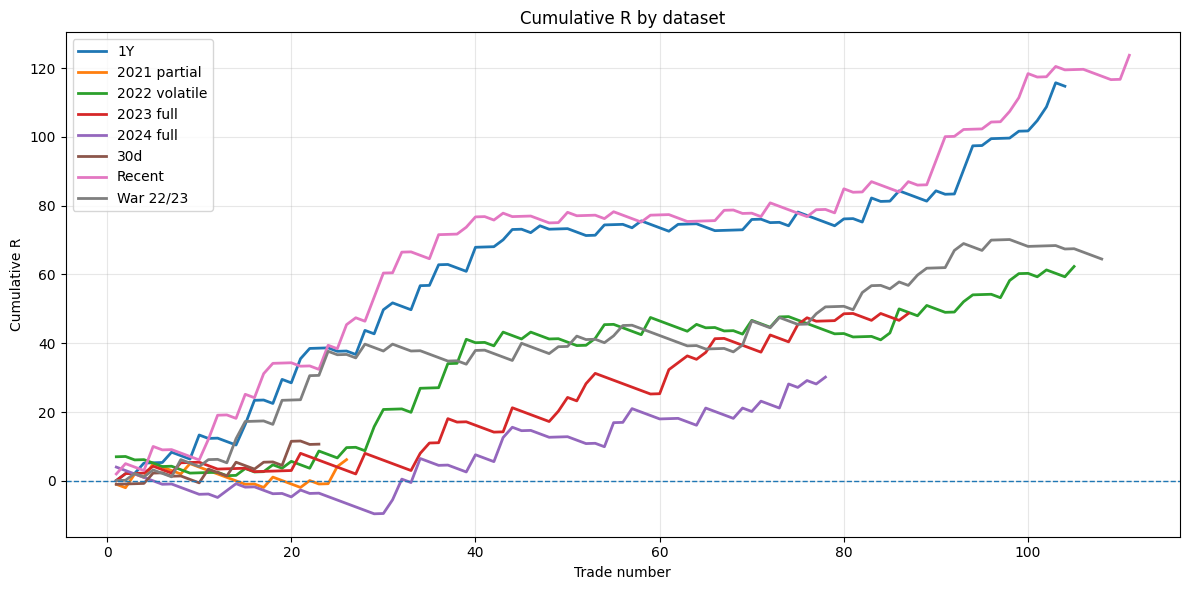

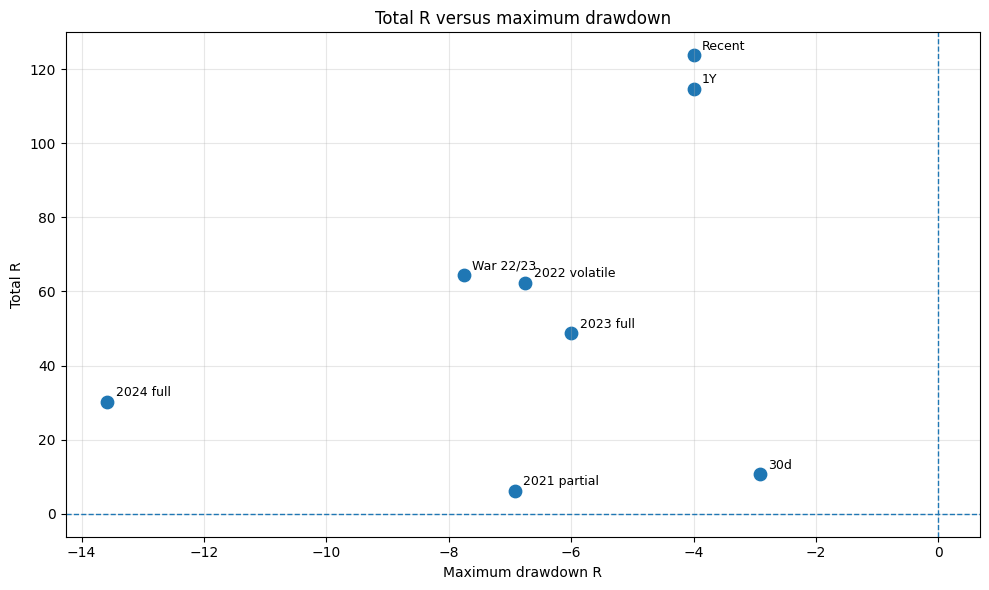

Core charts created
Datasets: 8
Trades plotted: 642


In [30]:
# ============================================================
# CORE CHARTS
# ============================================================
# Purpose:
#   Show compact visual summaries for the current strategy configuration.
#
# Scope:
#   This section reads all-dataset runner outputs only.
#   It does not rerun strategy logic, change configuration, export files,
#   or add detailed audits.

if "comparison_table" not in globals():
    raise ValueError("Run the all-dataset experiment runner before core charts.")

if "all_trades" not in globals():
    raise ValueError("Run the all-dataset experiment runner before core charts.")

if all_trades.empty:
    raise ValueError("No trades available for core charts.")

required_chart_columns = [
    "label",
    "trades",
    "total_r",
    "max_dd_r",
]

missing_chart_columns = [
    col for col in required_chart_columns
    if col not in comparison_table.columns
]

if missing_chart_columns:
    raise ValueError(f"Missing comparison table columns: {missing_chart_columns}")

if "dataset_label" not in all_trades.columns:
    raise ValueError("all_trades must include dataset_label.")

if "r_multiple" not in all_trades.columns:
    raise ValueError("all_trades must include r_multiple.")


# ------------------------------------------------------------
# Build compact chart inputs.
# ------------------------------------------------------------
equity_curve_chart_df = all_trades.copy()

equity_curve_chart_df["trade_number"] = (
    equity_curve_chart_df
    .groupby("dataset_label")
    .cumcount()
    + 1
)

equity_curve_chart_df["cumulative_r"] = (
    equity_curve_chart_df
    .groupby("dataset_label")["r_multiple"]
    .cumsum()
)

chart_summary_table = comparison_table[
    [
        "label",
        "trades",
        "total_r",
        "max_dd_r",
    ]
].copy()


# ------------------------------------------------------------
# Chart 1: cumulative R by dataset.
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

for dataset_label, dataset_trades in equity_curve_chart_df.groupby("dataset_label"):
    plt.plot(
        dataset_trades["trade_number"],
        dataset_trades["cumulative_r"],
        linewidth=2,
        label=dataset_label,
    )

plt.axhline(0, linewidth=1, linestyle="--")

# Leave visible negative-R space below the zero line so drawdowns are easier to read.
min_cumulative_r = float(equity_curve_chart_df["cumulative_r"].min())
max_cumulative_r = float(equity_curve_chart_df["cumulative_r"].max())
y_padding = max(2.0, abs(max_cumulative_r - min_cumulative_r) * 0.05)

plt.ylim(
    bottom=min(min_cumulative_r - y_padding, -y_padding),
    top=max_cumulative_r + y_padding,
)

plt.title("Cumulative R by dataset")
plt.xlabel("Trade number")
plt.ylabel("Cumulative R")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 2: return versus drawdown.
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.scatter(
    chart_summary_table["max_dd_r"],
    chart_summary_table["total_r"],
    s=80,
)

for _, row in chart_summary_table.iterrows():
    plt.annotate(
        row["label"],
        (
            row["max_dd_r"],
            row["total_r"],
        ),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=9,
    )

plt.axhline(0, linewidth=1, linestyle="--")
plt.axvline(0, linewidth=1, linestyle="--")
plt.title("Total R versus maximum drawdown")
plt.xlabel("Maximum drawdown R")
plt.ylabel("Total R")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print("Core charts created")
print("Datasets:", len(chart_summary_table))
print("Trades plotted:", len(equity_curve_chart_df))

## Audits and detailed diagnostics

These sections explain why the model did or did not trade.

They are detailed diagnostics, not the first results the user should see.

### Raw signal audit

### Strategy-filter block audit

### Trade attribution report

### Mean-reversion diagnostics

### Protected add-on diagnostics

## Experiment logging

This section saves the current run configuration and headline results.

## Future live runner notes

The future live file should use this notebook's final clean config structure.

Live runner goals:
- one file
- signal-only by default
- optional order placement later
- use same MT5 account/feed/symbol as overlay
- same lookback/session/VWAP/sigma settings as overlay
- clear logging of raw signal, final signal, and skip reason